In [62]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts,get_initial_turn_direction
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [297]:
test = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint.h5")
test1 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint1.h5")
joint = pd.concat([test,test1])
intial_distance_to_obstacle(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)

In [308]:
long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)

long,short,middle = create_df_by_type(joint)

In [309]:
calculate_relative_distance_goal_ts(long)

In [310]:
calculate_speed(long)
calculate_speed(short)

In [123]:
bin_edges

array([25.        , 22.81818182, 20.63636364, 18.45454545, 16.27272727,
       14.09090909, 11.90909091,  9.72727273,  7.54545455,  5.36363636,
        3.18181818,  1.        ])

In [118]:
hist

array([55,  3,  4,  4, 10, 10,  4,  5,  6,  7, 19], dtype=int64)

In [176]:
speed_bin_mean

21.836080160661094

In [212]:
# intialise list for average speed across 5 cm bins 
trial_speeds= []
# Get index of distance from edge > 0 
ts_distance = short.ts_distance_from_edge.iloc[8]
ts_speed= short.ts_speed.iloc[8]
dist_inds = np.where(short.ts_distance_from_edge.iloc[8]>0)

distance_before_edge = ts_distance[dist_inds]

# set 10 bins of 2.5 cm width 
bin_edges = np.linspace(1, 13, 11)
# array of indexs of bins

bin_assignments = np.digitize(distance_before_edge, bins=bin_edges, right=True)

hist, bin_edges = np.histogram(distance_before_edge, bins=bin_edges ,range=(25, 0))

hist, bin_edges = hist[::-1], bin_edges[::-1]
speed_list = []
for i in  np.linspace(11, 1, 11):
    speed_bin_mean = ts_speed[np.where(bin_assignments==i)].mean()
    speed_list.append(speed_bin_mean)
trial_speeds.append(speed_list)




In [218]:
def bin_speeds_by_distance_from_obstacle (df,bins,max_dist):
    '''get array of the speed binned by distance from edge of obstacle
      returns array of trials by array of speeds   '''
    trial_speeds= [] 

    for ind, row in df.iterrows():
        # Get index of distance from edge > 0 
        ts_distance = row.ts_distance_from_edge
        ts_speed= row.ts_speed
        dist_inds = np.where(row.ts_distance_from_edge>0)
        distance_before_edge = ts_distance[dist_inds]
        # set bins 
        bin_edges = np.linspace(1, max_dist, bins)
        bin_assignments = np.digitize(distance_before_edge, bins=bin_edges, right=True)

        hist, bin_edges = np.histogram(distance_before_edge, bins=bin_edges ,range=(25, 0))
        hist, bin_edges = hist[::-1], bin_edges[::-1]
        speed_list = []
        for i in  np.linspace(bins, 1, bins):
          speed_bin_mean = ts_speed[np.where(bin_assignments==i)].mean()
          speed_list.append(speed_bin_mean)
          trial_speeds.append(speed_list)
          
    return np.asarray(trial_speeds)
        
    


In [263]:
distance_before_edge

array([9.275238453288882, 9.008176003075768, 8.709670866747265,
       8.41232688304605, 8.081016199175616, 7.8320770191692155,
       7.622221573081543, 7.32495323018005, 7.101187839133253,
       6.846503939442815, 6.536124524589772, 6.239461308086042,
       5.9425804584041675, 5.643378630499292, 5.413790224905593,
       5.161130048365575, 5.000484914138159, 4.769864077979854,
       4.649246197120313, 4.671671703690073, 4.397277404030369,
       4.180999125124327, 3.922864943341377, 3.473684661001247,
       3.1758019024809734, 2.7437615599511886, 2.577347819471406,
       2.522983316977566, 2.4142078658847907, 2.3523801378185283,
       2.3213461774279445, 2.2265695824097556, 2.1549868452427,
       2.0190165361030488, 2.1363208191222007, 1.8117633989320758,
       2.056693616553293, 1.2144094250973936, 0.9774825348992344,
       0.9844564629771746, 0.9914303910551148, 0.9984043191330585,
       1.0053782472109987, 1.0123521752889388, 1.019326103366879,
       1.0263000314448192,

In [262]:
i

1.0

In [261]:
 ts_speed[np.where(bin_assignments==i)]

array([16.029714663933202, 18.223298838372212, 19.7593757186199,
       20.14031534389754, 19.106795211059847, 16.75207894173978,
       2.6895957004411457, 1.669054047755337, 1.1243199181886225,
       0.8661037231960679, 0.7571437676675655, 0.7160348710794908,
       0.7023048489845103, 0.6976301786585485, 0.6970382123378656,
       0.6970040688285337, 0.6969124667205779, 0.6967840949253102,
       0.6966635708457134, 0.6966016342986208, 0.6966342454804904,
       0.6967680626872936, 0.6969764765995764, 0.697208074977286,
       0.6974082719518628, 0.6975401356858879, 0.6975935475327681,
       0.6975777509367533, 0.6975075650233973, 0.6973956717088716,
       0.697255515508198, 0.6971082866171724, 0.6969855842447037,
       0.6969173741013159, 0.6969166298074072, 0.6969696159242765,
       0.6970387765359352, 0.6970826365478863, 0.6970761604708027,
       0.6970266328766873, 0.696971733974305, 0.6969575541498096,
       0.697004936222369, 0.6970958109393368, 0.6971775195416235,
    

In [259]:
bin_assignments

array([7, 7, 7, 7, 6, 6, 6, 6, 6, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 3, 3,
       3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1],
      dtype=int64)

In [257]:
df = long[long.task == 'oa'].sample(1)
max_dist = 25
bins = 11

test = bin_speeds_by_distance_from_obstacle (df,bins,max_dist)

In [258]:
test

array([[        nan,         nan,  9.26534842, 25.85557012, 38.34187352,
        43.45793282, 44.81217168, 38.88881914, 32.90698311, 48.29123324,
                nan],
       [        nan,         nan,  9.26534842, 25.85557012, 38.34187352,
        43.45793282, 44.81217168, 38.88881914, 32.90698311, 48.29123324,
                nan],
       [        nan,         nan,  9.26534842, 25.85557012, 38.34187352,
        43.45793282, 44.81217168, 38.88881914, 32.90698311, 48.29123324,
                nan],
       [        nan,         nan,  9.26534842, 25.85557012, 38.34187352,
        43.45793282, 44.81217168, 38.88881914, 32.90698311, 48.29123324,
                nan],
       [        nan,         nan,  9.26534842, 25.85557012, 38.34187352,
        43.45793282, 44.81217168, 38.88881914, 32.90698311, 48.29123324,
                nan],
       [        nan,         nan,  9.26534842, 25.85557012, 38.34187352,
        43.45793282, 44.81217168, 38.88881914, 32.90698311, 48.29123324,
              

In [256]:
long[long.task == 'oa']

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,num_turn,towards_num_turn,away_num_turn,right_num_turn,right_turns_distances,left_num_turn,left_turns_distances,intial_distance,avg_speed,avg_ts_speed
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,3.0,0.0,NaN,1.0,[2.3336543876011326],2.0,"[1.8804369365781402, 1.8904238936934148]",25.0,20.809365,20.891983
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,1.0,3.0,2.0,1.0,[21.448106895216092],0.0,[],23.0,17.862486,17.851822
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,5.0,1.0,3.0,3.0,"[19.126954831503788, 12.68730852308991, 4.2751...",2.0,"[6.2272710475092765, 2.4417895280408155]",23.0,25.031042,26.860749
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,4.0,0.0,NaN,3.0,"[22.825084479564573, 9.934737689725033, 10.338...",1.0,[4.659622630986767],25.0,12.043630,12.924533
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,4.0,4.0,4.0,2.0,"[22.689007941167716, 2.239520390798571]",2.0,"[4.286593988791843, 2.311305803187799]",25.0,19.450888,19.241862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8809,8809,53682.691097,53684.452428,"[53682.695372, 53682.713523, 53682.728844, 536...","[9889, 9890, 9891, 9892, 9893, 9894, 9895, 989...","[112.17072296142578, 112.42405700683594, 112.5...","[277.1304931640625, 277.2672119140625, 277.129...","[129.66957092285156, 127.5576400756836, 125.69...","[274.0078125, 274.1982116699219, 272.819396972...","[119.23519897460938, 117.94373321533203, 119.5...",...,2.0,0.0,NaN,2.0,"[16.733120269807827, 9.315283554786156]",0.0,[],18.0,28.457613,38.527483
8827,8827,53737.922483,53740.560204,"[53737.931635, 53737.948006, 53737.964556, 537...","[13202, 13203, 13204, 13205, 13206, 13207, 132...","[112.039794921875, 112.21412658691406, 112.549...","[276.7937316894531, 276.2401428222656, 275.822...","[129.1151885986328, 127.08348846435547, 126.63...","[274.00408935546875, 272.08660888671875, 271.3...","[118.4272689819336, 118.7538833618164, 117.768...",...,1.0,0.0,NaN,1.0,[17.3046768222964],0.0,[],18.0,19.965961,37.224898
8866,8866,54095.947059,54097.446361,"[54095.955302, 54095.971712, 54095.988326, 540...","[34676, 34677, 34678, 34679, 346

In [254]:
test.shape

(22649, 11)

In [ ]:
np.array(speed_list).reshape(1,11)

In [240]:
np.asarray(trial_speeds)

array([[        nan,         nan,         nan,         nan, 19.2629233 ,
        21.10664752, 26.39475011, 28.61540943, 27.06698967, 14.45547434,
         5.79765338]])

In [233]:
np.asarray(trial_speeds).shape

(1, 11)

In [200]:
 list(range(len(bin_edges)))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [201]:
bin_edges

array([25. , 22.6, 20.2, 17.8, 15.4, 13. , 10.6,  8.2,  5.8,  3.4,  1. ])

In [234]:
trial_speeds


[[nan,
  nan,
  nan,
  nan,
  19.262923299294982,
  21.10664752235947,
  26.394750111809312,
  28.61540942708439,
  27.066989665610592,
  14.455474338364274,
  5.797653381667955]]

In [231]:
trial_speeds

[[nan,
  nan,
  nan,
  nan,
  19.262923299294982,
  21.10664752235947,
  26.394750111809312,
  28.61540942708439,
  27.066989665610592,
  14.455474338364274,
  5.797653381667955]]

In [251]:
test[0:5]

array([[15.68455713, 16.58743406, 22.57159333, 25.58747862, 30.48065761,
        25.01607017, 13.25140151, 24.47607748, 35.3692382 , 32.02869452,
        21.83608016],
       [15.68455713, 16.58743406, 22.57159333, 25.58747862, 30.48065761,
        25.01607017, 13.25140151, 24.47607748, 35.3692382 , 32.02869452,
        21.83608016],
       [15.68455713, 16.58743406, 22.57159333, 25.58747862, 30.48065761,
        25.01607017, 13.25140151, 24.47607748, 35.3692382 , 32.02869452,
        21.83608016],
       [15.68455713, 16.58743406, 22.57159333, 25.58747862, 30.48065761,
        25.01607017, 13.25140151, 24.47607748, 35.3692382 , 32.02869452,
        21.83608016],
       [15.68455713, 16.58743406, 22.57159333, 25.58747862, 30.48065761,
        25.01607017, 13.25140151, 24.47607748, 35.3692382 , 32.02869452,
        21.83608016]])

([<matplotlib.axis.XTick at 0x26b6075d340>,
 [Text(0, 0, '25'), Text(5, 0, '13'), Text(10, 0, '1')])

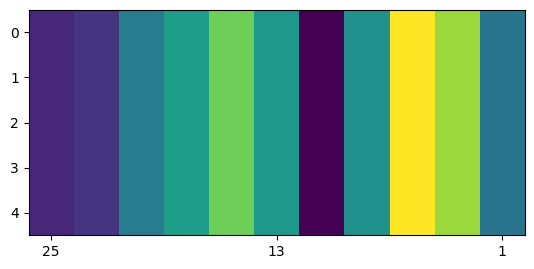

In [250]:
plt.imshow(test[0:5].reshape(5,11))
plt.xticks(ticks = [0,  5, 10],labels=[25,13,1])


In [238]:
np.asarray(trial_speeds)

array([[        nan,         nan,         nan,         nan, 19.2629233 ,
        21.10664752, 26.39475011, 28.61540943, 27.06698967, 14.45547434,
         5.79765338]])

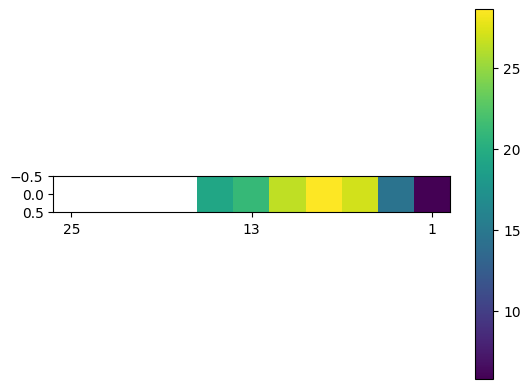

In [236]:
plt.imshow(np.asarray(trial_speeds))
plt.xticks(ticks = [0,  5, 10],labels=[25,13,1])
plt.colorbar()

In [168]:
def fr(speed, distance_bin, distance_window):
    speed = speed.reshape((-1, 1))
    distance_bin = distance_bin.reshape((1, -1))
    rate = np.sum(np.abs(speed - distance_bin) < distance_window, axis=0)
    return rate

In [172]:
fr(ts_speed, bin_edges, 2)

array([50, 64, 43, 22, 22, 16, 14, 12, 18, 11,  0])

In [171]:
np.abs(ts_speed - bin_edges)

ValueError: operands could not be broadcast together with shapes (214,) (11,) 

In [170]:
np.abs(ts_speed - bin_edges) < 2

ValueError: operands could not be broadcast together with shapes (214,) (11,) 

In [162]:
bin_edges

array([25. , 22.6, 20.2, 17.8, 15.4, 13. , 10.6,  8.2,  5.8,  3.4,  1. ])

In [161]:
ts_speed

array([7.071956994694936, 6.749018983866641, 6.214775802691877,
       5.642698641511707, 5.196835043259519, 4.971363712274435,
       4.9722516532029095, 5.139336111051536, 5.395882603313002,
       5.699757683095558, 6.067838854563242, 6.559487752964354,
       7.231010428588194, 8.087653538514024, 9.064030930215075,
       10.043083593406791, 10.90371884714401, 11.577804028620402,
       12.096064434986435, 12.606050219209328, 13.346660405278481,
       14.573064321067408, 16.452917471122564, 18.978751393273768,
       21.94705552840992, 25.01960371625656, 27.841446237816427,
       30.15441534863416, 31.85447563946952, 32.97411161231185,
       33.61423226651141, 33.862260537171146, 33.74149346558163,
       33.21144826619016, 32.21108357053437, 30.72507881777284,
       28.828728557268743, 26.68870105404505, 24.522845675311455,
       22.547876079693772, 20.95038409567953, 19.88105077619514,
       19.449847127761636, 19.700412235005132, 20.574494355863706,
       21.9039977676131

In [160]:
ts_speed.reshape((-1, 1))

array([[7.071956994694936],
       [6.749018983866641],
       [6.214775802691877],
       [5.642698641511707],
       [5.196835043259519],
       [4.971363712274435],
       [4.9722516532029095],
       [5.139336111051536],
       [5.395882603313002],
       [5.699757683095558],
       [6.067838854563242],
       [6.559487752964354],
       [7.231010428588194],
       [8.087653538514024],
       [9.064030930215075],
       [10.043083593406791],
       [10.90371884714401],
       [11.577804028620402],
       [12.096064434986435],
       [12.606050219209328],
       [13.346660405278481],
       [14.573064321067408],
       [16.452917471122564],
       [18.978751393273768],
       [21.94705552840992],
       [25.01960371625656],
       [27.841446237816427],
       [30.15441534863416],
       [31.85447563946952],
       [32.97411161231185],
       [33.61423226651141],
       [33.862260537171146],
       [33.74149346558163],
       [33.21144826619016],
       [32.21108357053437],
       [3

In [131]:
ts_speed[np.where(bin_assignments==11)].mean()

15.684557133453879

In [143]:
ts_speed[np.where(bin_assignments==1)].mean()

21.836080160661094

In [126]:
bin_assignments

array([11, 11, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 10, 10, 10,
       10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 10, 10, 10, 10, 10,
       10, 10,  9,  9,  9,  9,  9,  9,  9,  9,  9,  8,  8,  8,  8,  8,  8,
        7,  7,  7,  7,  6,  6,  6,  6,  6,  6,  5,  5,  5,  5,  5,  5,  5,
        5,  5,  5,  5,  5,  4,  5,  4,  4,  4,  4,  4,  4,  3,  3,  3,  3,
        2,  2,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1], dtype=int64)

In [109]:
bin_edges

array([ 1.        ,  3.18181818,  5.36363636,  7.54545455,  9.72727273,
       11.90909091, 14.09090909, 16.27272727, 18.45454545, 20.63636364,
       22.81818182, 25.        ])

In [112]:
hist

array([55,  3,  4,  4, 10, 10,  4,  5,  6,  7, 19], dtype=int64)

In [107]:
bin_edges

array([ 1.        ,  3.66666667,  6.33333333,  9.        , 11.66666667,
       14.33333333, 17.        , 19.66666667, 22.33333333, 25.        ])

In [62]:
hist

array([40, 18,  4,  4, 15,  7,  4,  6,  9, 20], dtype=int64)

In [63]:
distance_before_edge

array([25.32478958735699, 25.11036782562303, 24.965264885190813,
       24.944202240047595, 24.898902690236042, 24.896126540183147,
       24.843836188039532, 24.834308101337903, 24.826754637618443,
       24.926558028239114, 25.071979456249103, 25.154711912701273,
       25.148665956849925, 25.102490566199506, 24.995324804406046,
       24.822720461633352, 24.74803512464618, 24.88823866450703,
       25.007480413624286, 25.1564742106316, 25.331355739585355,
       25.4178675819604, 25.469292709517738, 25.434099832174105,
       25.48120945305265, 25.384314915642285, 25.26272166657582,
       25.196789429851044, 25.12810227557855, 24.851410884264176,
       24.717269224633554, 24.502810306015526, 24.171025871873162,
       23.750739047994685, 23.362555771955464, 22.922788124570026,
       22.5192165903982, 22.13732344401995, 21.790081746103127,
       21.570781816302983, 21.30224901510583, 20.946148054400687,
       20.65903150304063, 20.511635452048466, 20.269510579174778,
       20.0

In [61]:
bin_assignments

array([ 0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  1,  1,  1,
        1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,
        3,  4,  4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  8,  8,  8,
        8,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10], dtype=int64)

In [56]:

import numpy as np

# Example array of distances (in cm)
distances = np.array([12, 25, 37, 48, 5, 15, 30, 42, 8, 22])

# Define the bin edges
bin_edges = np.linspace(50, 0, 11)  # 11 points to create 10 bins

# Compute the histogram
hist, bin_edges = np.histogram(distances, bins=bin_edges[::-1], range=(50, 0))

In [55]:
bin_edges.tolist()

[50.0, 45.0, 40.0, 35.0, 30.0, 25.0, 20.0, 15.0, 10.0, 5.0, 0.0]

In [ ]:
long.ts_speed.loc[8][np.where(long.ts_distance_from_edge.loc[8]>0)]

In [39]:
len(long.ts_distance_from_target_port.iloc[0])

215

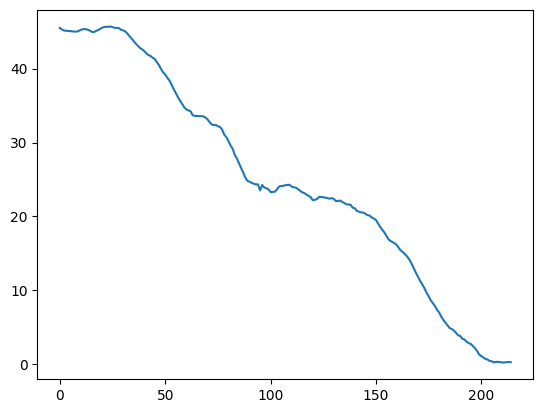

In [42]:
plt.plot(long.ts_distance_from_target_port.loc[8])

In [48]:
np.linspace(25, 0, 11)

array([25. , 22.5, 20. , 17.5, 15. , 12.5, 10. ,  7.5,  5. ,  2.5,  0. ])

In [44]:
long.ts_distance_from_edge.loc[8]

array([25.32478958735699, 25.11036782562303, 24.965264885190813,
       24.944202240047595, 24.898902690236042, 24.896126540183147,
       24.843836188039532, 24.834308101337903, 24.826754637618443,
       24.926558028239114, 25.071979456249103, 25.154711912701273,
       25.148665956849925, 25.102490566199506, 24.995324804406046,
       24.822720461633352, 24.74803512464618, 24.88823866450703,
       25.007480413624286, 25.1564742106316, 25.331355739585355,
       25.4178675819604, 25.469292709517738, 25.434099832174105,
       25.48120945305265, 25.384314915642285, 25.26272166657582,
       25.196789429851044, 25.12810227557855, 24.851410884264176,
       24.717269224633554, 24.502810306015526, 24.171025871873162,
       23.750739047994685, 23.362555771955464, 22.922788124570026,
       22.5192165903982, 22.13732344401995, 21.790081746103127,
       21.570781816302983, 21.30224901510583, 20.946148054400687,
       20.65903150304063, 20.511635452048466, 20.269510579174778,
       20.0

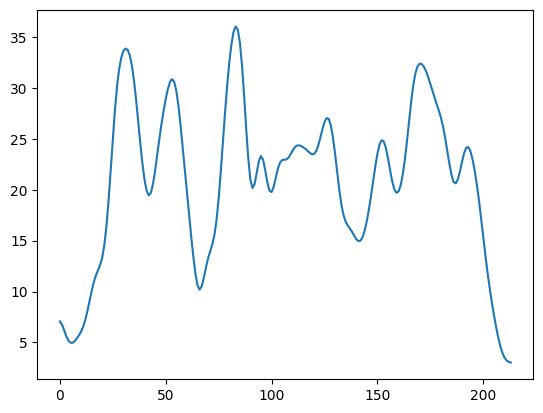

In [15]:
plt.plot(long.ts_speed.loc[8])

In [12]:
len(long.ts_speed.loc[8])/60

3.566666666666667

In [12]:
joint[:7276].to_hdf(r'd:\obstacle_avoidance\metadata\obstacle_avoidance_paper/joint.h5', key='df', mode='w')

In [13]:
joint[7276:].to_hdf(r'd:\obstacle_avoidance\metadata\obstacle_avoidance_paper/joint1.h5', key='df', mode='w')

In [316]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 24}

plt.rc( 'font',**font);

In [22]:
plt.rcParams.update({'font.size': 24,
                     'font.weight': 'bold',
                     'axes.linewidth':    1,
                     'xtick.major.size':  3,
                     'xtick.major.width': 1,
                     'ytick.major.size':  3,
                     'ytick.major.width': 1,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'pdf.fonttype':      42,
                     'xtick.labelsize':   24,
                     'ytick.labelsize':   24,
                     'figure.facecolor': 'white'
                    })

In [120]:
np.round(row[1].ts_distance_from_edge[0])

9.0

In [121]:
def intial_distance_to_obstacle(df):
    for ind,row in df.iterrows():
        df.at[ind,'intial_distance'] = np.round(row.ts_distance_from_edge[0])

In [4]:
def distance_at_head_turn_2(df):
    for ind,row in df.iterrows():
        peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3,12))
        if len(peaks) == 0:
            df.at[ind,'distance_at_head_turn_2'] = np.nan
            df.at[ind,'distance_at_head_turn_2_index'] = np.nan
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.nan
            df.at[ind,'angle_at_head_turn_2'] = np.nan
            df.at[ind,'num_turn'] = 0
        else:
            max_peak = peaks[prop['peak_heights'].argmax()]
  
            df.at[ind,'distance_at_head_turn_2'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'distance_at_head_turn_2_index'] = max_peak
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.array(peaks).astype(object)
            df.at[ind,'angle_at_head_turn_2'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'num_turn'] = len(peaks)
def towards_away_turns(df):
    for ind,row in df.iterrows():
        pos_peaks, pos_prop = find_peaks(row.head_corner_angle_velocity[:int(row.obstacle_ind)], width=1,height=(2,12))
        neg_peaks, neg_prop = find_peaks((row.head_corner_angle_velocity[:int(row.obstacle_ind)])*-1, width=1,height=(2,12))
        if len(pos_peaks) == 0:
            df.at[ind,'towards_num_turn'] = 0
        elif len(neg_peaks) == 0: 
            df.at[ind,'away_num_turn'] = 0  
        else:
            df.at[ind,'towards_num_turn'] = len(pos_peaks)
            df.at[ind,'away_num_turn'] = len(neg_peaks)
def right_left_turns(df):
    for ind,row in df.iterrows():
        pos_peaks, pos_prop = find_peaks(row.head_angle_velocity[:int(row.obstacle_ind)], width=2,height=(3,12))
        neg_peaks, neg_prop = find_peaks(row.head_angle_velocity[:int(row.obstacle_ind)]*-1, width=2,height=(3,12))
        
        if row.odd == 'right':
            df.at[ind,'right_num_turn'] = len(neg_peaks)
            df.at[ind,'right_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][neg_peaks]
            df.at[ind,'left_num_turn'] = len(pos_peaks)
            df.at[ind,'left_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][pos_peaks]
        elif row.odd == 'left':
            df.at[ind,'right_num_turn'] = len(pos_peaks)
            df.at[ind,'right_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][pos_peaks]
            df.at[ind,'left_num_turn'] = len(neg_peaks)
            df.at[ind,'left_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][neg_peaks]
def first_occurrence_indices(arr):
    unique_values, first_indices = np.unique(arr, return_index=True)
    sorted_indices = np.sort(first_indices)
    return sorted_indices

In [5]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_092524_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_092524_oa.h5")
joint = pd.concat([light,dark])
heading_calcs(joint)
get_head_angle(joint)
head_angle_velocity(joint)
angular_velocity_head_corner(joint)
distance_at_head_turn_2(joint)
towards_away_turns(joint)
right_left_turns(joint)
#con_df = create_consective_df_new(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)
#long_con,short_con,middle_con = create_df_by_type(con_df)

corner
port


In [131]:
def first_occurrence_indices(arr):
    unique_values, first_indices = np.unique(arr, return_index=True)
    sorted_indices = np.sort(first_indices)
    return sorted_indices

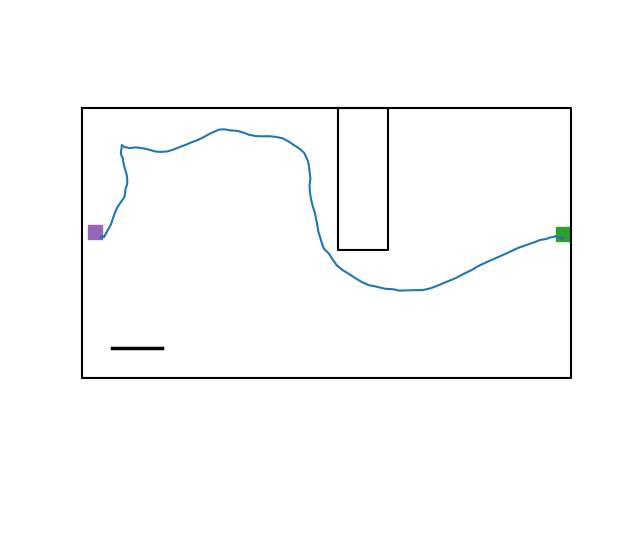

In [97]:
data = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oa')&(long_nostart.turn_to_obstacle == 'towards')]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
sample_light = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample_light.iterrows():
    fig,ax = plt.subplots(1,1,figsize=(8,7))
    
    #ax[1].set_xlim(20,0)
    


    ax.set_xticks([])
    ax.set_yticks([])
  
    #ax[2].invert_xaxis()
    plot_arena(data,ax)
    ob_x,ob_y = plot_orginal_obstacle(data,ax,int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        #x, y = correct_trace(row,ob_x,ob_y)
        x, y = row.nose_x_cm,row.nose_y_cm
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )
        #ax[1].set_ylim(-12,2)
        ob_ind = int(row.obstacle_ind)
        x1 = x
        y1 = y
        ax.plot(x1,y1,color = 'tab:blue')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.plot((10,15),(32,32),c ='black', linewidth = 2.5)

Light single trial 


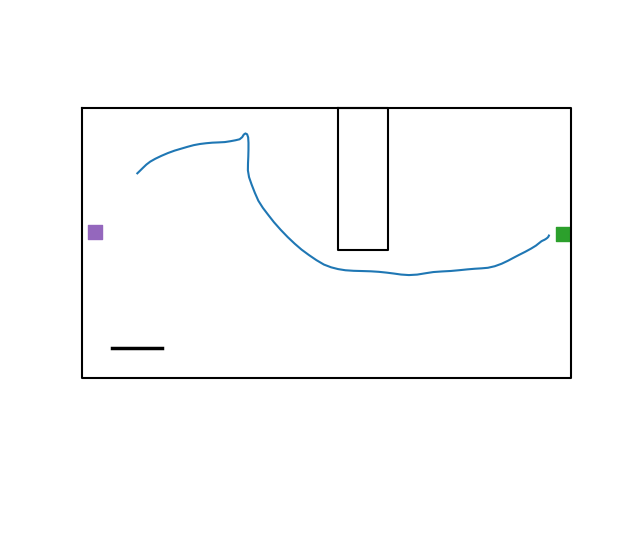

In [514]:
data = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oa')&(long_nostart.turn_to_obstacle == 'towards')]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
sample_light = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample_light.iterrows():
    fig,ax = plt.subplots(1,1,figsize=(8,7))
    
    #ax[1].set_xlim(20,0)
    


    ax.set_xticks([])
    ax.set_yticks([])
  
    #ax[2].invert_xaxis()
    plot_arena(data,ax)
    ob_x,ob_y = plot_orginal_obstacle(data,ax,int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )
        #ax[1].set_ylim(-12,2)
        ob_ind = int(row.obstacle_ind)
        x1 = x
        y1 = y
        ax.plot(x1,y1,color = 'tab:blue')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.plot((10,15),(32,32),c ='black', linewidth = 2.5)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_trace.pdf',dpi = 300, transparent=True)
       

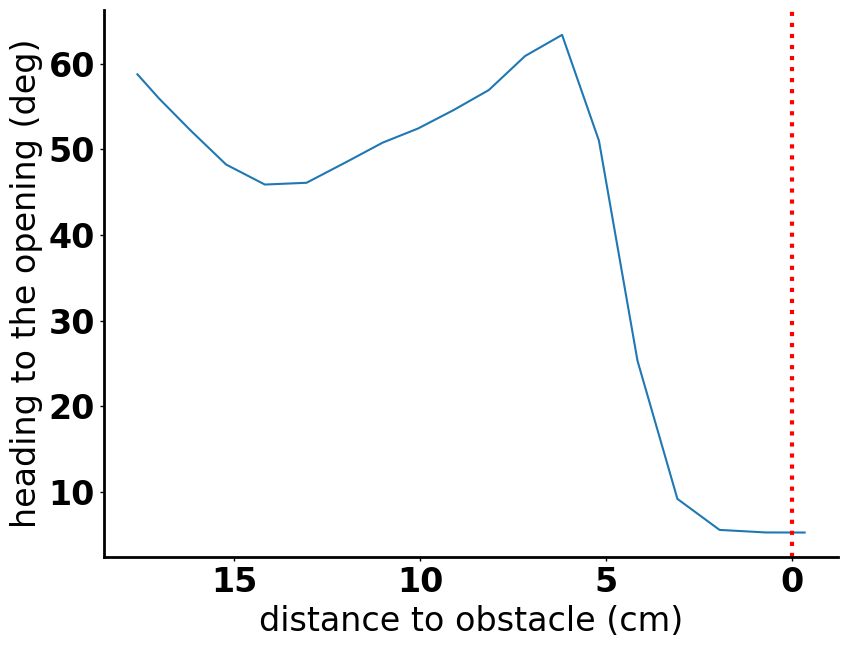

In [281]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_heading_to_opening_single_first_occurence.pdf',dpi = 300, transparent=True)
    

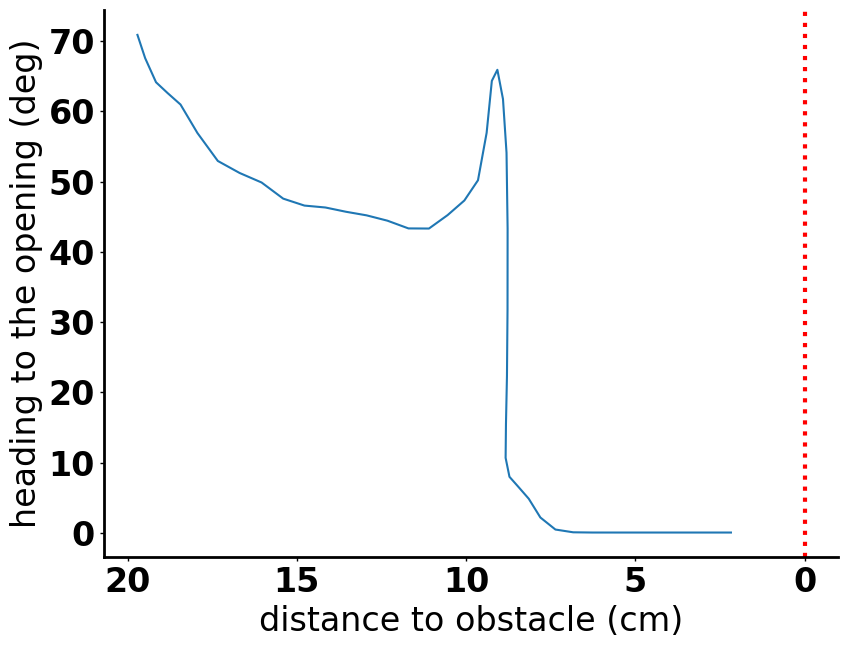

In [515]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_heading_to_opening_single.pdf',dpi = 300, transparent=True)

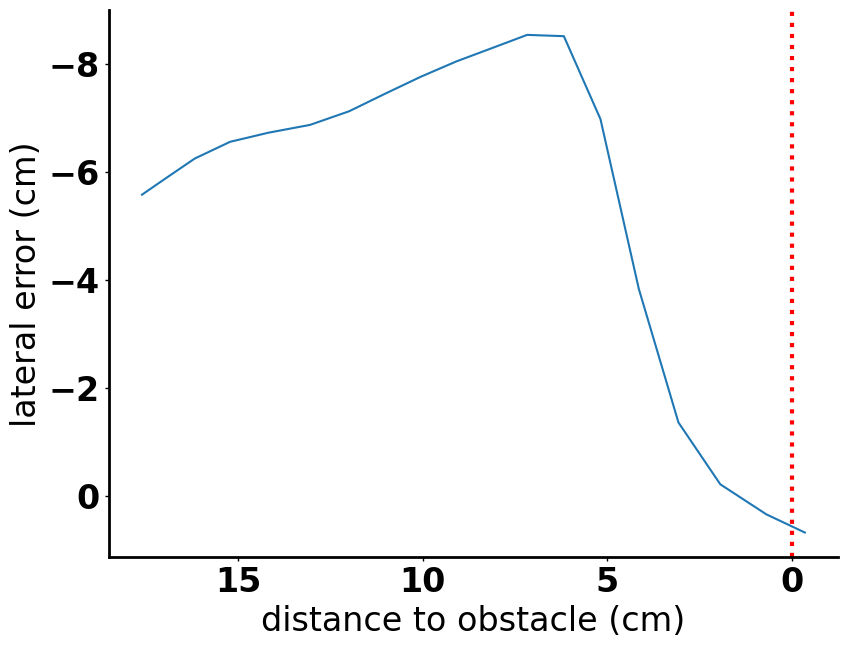

In [280]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_lateral_error_single_first_occurance.pdf',dpi = 300, transparent=True)
    

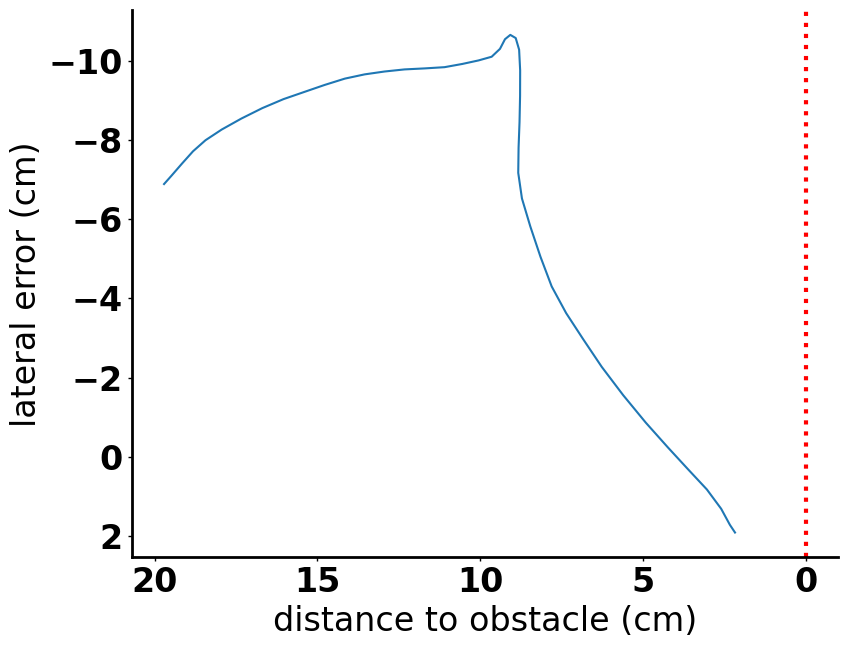

In [525]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_lateral_error_single.pdf',dpi = 300, transparent=True)

Single Trial dark

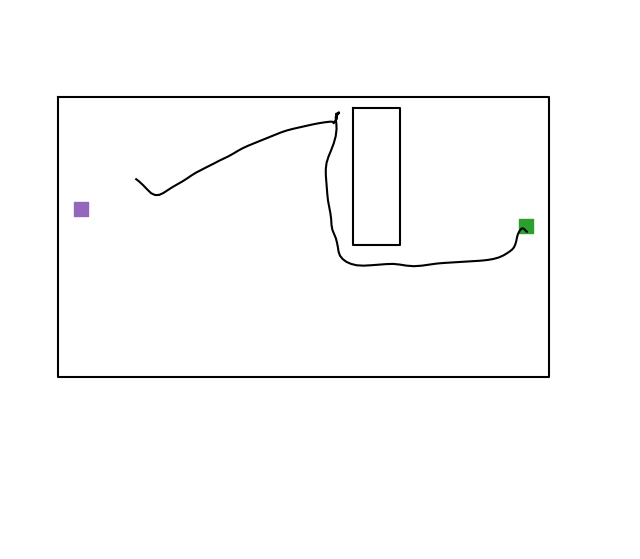

In [530]:
data = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oadark')&(long_nostart.turn_to_obstacle == 'towards')]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
sample_dark = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample_dark.iterrows():
    fig,ax = plt.subplots(1,1,figsize=(8,7))
    
    #ax[1].set_xlim(20,0)
    


    ax.set_xticks([])
    ax.set_yticks([])
  
    #ax[2].invert_xaxis()
    plot_arena(sample_dark,ax)
    ob_x,ob_y = plot_orginal_obstacle(sample_dark,ax,int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )
        #ax[1].set_ylim(-12,2)
        ob_ind = int(row.obstacle_ind)
        x1 = x
        y1 = y
        ax.plot(x1,y1,color = 'black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_trace.pdf',dpi = 300, transparent=True)

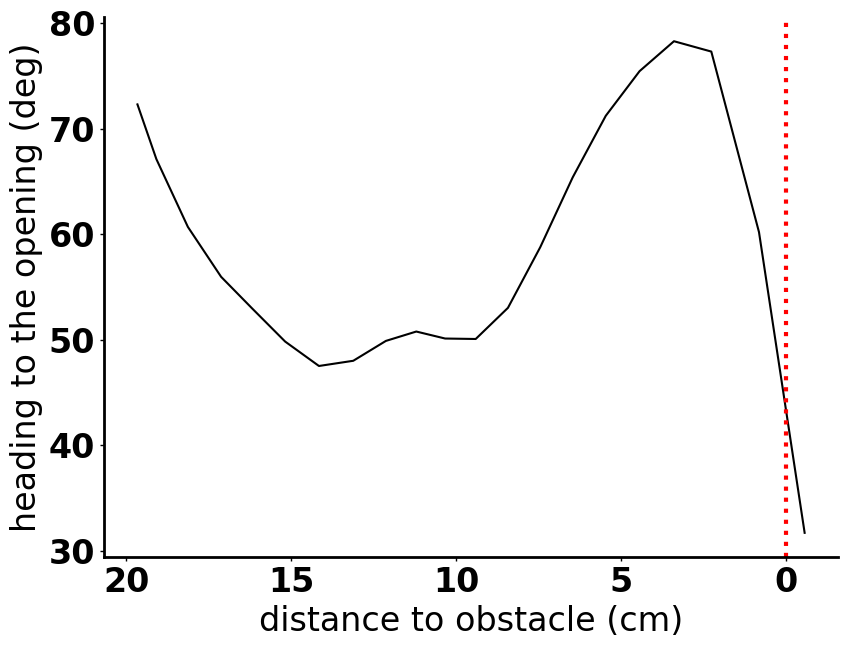

In [283]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_heading_to_opening_single_first_occurence.pdf',dpi = 300, transparent=True)

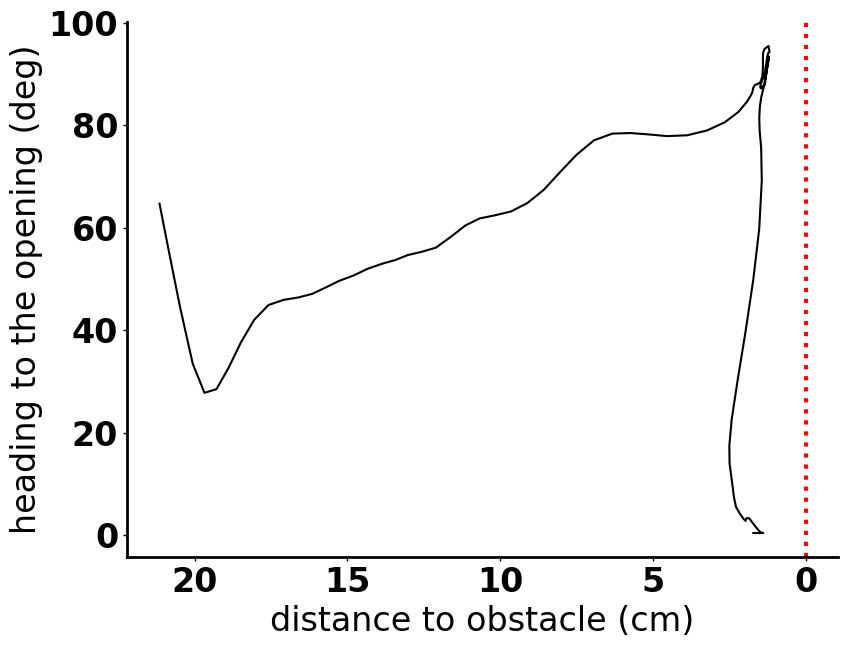

In [531]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_heading_to_opening_single.pdf',dpi = 300, transparent=True)

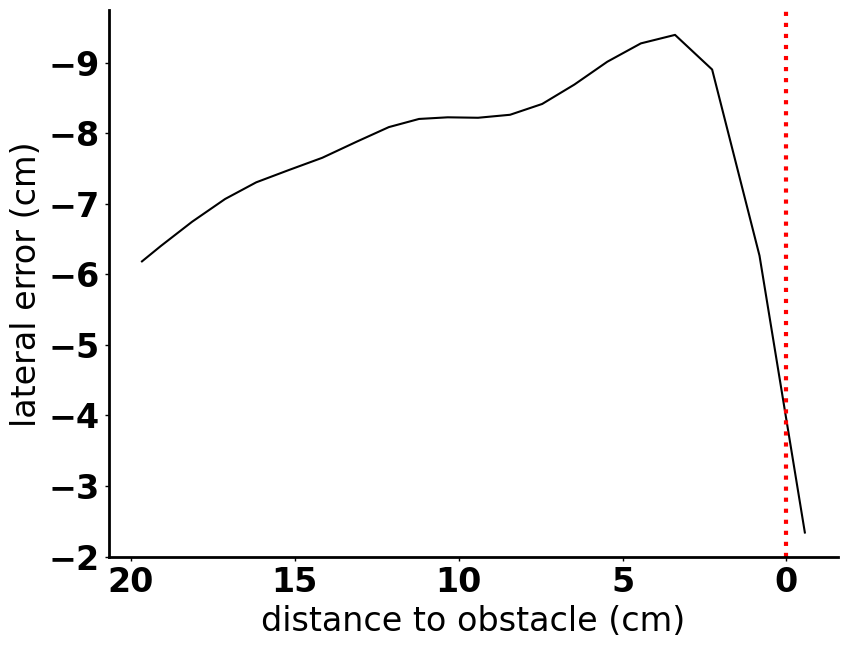

In [285]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_lateral_error_single_first_occurance.pdf',dpi = 300, transparent=True)

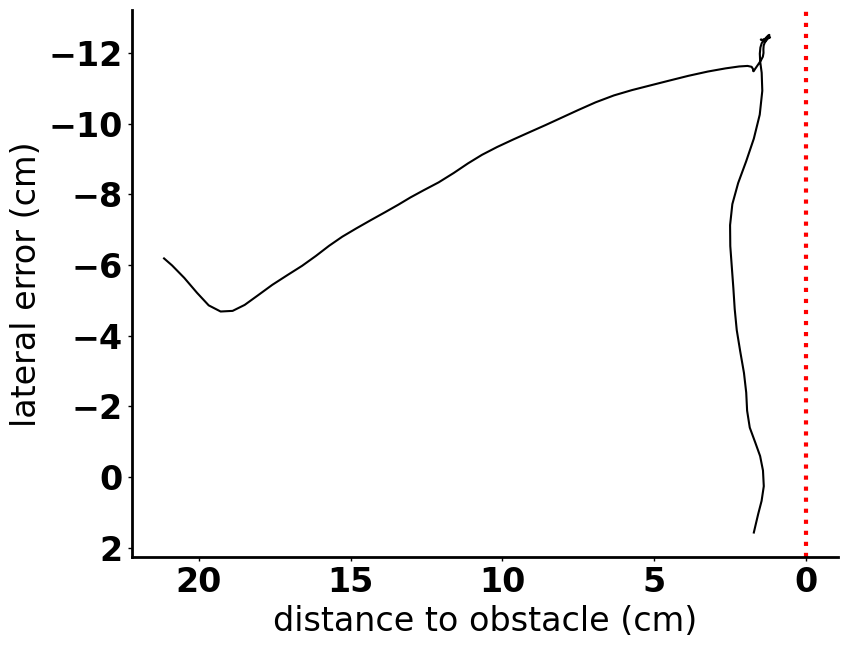

In [532]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_lateral_error.pdf',dpi = 300, transparent=True)

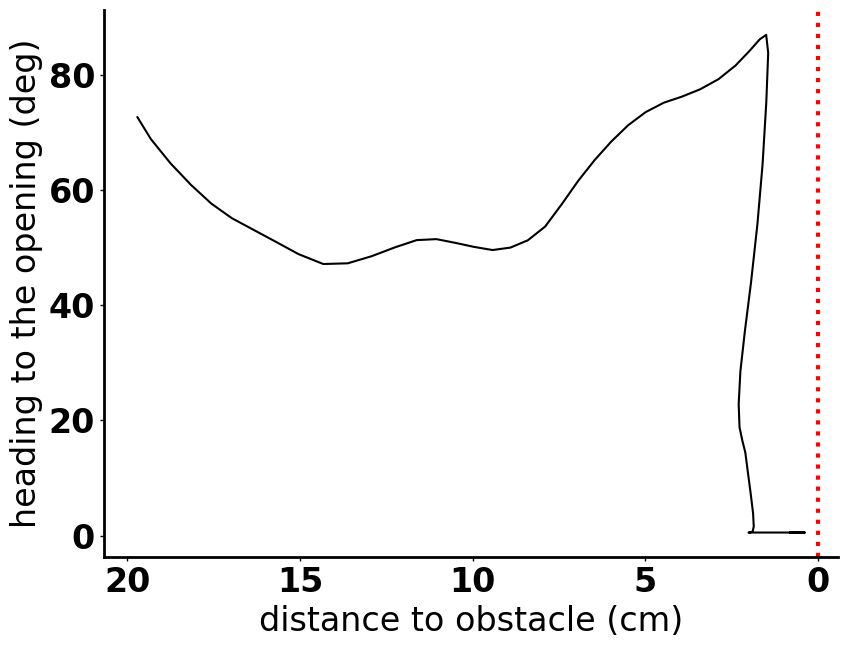

In [287]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)

Long first occurance

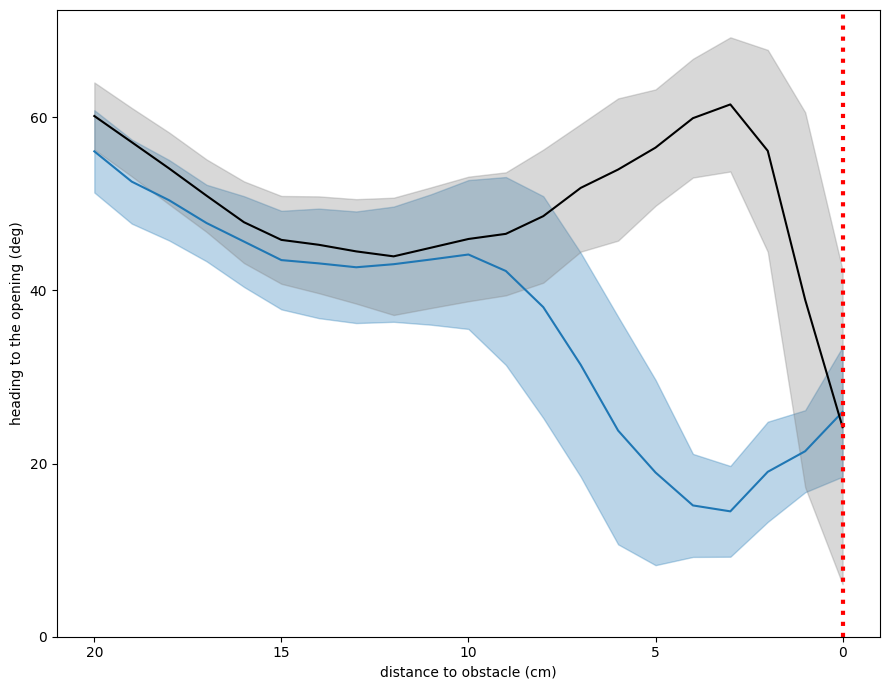

In [11]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (9,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[(data.obstacle_cluster == 0)|(data.obstacle_cluster == 5)]
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
#ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
#fig.suptitle('joint')
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_population_heading_to_opening_first_occurance.pdf',dpi = 300, transparent=True)

In [8]:
long_nostart

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_at_head_turn_2_indexs,angle_at_head_turn_2,num_turn,towards_num_turn,away_num_turn,right_num_turn,right_turns_distances,left_num_turn,left_turns_distances,intial_distance
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,"[104, 132, 139]",50.385093,3.0,0.0,NaN,1.0,[2.3336543876011326],2.0,"[1.8804369365781402, 1.8904238936934148]",25.0
12,12,48241.539046,48248.838630,"[48241.547481, 48241.565235, 48241.580953, 482...","[[11916, 11917, 11918, 11919, 11920, 11921, 11...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.07373046875, 652.8219604492188, 653.89038...","[250.80914306640625, 250.58074951171875, 251.1...","[651.4325561523438, 654.0964965820312, 655.288...",...,"[16, 29, 227, 246]",0.482018,4.0,1.0,3.0,2.0,"[2.4388612112758317, 1.733965925712237]",2.0,"[23.630424638200743, 21.023002370920434]",25.0
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,[21],67.816385,1.0,3.0,2.0,1.0,[21.448106895216092],0.0,[],23.0
22,22,48405.855897,48411.627596,"[48405.87136, 48405.887923, 48405.905356, 4840...","[[21772, 21773, 21774, 21775, 21776, 21777, 21...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.687255859375, 650.2926635742188, 650.7012...","[253.7032012939453, 253.50595092773438, 253.01...","[653.541748046875, 654.0216064453125, 654.7687...",...,"[24, 69, 78, 115]",36.767887,4.0,3.0,2.0,2.0,"[16.27088570840312, 3.7790677327540365]",2.0,"[20.759364752902034, 17.600842060035852]",24.0
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,"[9, 22, 40, 51, 61]",42.927215,5.0,1.0,3.0,3.0,"[19.126954831503788, 12.68730852308991, 4.2751...",2.0,"[6.2272710475092765, 2.4417895280408155]",23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14500,14500,55707.396288,55709.968704,"[55707.397785, 55707.413273, 55707.429952, 557...","[1699, 1700, 1701, 1702, 1703, 1704, 1705, 170...","[85.73371887207031, 85.64871215820312, 85.2961...","[265.4951477050781, 266.3911437988281, 267.019...","[101.66258239746094, 100.84394836425781, 100.1...","[263.1623229980469, 263.7874755859375, 264.255...","[95.14884185791016, 94.4954833984375, 94.34394...",...,[6],39.671929,1.0,0.0,NaN,0.0,[],1.0,[17.108199843640566],20.0
14515,14515,55791.531097,55794.455846,"[55791.542259, 55791.559129, 55791.576678, 557...","[6746, 6747, 6748, 6749, 6750, 6751, 6752, 675...","[87.90170288085938, 87.47258758544922, 86.7386...","[262.3829650878906, 262.2216796875, 261.975555...","[103.01107025146484, 101.36479949951172, 100.0...","[258.5079345703125, 257.7955017089844, 257.446...","[95.69554901123047, 95.50047302246094, 94.4459...",...,[3],36.108968,1.0,0.0,NaN,0.0,[],1.0,[18.994038492376387],21.0
14523,14523,55826.575206,55829.250214,"[55826.587891, 55826.604531, 5

Text(0.5, 0.98, 'long')

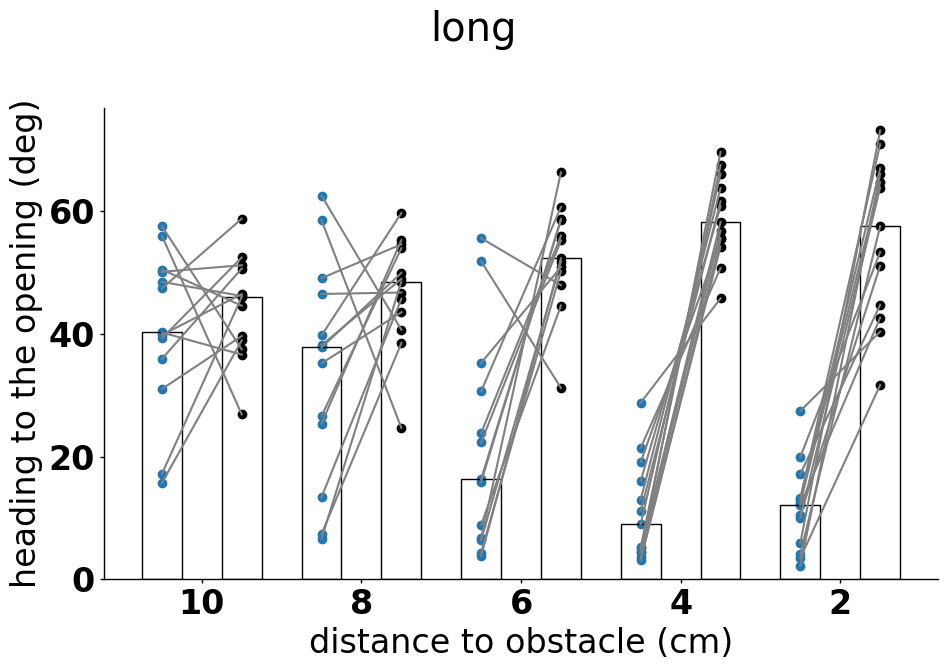

In [297]:
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,12],dark_medians[:,12]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,14],dark_medians[:,14]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,16],dark_medians[:,16]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.bar(8,np.nanmedian(light_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
ax.bar(9,np.nanmedian(dark_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],8),np.full(dark_medians.shape[0],9)),(light_medians[:,18],dark_medians[:,18]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('long')


In [300]:
np.nanstd(light_medians[:,10])

12.733471995423946

Text(0.5, 0, 'distance to obstacle (cm)')

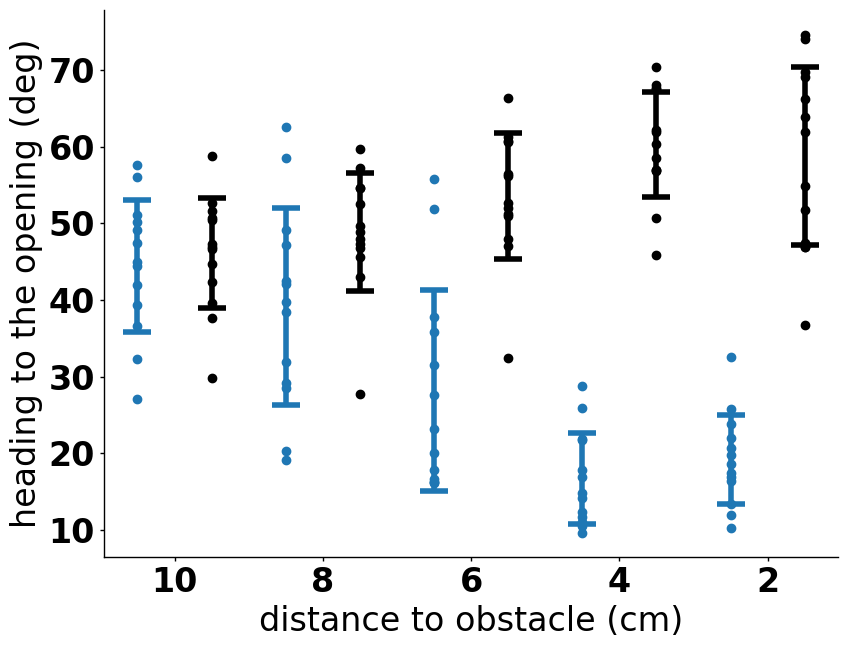

In [464]:
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
fig,ax = plt.subplots(layout = 'tight',figsize = (9,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])



ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
light_std= np.nanstd(light_medians[:,10])
dark_std= np.nanstd(dark_medians[:,10])
ax.errorbar([0],[np.nanmean(light_medians[:,10])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([1],[np.nanmean(dark_medians[:,10])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)
#ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
#ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
light_std= np.nanstd(light_medians[:,12])
dark_std= np.nanstd(dark_medians[:,12])
ax.errorbar([2],[np.nanmean(light_medians[:,12])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([3],[np.nanmean(dark_medians[:,12])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
light_std= np.nanstd(light_medians[:,14])
dark_std= np.nanstd(dark_medians[:,14])
ax.errorbar([4],[np.nanmean(light_medians[:,14])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([5],[np.nanmean(dark_medians[:,14])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
light_std= np.nanstd(light_medians[:,16])
dark_std= np.nanstd(dark_medians[:,16])
ax.errorbar([6],[np.nanmean(light_medians[:,16])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([7],[np.nanmean(dark_medians[:,16])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
light_std= np.nanstd(light_medians[:,18])
dark_std= np.nanstd(dark_medians[:,18])
ax.errorbar([8],[np.nanmean(light_medians[:,18])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([9],[np.nanmean(dark_medians[:,18])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)


ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')


In [ ]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(0, 100, 5)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=0))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=100))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=0))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=100))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=0))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=100))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=0))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=100))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')
ax.set_ylim(0,.14)
ax.set_xlim(0,95)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))

In [501]:
len(dark_medians)

13

In [465]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat,i)

F_onewayResult(statistic=3.3471034419370698, pvalue=0.07977461586949013) 20
F_onewayResult(statistic=5.822134746956699, pvalue=0.02382609323526618) 19
F_onewayResult(statistic=5.461531042746096, pvalue=0.028113731207279273) 18
F_onewayResult(statistic=5.519747119861658, pvalue=0.027366895042811815) 17
F_onewayResult(statistic=3.134398275179896, pvalue=0.08935990878063757) 16
F_onewayResult(statistic=2.1382154961244493, pvalue=0.15664127755763427) 15
F_onewayResult(statistic=1.4516414054787132, pvalue=0.24001154402314437) 14
F_onewayResult(statistic=0.5424828946512812, pvalue=0.46854451984732903) 13
F_onewayResult(statistic=0.22541475855087126, pvalue=0.6392366856314647) 12
F_onewayResult(statistic=0.3365329543538075, pvalue=0.5672444204023145) 11
F_onewayResult(statistic=0.25170670217531765, pvalue=0.6204473447585588) 10
F_onewayResult(statistic=1.5488709854342908, pvalue=0.22531909409629997) 9
F_onewayResult(statistic=5.081532032849492, pvalue=0.033584782399987946) 8
F_onewayResult(st

In [ ]:
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=10))]
    counts, bins = np.histogram(ani_light_dists, bins=11)
    light_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')   

In [478]:
xnew

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175])

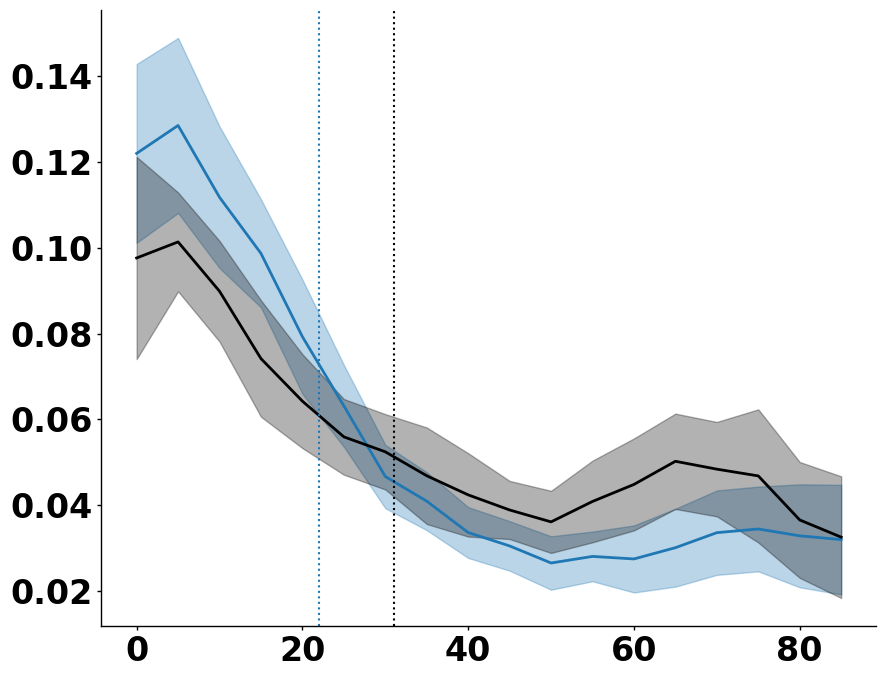

In [424]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(0, 90, 5)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=1))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=0))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=90))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=1))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=0))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=90))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=1))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=0))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=90))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=1))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=0))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=90))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')


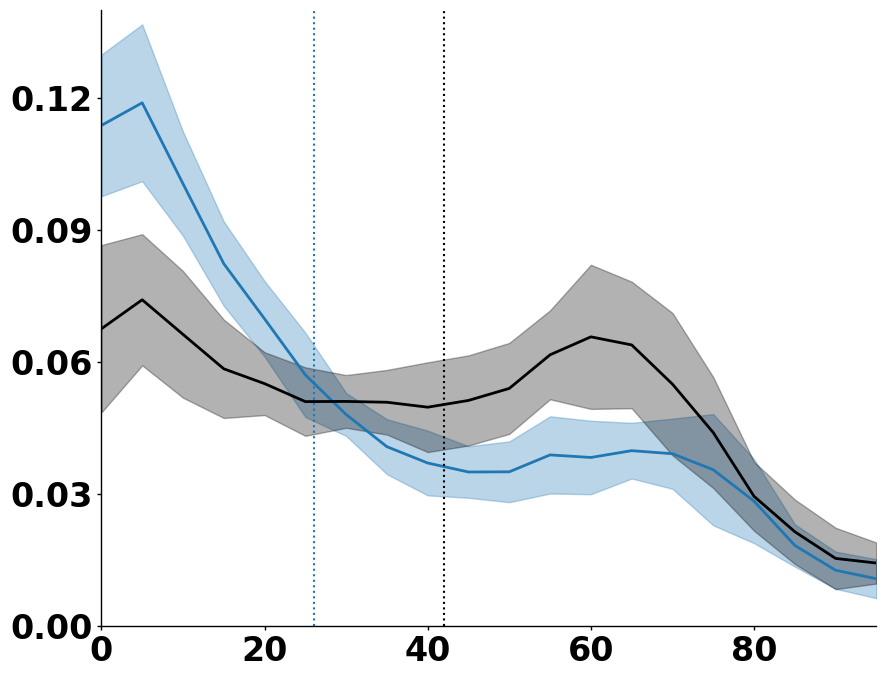

In [534]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(0, 100, 5)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=0))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=100))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=0))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=100))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=0))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=100))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=0))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=100))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')
ax.set_ylim(0,.14)
ax.set_xlim(0,95)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))

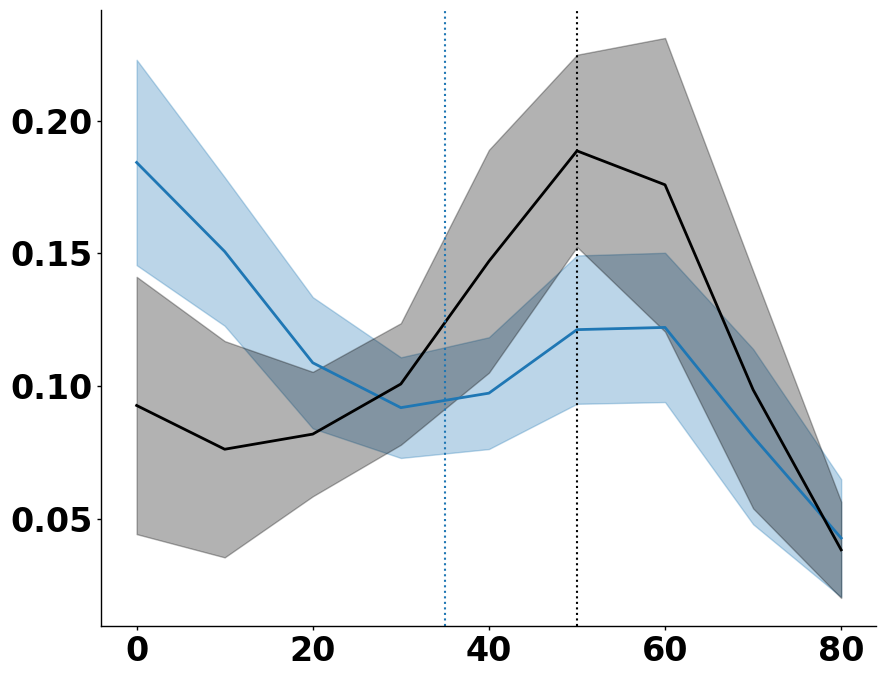

In [436]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(0, 90, 10)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=10)&(row.ts_distance_from_edge>=5))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=0))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=90))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=10)&(row.ts_distance_from_edge>=5))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=0))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=90))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=10)&(row.ts_distance_from_edge>=5))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=0))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=90))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=10)&(row.ts_distance_from_edge>=5))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=0))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=90))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')

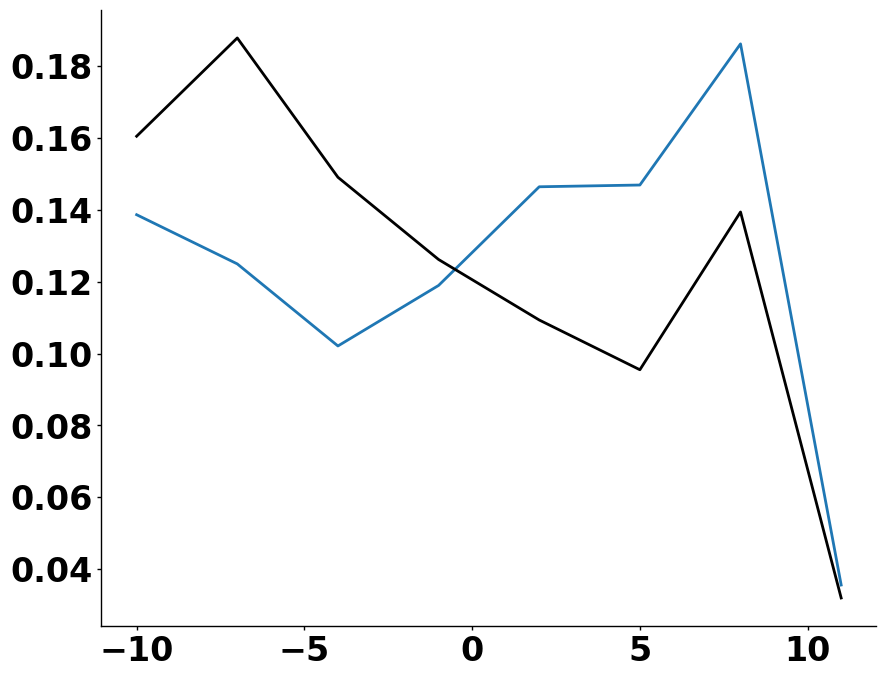

In [433]:
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(-10, 12, 3)
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.task == 'oa']
occup_arr = []
for ind, row in data.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.lateral_error[thresh].astype(float))
    occup_arr.append(angs)
occup_arr = np.asarray(flatten_list_of_arrays(occup_arr))
occup_arr = occup_arr[np.where((occup_arr>=-10))]
occup_arr = occup_arr[np.where((occup_arr<=10))]

light_counts, light_bins = np.histogram(occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')

data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.task == 'oadark']
occup_arr = []
for ind, row in data.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.lateral_error[thresh].astype(float))
    occup_arr.append(angs)
occup_arr = np.asarray(flatten_list_of_arrays(occup_arr))
occup_arr = occup_arr[np.where((occup_arr>=-10))]
occup_arr = occup_arr[np.where((occup_arr<=10))]

dark_counts, dark_bins = np.histogram(occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')

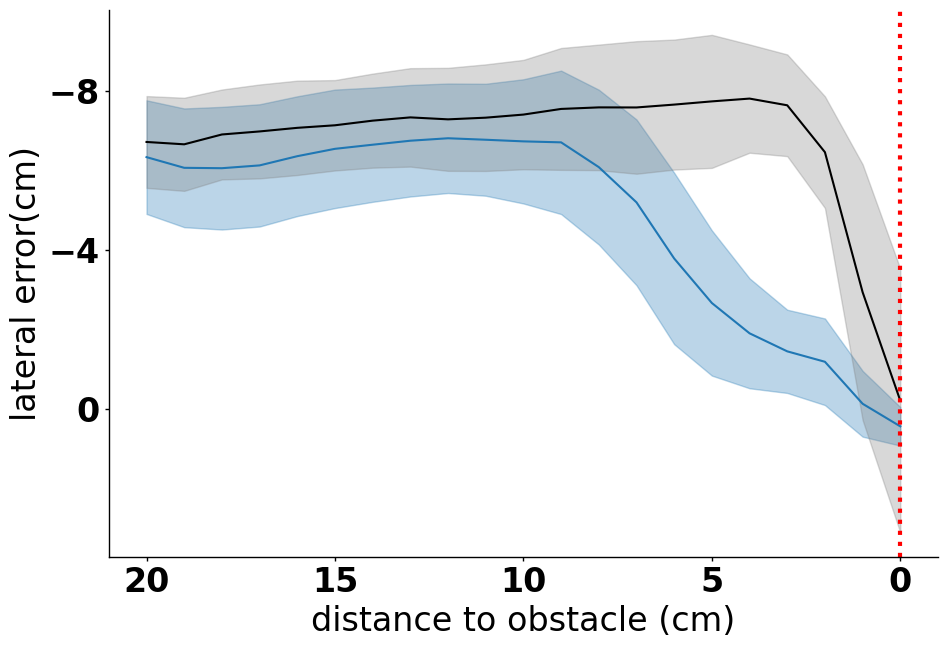

In [490]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
#ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_population_lateral_error_first_occurance.pdf',dpi = 300, transparent=True)


In [495]:
data.animal.unique()

array(['J701LT', 'J701RT', 'J701NN', 'J701RN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN', 'J704RT', 'J704NN', 'J704LT', 'J704LN'], dtype=object)

Text(0.5, 0, 'distance to obstacle (cm)')

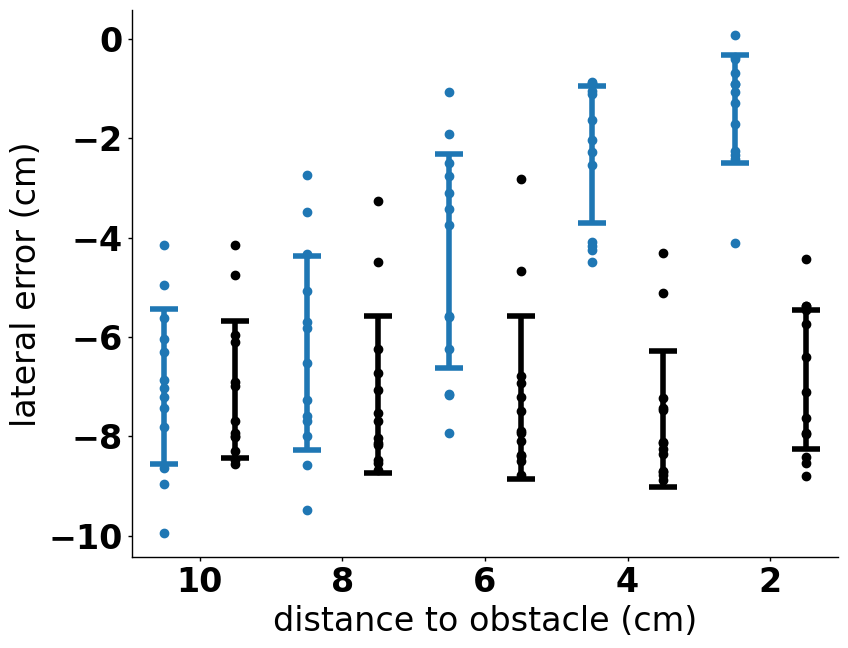

In [491]:
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
fig,ax = plt.subplots(layout = 'tight',figsize = (9,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])



ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
light_std= np.nanstd(light_medians[:,10])
dark_std= np.nanstd(dark_medians[:,10])
ax.errorbar([0],[np.nanmean(light_medians[:,10])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([1],[np.nanmean(dark_medians[:,10])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)
#ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
#ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:, 10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
light_std= np.nanstd(light_medians[:,12])
dark_std= np.nanstd(dark_medians[:,12])
ax.errorbar([2],[np.nanmean(light_medians[:,12])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([3],[np.nanmean(dark_medians[:,12])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
light_std= np.nanstd(light_medians[:,14])
dark_std= np.nanstd(dark_medians[:,14])
ax.errorbar([4],[np.nanmean(light_medians[:,14])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([5],[np.nanmean(dark_medians[:,14])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
light_std= np.nanstd(light_medians[:,16])
dark_std= np.nanstd(dark_medians[:,16])
ax.errorbar([6],[np.nanmean(light_medians[:,16])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([7],[np.nanmean(dark_medians[:,16])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
light_std= np.nanstd(light_medians[:,18])
dark_std= np.nanstd(dark_medians[:,18])
ax.errorbar([8],[np.nanmean(light_medians[:,18])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([9],[np.nanmean(dark_medians[:,18])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)


ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')

In [492]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat,i)

F_onewayResult(statistic=0.2833664260165376, pvalue=0.5993973089051872) 20
F_onewayResult(statistic=0.4148659628809633, pvalue=0.5256184042000546) 19
F_onewayResult(statistic=0.45529313230438473, pvalue=0.5062806760142807) 18
F_onewayResult(statistic=0.30491689147677553, pvalue=0.5859223676404658) 17
F_onewayResult(statistic=0.10175894915599724, pvalue=0.7524887768446236) 16
F_onewayResult(statistic=0.04154036247575387, pvalue=0.8402167804949153) 15
F_onewayResult(statistic=0.005796596304149897, pvalue=0.9399425140366658) 14
F_onewayResult(statistic=0.01571801504945646, pvalue=0.9012737298860516) 13
F_onewayResult(statistic=0.01018278318975444, pvalue=0.9204603655709434) 12
F_onewayResult(statistic=0.003576040572212558, pvalue=0.9528100913002698) 11
F_onewayResult(statistic=0.012448513480039067, pvalue=0.9120899406503541) 10
F_onewayResult(statistic=0.25893075341781774, pvalue=0.6155020384758464) 9
F_onewayResult(statistic=1.306194455655698, pvalue=0.2643581209418266) 8
F_onewayResult(

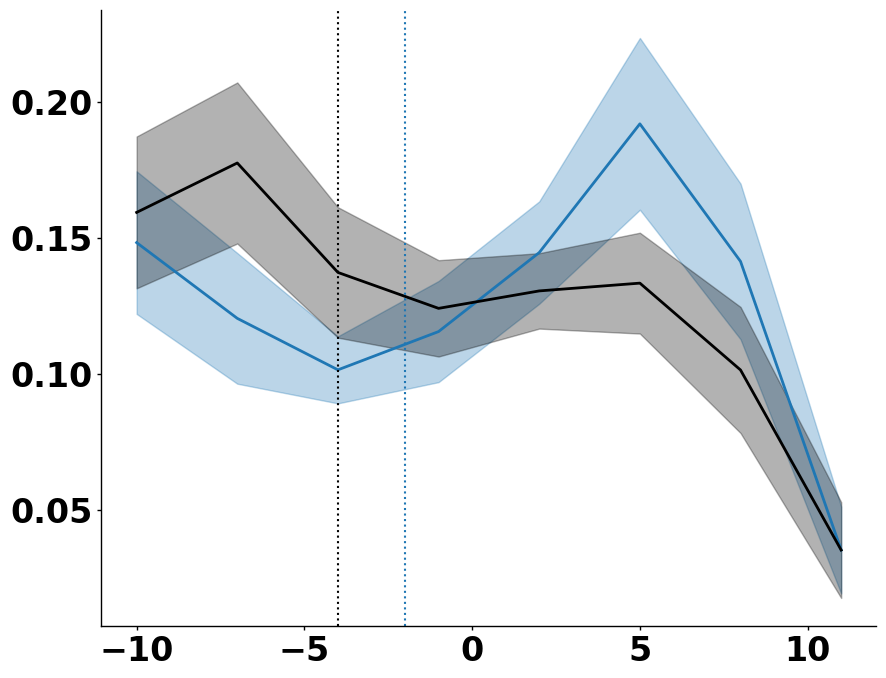

In [540]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(-10, 12, 3)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=6)&(row.ts_distance_from_edge>=1))
    angs = np.round(row.lateral_error[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=-10))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=10))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=6)&(row.ts_distance_from_edge>=1))
        angs = np.round(row.lateral_error[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=-10))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=6))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=6)&(row.ts_distance_from_edge>=1))
    angs = np.round(row.lateral_error[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=-10))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=10))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=6)&(row.ts_distance_from_edge>=1))
        angs = np.round(row.lateral_error[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=-10))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=10))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')

In [1]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data,'obstacle_ind')
#data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
#ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_population_lateral_error_first_occurance.pdf',dpi = 300, transparent=True)


NameError: name 'np' is not defined

Text(0.5, 0, 'distance to obstacle (cm)')

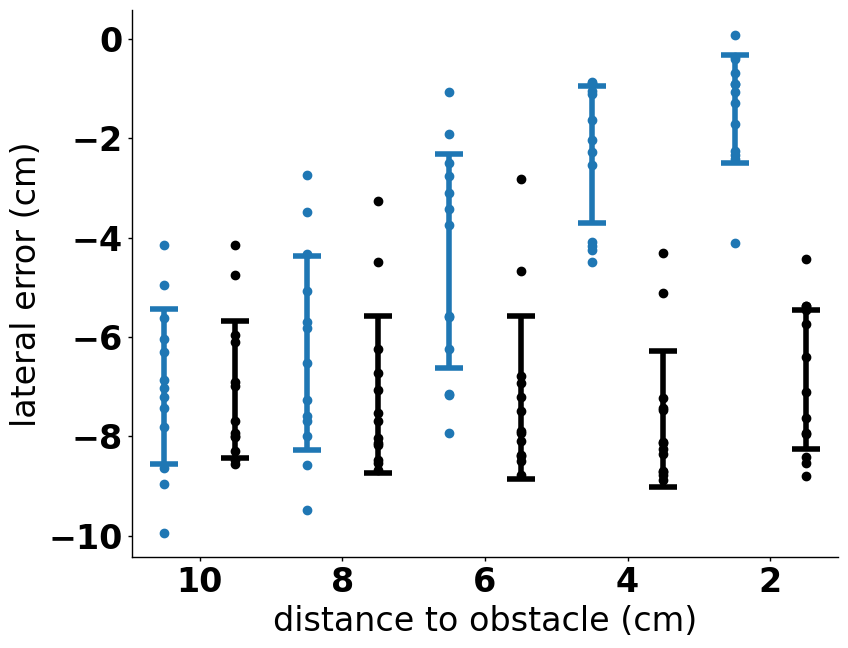

In [456]:
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
fig,ax = plt.subplots(layout = 'tight',figsize = (9,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])



ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
light_std= np.nanstd(light_medians[:,10])
dark_std= np.nanstd(dark_medians[:,10])
ax.errorbar([0],[np.nanmean(light_medians[:,10])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([1],[np.nanmean(dark_medians[:,10])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)
#ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
#ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
light_std= np.nanstd(light_medians[:,12])
dark_std= np.nanstd(dark_medians[:,12])
ax.errorbar([2],[np.nanmean(light_medians[:,12])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([3],[np.nanmean(dark_medians[:,12])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
light_std= np.nanstd(light_medians[:,14])
dark_std= np.nanstd(dark_medians[:,14])
ax.errorbar([4],[np.nanmean(light_medians[:,14])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([5],[np.nanmean(dark_medians[:,14])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
light_std= np.nanstd(light_medians[:,16])
dark_std= np.nanstd(dark_medians[:,16])
ax.errorbar([6],[np.nanmean(light_medians[:,16])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([7],[np.nanmean(dark_medians[:,16])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
light_std= np.nanstd(light_medians[:,18])
dark_std= np.nanstd(dark_medians[:,18])
ax.errorbar([8],[np.nanmean(light_medians[:,18])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([9],[np.nanmean(dark_medians[:,18])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)


ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')

In [458]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat,i)


F_onewayResult(statistic=0.2833664260165376, pvalue=0.5993973089051872) 20
F_onewayResult(statistic=0.4148659628809633, pvalue=0.5256184042000546) 19
F_onewayResult(statistic=0.45529313230438473, pvalue=0.5062806760142807) 18
F_onewayResult(statistic=0.30491689147677553, pvalue=0.5859223676404658) 17
F_onewayResult(statistic=0.10175894915599724, pvalue=0.7524887768446236) 16
F_onewayResult(statistic=0.04154036247575387, pvalue=0.8402167804949153) 15
F_onewayResult(statistic=0.005796596304149897, pvalue=0.9399425140366658) 14
F_onewayResult(statistic=0.01571801504945646, pvalue=0.9012737298860516) 13
F_onewayResult(statistic=0.01018278318975444, pvalue=0.9204603655709434) 12
F_onewayResult(statistic=0.003576040572212558, pvalue=0.9528100913002698) 11
F_onewayResult(statistic=0.012448513480039067, pvalue=0.9120899406503541) 10
F_onewayResult(statistic=0.25893075341781774, pvalue=0.6155020384758464) 9
F_onewayResult(statistic=1.306194455655698, pvalue=0.2643581209418266) 8
F_onewayResult(

Text(0.5, 0.98, 'joint')

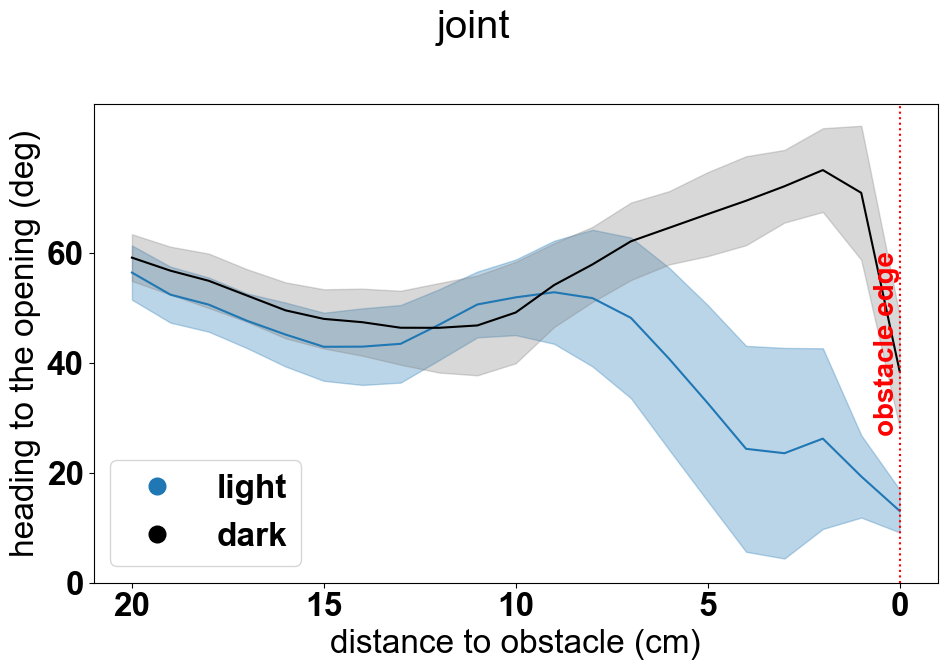

In [31]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart,short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('joint')

In [51]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([long_nostart,short_nostart])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)


Text(0.5, 0.98, 'joint')

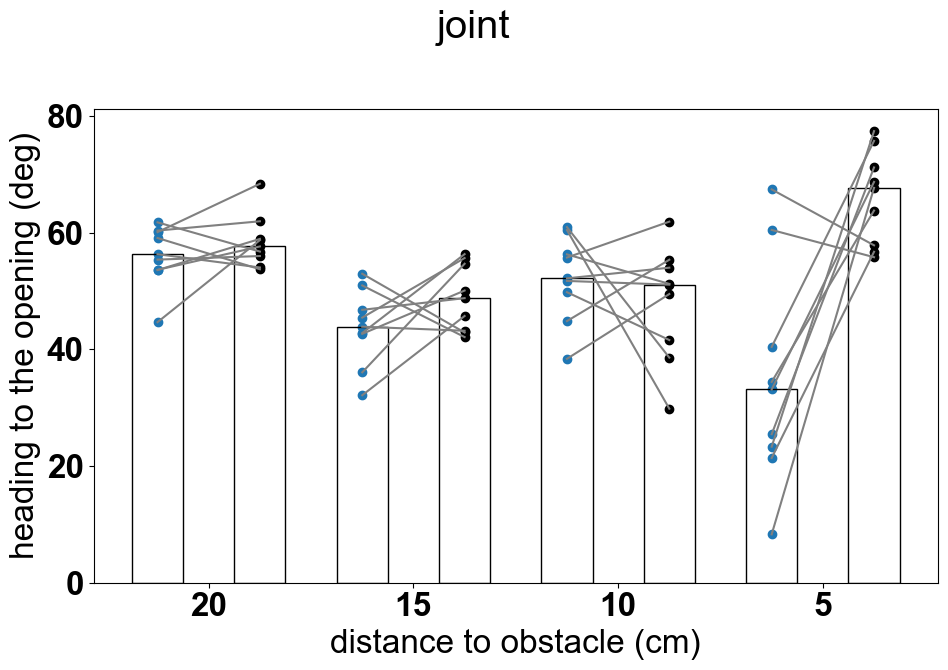

In [52]:
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('joint')

Text(0.5, 0.98, 'joint')

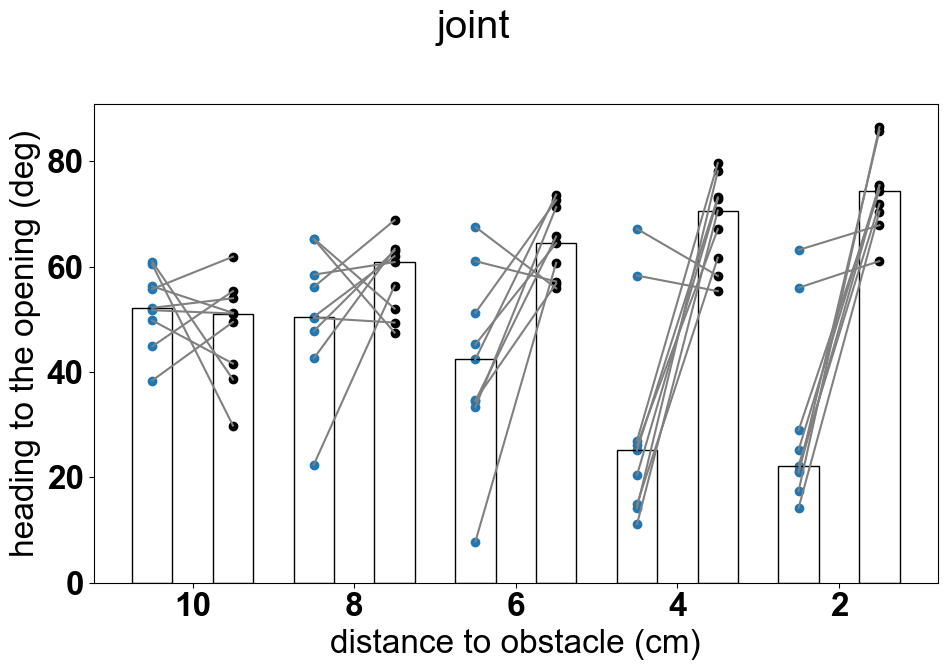

In [53]:
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,12],dark_medians[:,12]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,14],dark_medians[:,14]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,16],dark_medians[:,16]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.bar(8,np.nanmedian(light_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
ax.bar(9,np.nanmedian(dark_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],8),np.full(dark_medians.shape[0],9)),(light_medians[:,18],dark_medians[:,18]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('joint')



In [131]:
f_oneway(dark_medians[:,1],light_medians[:,1])

F_onewayResult(statistic=4.878235802044109, pvalue=0.042131356934708014)

In [54]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat,i)



F_onewayResult(statistic=1.0531404232753245, pvalue=0.3200506526112995) 20
F_onewayResult(statistic=3.56558999040223, pvalue=0.07725863751235792) 19
F_onewayResult(statistic=2.5890470296918595, pvalue=0.12715563026795643) 18
F_onewayResult(statistic=4.310156625692577, pvalue=0.05436246406283614) 17
F_onewayResult(statistic=3.3783383619141434, pvalue=0.08469837945105797) 16
F_onewayResult(statistic=3.0745020920894772, pvalue=0.09866223408835402) 15
F_onewayResult(statistic=1.5323938077769228, pvalue=0.23361135639858002) 14
F_onewayResult(statistic=0.42555065300497874, pvalue=0.5234425427933783) 13
F_onewayResult(statistic=0.1511554023672835, pvalue=0.7025586973751916) 12
F_onewayResult(statistic=1.6858845710765809, pvalue=0.21254825118891213) 11
F_onewayResult(statistic=1.03824543126862, pvalue=0.32339081686113835) 10
F_onewayResult(statistic=0.06483570674251628, pvalue=0.8022537404411956) 9
F_onewayResult(statistic=2.0557174955486506, pvalue=0.17088962987846387) 8
F_onewayResult(statis

Long trials angle to corner 

Text(0.5, 0.98, 'long')

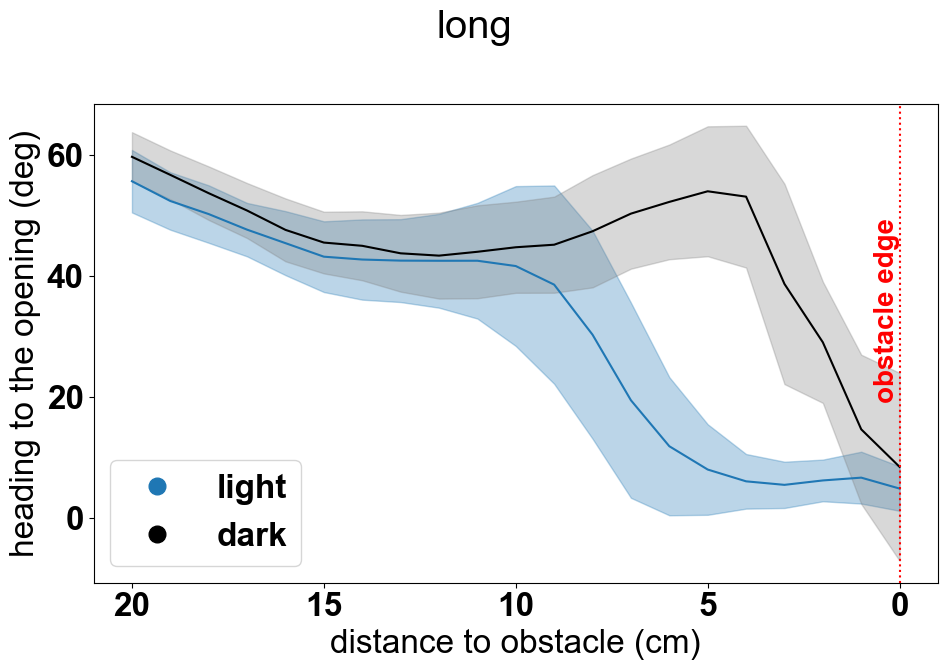

In [32]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long')

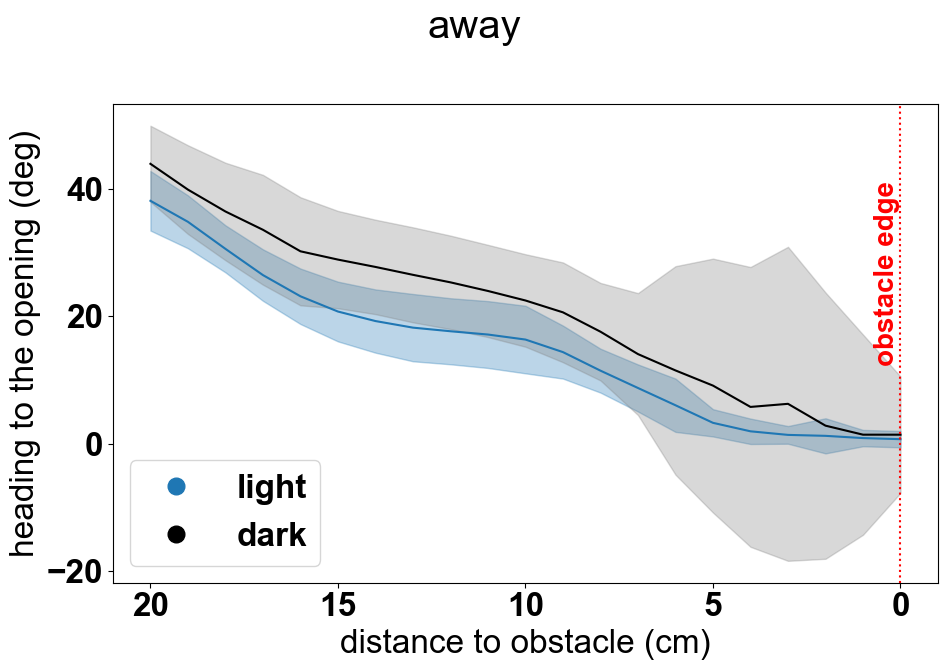

In [62]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'away']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

#for i in list(range(light_medians.shape[1])):
#    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
#    light_sd.append(sd)
#light_sd = np.asarray(light_sd)
#
#for i in list(range(dark_medians.shape[1])):
#    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
#    dark_sd.append(sd)
#dark_sd = np.asarray(dark_sd)
#
            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
#ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('away')
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_heading_away.pdf',dpi = 300, transparent=True)

Text(0.5, 0.98, 'long towards first occurance')

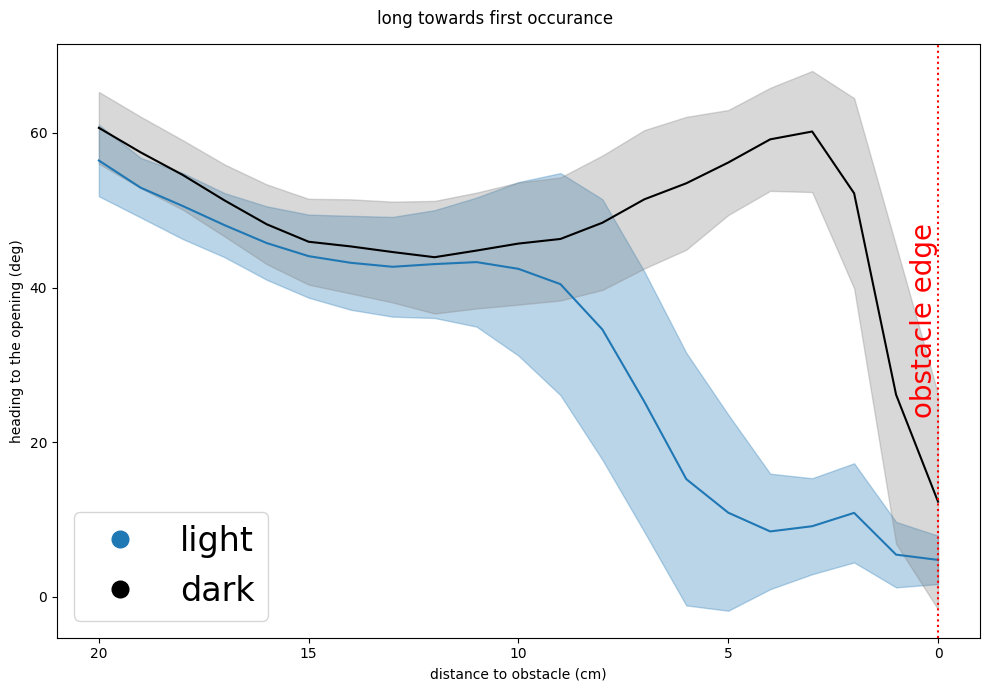

In [ ]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data,'obstacle_ind')
#data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

#for i in list(range(light_medians.shape[1])):
#    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
#    light_sd.append(sd)
#light_sd = np.asarray(light_sd)
#
#for i in list(range(dark_medians.shape[1])):
#    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
#    dark_sd.append(sd)
#dark_sd = np.asarray(dark_sd)
#
            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long towards first occurance')
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_heading_towards.pdf',dpi = 300, transparent=True)

In [29]:
long.groupby('task').animal.unique().to_numpy()

array([array(['J701LT', 'J701RT', 'J701NN', 'J701RN', 'G8CK1RT', 'G8CK1LT',
              'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
              'G8CKLN'], dtype=object)                                     ,
       array(['J704RT', 'J704NN', 'J704LT', 'J704LN', 'G8CK1RT', 'G8CK1LT',
              'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
              'G8CKLN'], dtype=object)                                     ],
      dtype=object)

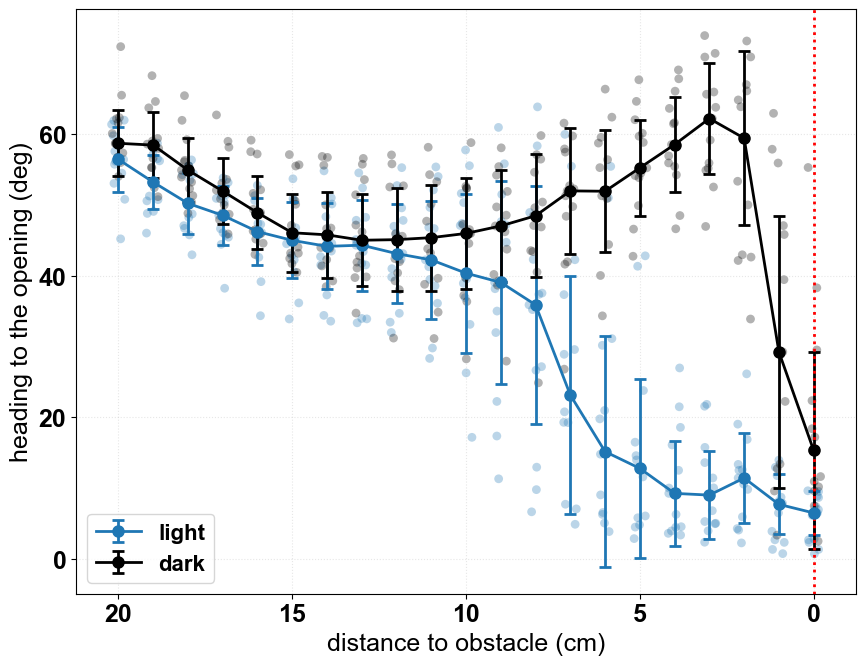

In [70]:
# Set font parameters to match previous plots
font = {'family': 'arial',
        
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data, 'obstacle_ind')

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sd, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sd, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to the opening (deg)', fontsize=18)
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)
ax.axvline(0, color='r', ls=':', linewidth=2)

# Legend with matching style
ax.legend(loc='lower left', fontsize=16, framealpha=0.8)

# Grid lines for readability
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

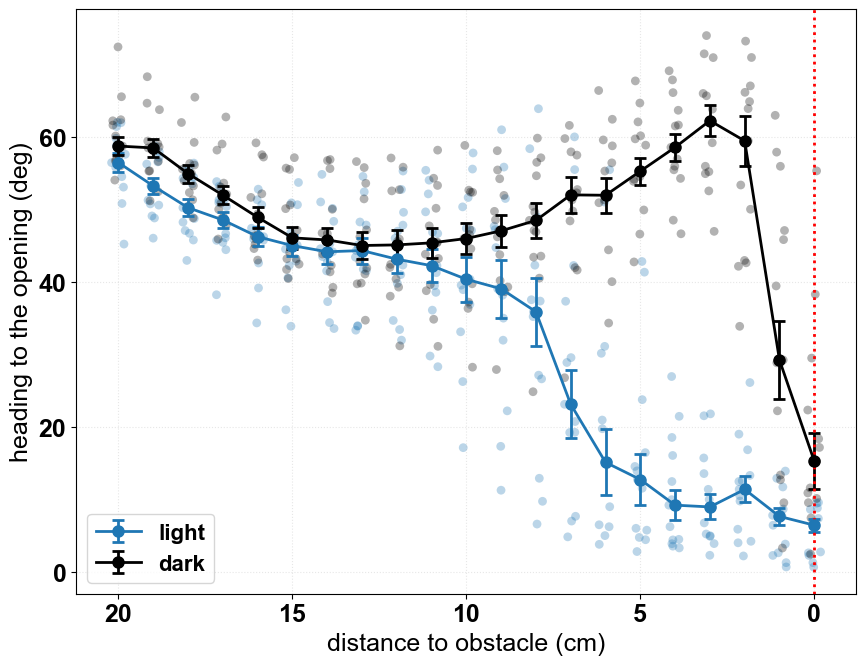

In [131]:
# Set font parameters to match previous plots
font = {'family': 'arial',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data, 'obstacle_ind')

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to the opening (deg)', fontsize=18)
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)
ax.axvline(0, color='r', ls=':', linewidth=2)

# Legend with matching style
ax.legend(loc='lower left', fontsize=16, framealpha=0.8)

# Grid lines for readability
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
list_columns(long,['angle'])

array(['ts_angle_to_corner', 'ts_leye_angle_to_corner',
       'ts_reye_angle_to_corner', 'ts_body_angle_to_corner',
       'ts_angle_to_target_port', 'ts_zero_out_angle_to_corner',
       'head_angle', 'head_angle_velocity', 'angle_to_rightport',
       'angle_to_leftport', 'resample_angle_to_leftport',
       'resample_angle_to_rightport', 'head_corner_angle_velocity',
       'intial_head_angle_velocity',
       'head_corner_angle_velocity_at_head_turn', 'angle_at_head_turn',
       'ts_zero_out_angle_to_target_port', 'angle_at_head_turn_2'],
      dtype='<U39')

In [50]:
def goal_port(df):
    for ind,row in df.iterrows():
        ob_ind = int(row.obstacle_ind)
        df.at[ind,'goal_distance_from_target_port'] = row.ts_distance_from_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_angle_to_target_port'] = row.ts_angle_to_target_port[ob_ind:].astype(object)
        df.at[ind,'goal_lateral_error_to_target_port'] = row.ts_lateral_error_to_target_port[ob_ind:].astype(object)
    

In [51]:
goal_port(long)

In [1]:
long

NameError: name 'long' is not defined

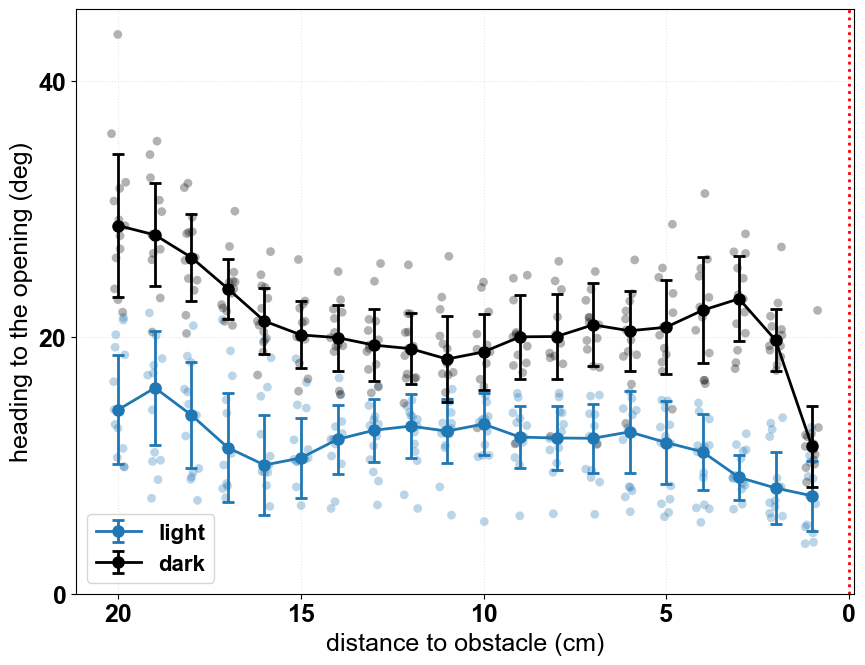

In [57]:
# Set font parameters to match previous plots
font = {'family': 'arial',
        
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data, 'obstacle_ind')

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['goal_distance_from_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['goal_angle_to_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sd, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sd, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40])
ax.set_ylabel('heading to the opening (deg)', fontsize=18)
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)
ax.axvline(0, color='r', ls=':', linewidth=2)

# Legend with matching style
ax.legend(loc='lower left', fontsize=16, framealpha=0.8)

# Grid lines for readability
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

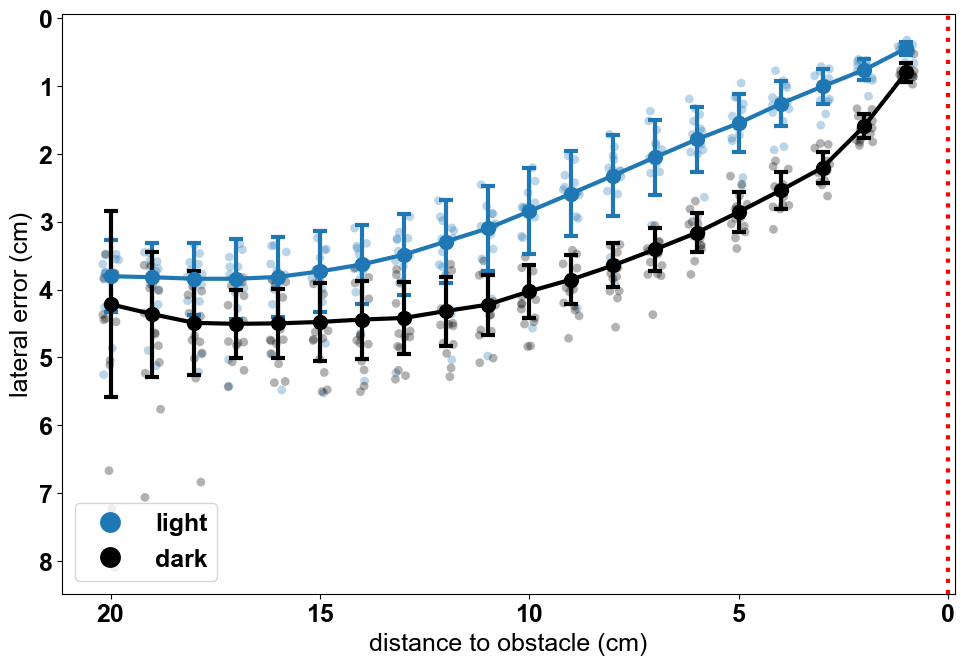

In [55]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(10,7))

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['goal_distance_from_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['goal_lateral_error_to_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['goal_distance_from_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['goal_lateral_error_to_target_port'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker lines for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sd,
           color='tab:blue', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sd,
           color='black', linewidth=3, marker='o', markersize=10,
           capsize=5, capthick=3, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
#ax.set_yticks([-8,-4,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)
ax.invert_yaxis()

# Legend with larger markers matching previous plots
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

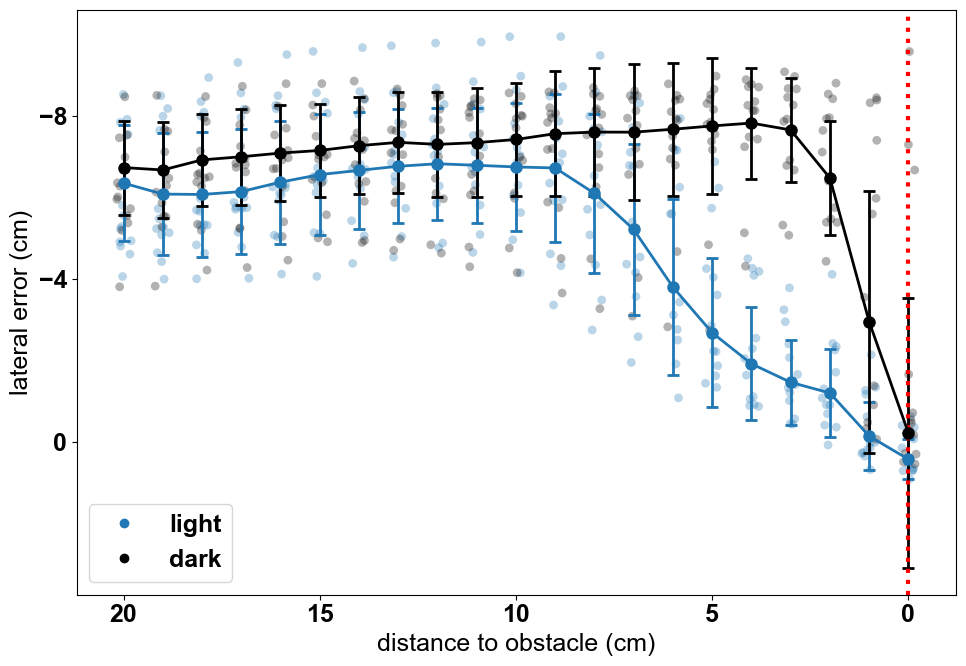

In [74]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(10,7))

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)


# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sd,
           color='tab:blue', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sd,
           color='black', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-8,-4,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)
ax.invert_yaxis()

# Legend
markers = [plt.Line2D([0],[0], color='tab:blue', marker='o', linestyle=''),
           plt.Line2D([0],[0], color='black', marker='o', linestyle='')]
ax.legend(markers, ['light', 'dark'], numpoints=1, loc='lower left', fontsize=18)

plt.tight_layout()
plt.show()

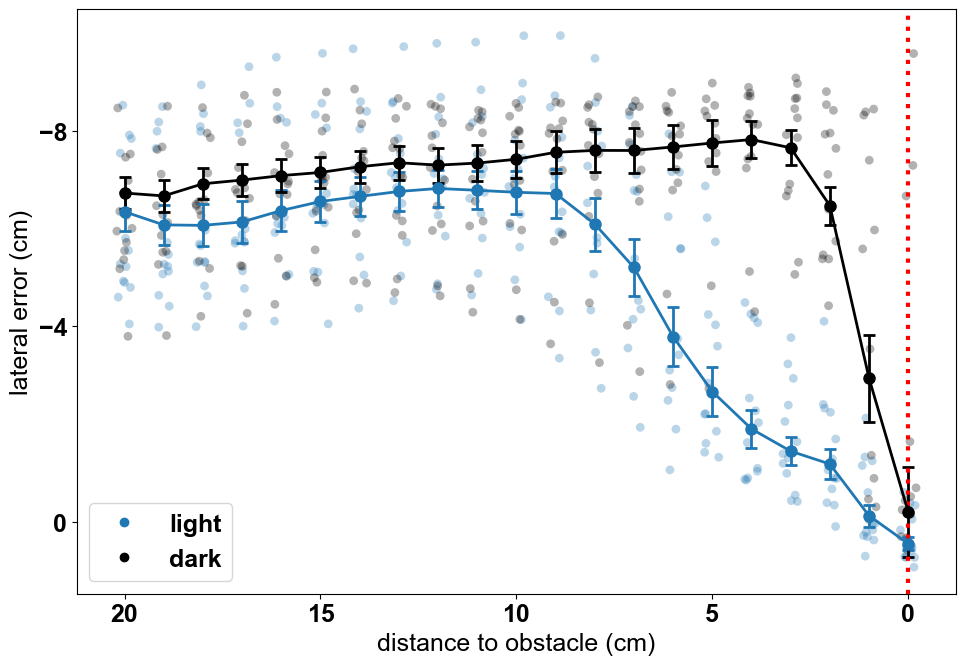

In [75]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(10,7))

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SEM instead of SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

# Calculate number of non-nan observations for each distance point
light_n = np.sum(~np.isnan(light_medians), axis=0)
dark_n = np.sum(~np.isnan(dark_medians), axis=0)

# Calculate standard error of the mean
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(light_n)
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(dark_n)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem,
           color='tab:blue', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem,
           color='black', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-8,-4,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)
ax.invert_yaxis()

# Legend
markers = [plt.Line2D([0],[0], color='tab:blue', marker='o', linestyle=''),
           plt.Line2D([0],[0], color='black', marker='o', linestyle='')]
ax.legend(markers, ['light', 'dark'], numpoints=1, loc='lower left', fontsize=18)

plt.tight_layout()
plt.show()

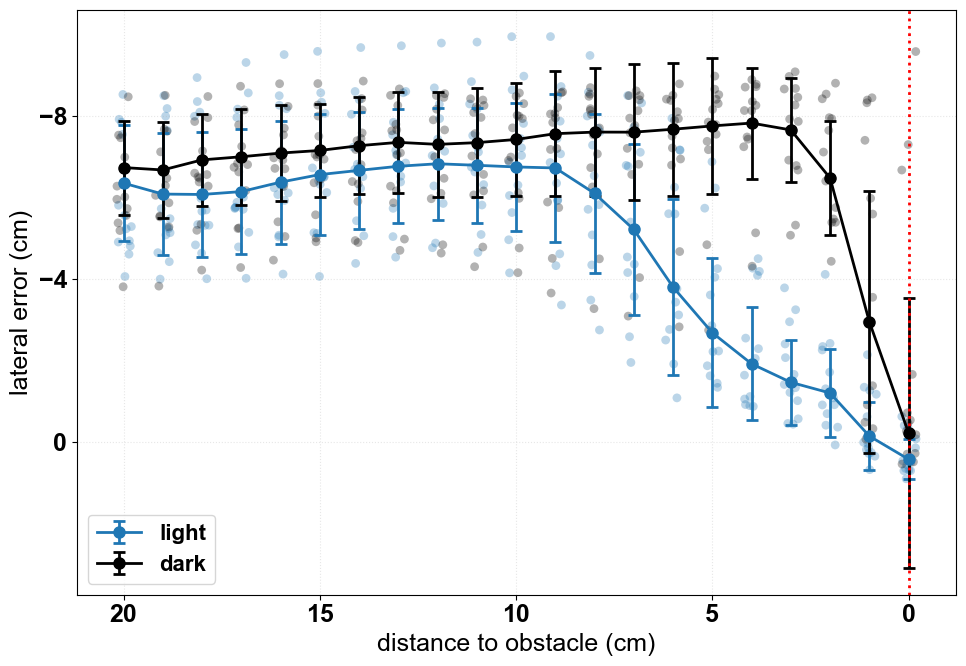

In [19]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(10,7))

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (with updated marker style to match second plot)
ax.errorbar(xnew, light_angle_median, yerr=light_sd,
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sd,
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-8,-4,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=2)  # Matched linewidth to second plot
ax.invert_yaxis()

# Add grid lines to match second plot
ax.grid(True, linestyle=':', alpha=0.3)

# Updated legend to match second plot's style
ax.legend(loc='lower left', fontsize=16, framealpha=0.8)

plt.tight_layout()
plt.show()

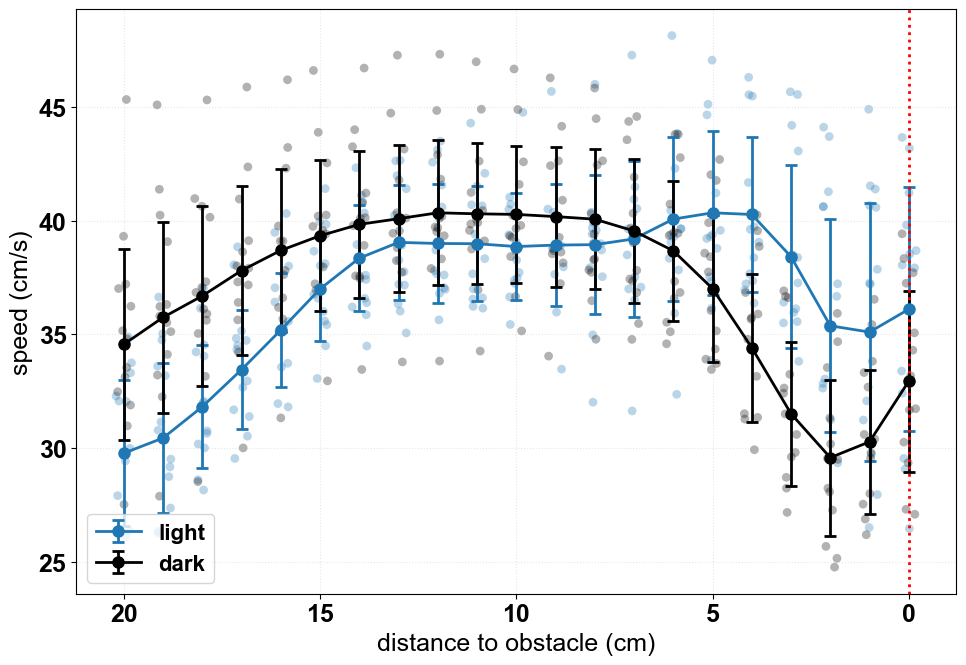

In [22]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(10,7))

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_speed'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_speed'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (with updated marker style to match second plot)
ax.errorbar(xnew, light_angle_median, yerr=light_sd,
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sd,
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])

ax.set_ylabel('speed (cm/s)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=2)  # Matched linewidth to second plot


# Add grid lines to match second plot
ax.grid(True, linestyle=':', alpha=0.3)

# Updated legend to match second plot's style
ax.legend(loc='lower left', fontsize=16, framealpha=0.8)

plt.tight_layout()
plt.show()

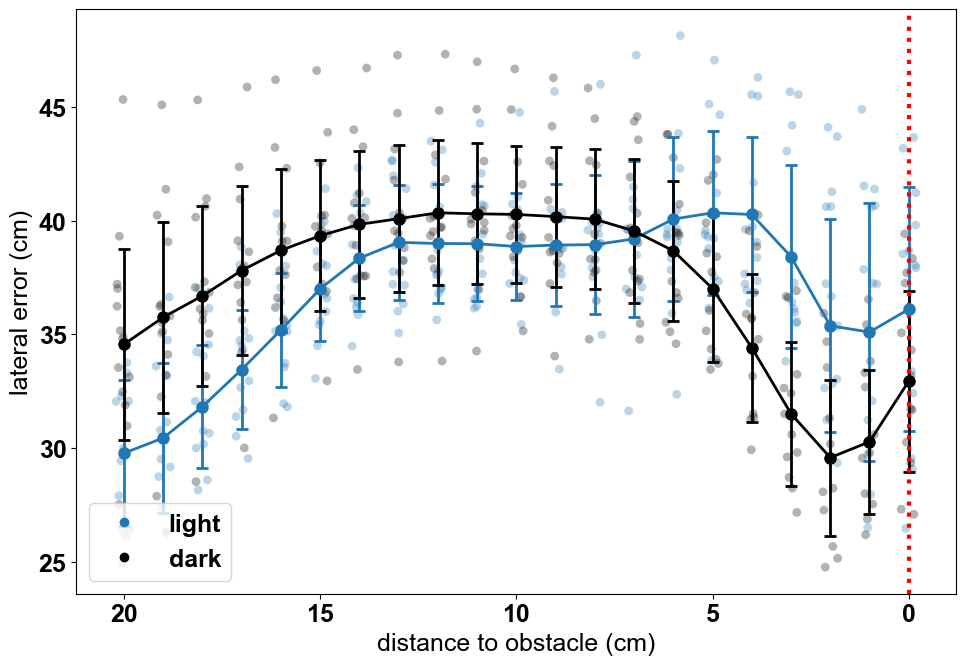

In [15]:
# Set font parameters
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(10,7))

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']

light_medians = []
dark_medians = []
light_scatter = []  # Store individual animal points
dark_scatter = []   # Store individual animal points

for task, task_df in data.groupby(['task']):
    rows = task_df.shape[0]
    angle_array = np.empty([rows, len(xnew)])
    angle_array[:] = np.nan
    
    for i, row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_speed'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        
        if sum(y) != 0:
            interpolater = interp1d(x1, y1, bounds_error=False)
            angle_array[i] = interpolater(xnew)
    
    if task == 'oa':
        light_angle_median = np.nanmedian(angle_array, axis=0)
    else:
        dark_angle_median = np.nanmedian(angle_array, axis=0)

    for animal, animal_df in task_df.groupby(['animal']):
        animal_angle_array = np.empty([animal_df.shape[0], len(xnew)])
        animal_angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_speed'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                animal_angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(animal_angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate SD
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sd,
           color='tab:blue', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sd,
           color='black', linewidth=2, marker='o', markersize=8,
           capsize=4, capthick=2, label='dark')

# Formatting (matches your original)
ax.set_xticks([20,15,10,5,0])

ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)


# Legend
markers = [plt.Line2D([0],[0], color='tab:blue', marker='o', linestyle=''),
           plt.Line2D([0],[0], color='black', marker='o', linestyle='')]
ax.legend(markers, ['light', 'dark'], numpoints=1, loc='lower left', fontsize=18)

plt.tight_layout()
plt.show()

In [41]:
long.groupby('task').date.unique().to_numpy()

array([array(['030624', '030724', '030824', '031324', '031224', '031424',
              '031524', '051723', '051823', '051923', '052223', '052323',
              '052523', '052623', '042823', '043023', '050123', '050223',
              '050323', '050423', '050523'], dtype=object)               ,
       array(['062424', '062524', '062624', '062724', '072324', '072424',
              '071023', '071123', '071223'], dtype=object)               ],
      dtype=object)

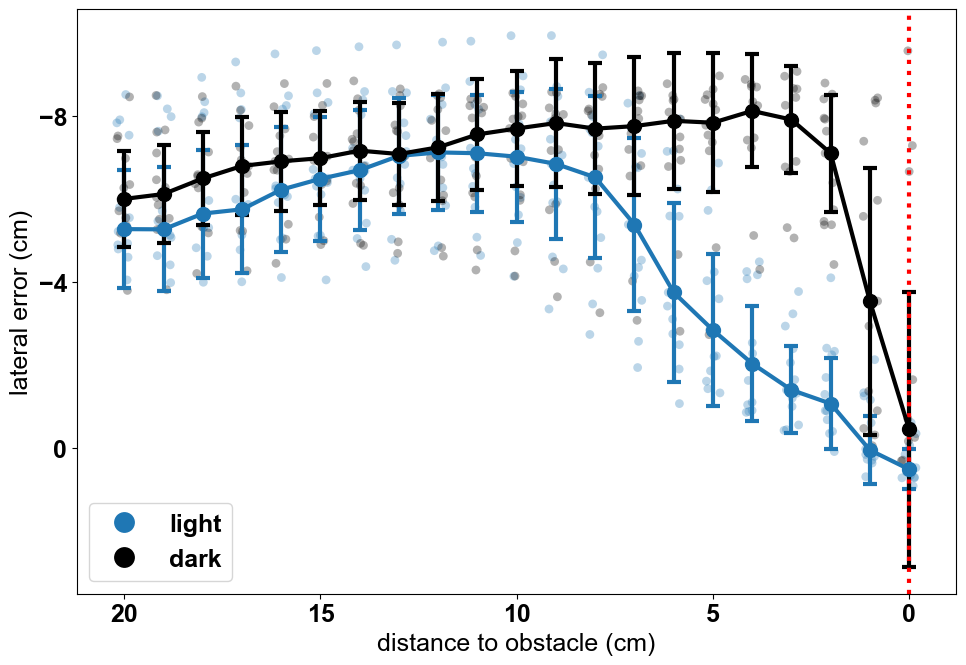

In [30]:
# Set font parameters to match previous plots
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(10,7))

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=3, 
           markersize=10, capsize=5, capthick=3,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sd,
           fmt='-o', color='black', linewidth=3,
           markersize=10, capsize=5, capthick=3,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-8,-4,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':', linewidth=3)
ax.invert_yaxis()

# Legend with large markers matching previous plots
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

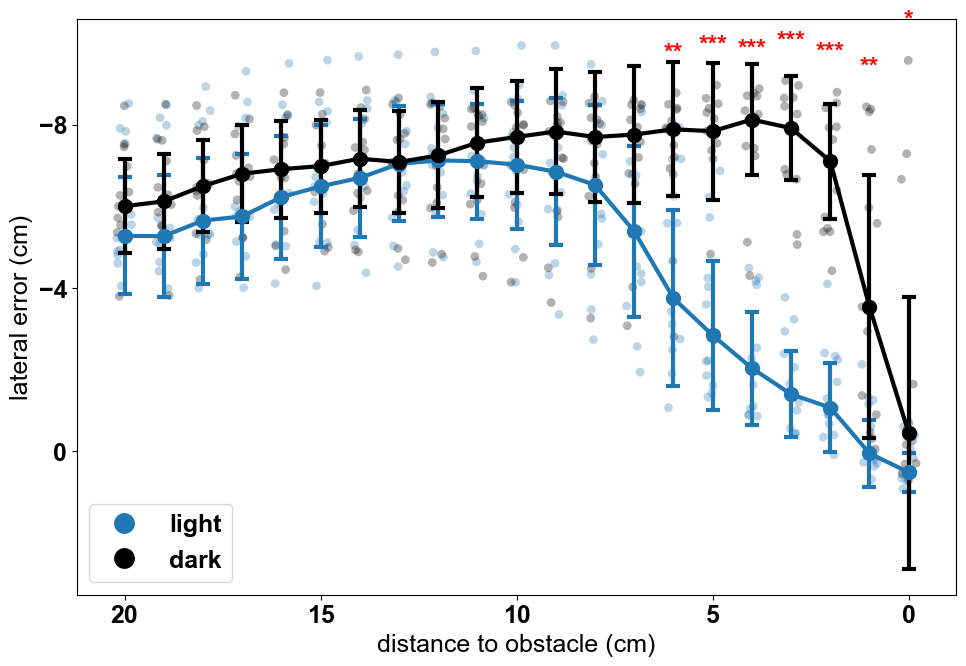

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection

def first_occurrence_indices(arr):
    _, idx = np.unique(arr, return_index=True)
    return np.sort(idx)

def drop_nans_in_columns(df, column):
    return df[~df[column].isna()]

# Set font parameters to match previous plots
font = {'family': 'arial',
        'weight': 'bold',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(10,7))

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data, 'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

light_sd = np.nanstd(light_medians, axis=0)
dark_sd = np.nanstd(dark_medians, axis=0)

# Perform statistical tests for each distance bin
p_values = []
for i in range(len(xnew)):
    # Remove nans from both groups
    light_data = light_medians[:, i][~np.isnan(light_medians[:, i])]
    dark_data = dark_medians[:, i][~np.isnan(dark_medians[:, i])]
    
    if len(light_data) > 3 and len(dark_data) > 3:  # Need enough samples for test
        _, p = mannwhitneyu(light_data, dark_data)
        p_values.append(p)
    else:
        p_values.append(1)  # Not enough data to test

# Apply FDR correction for multiple comparisons
significant, corrected_p = fdrcorrection(p_values, alpha=0.05)

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (thicker for visibility)
ax.errorbar(xnew, light_angle_median, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=3, 
           markersize=10, capsize=5, capthick=3,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sd,
           fmt='-o', color='black', linewidth=3,
           markersize=10, capsize=5, capthick=3,
           label='dark')

# Mark significant differences on the plot with *, **, or ***
for i, (x, p, sig) in enumerate(zip(xnew, corrected_p, significant)):
    if sig:
        # Determine significance level
        if p < 0.001:
            symbol = '***'
        elif p < 0.01:
            symbol = '**'
        elif p < 0.05:
            symbol = '*'
        
        if symbol:  # Only plot if significant
            # Find max y value at this x position to place the symbol above
            y_min = min(np.nanmin(light_medians[:, i]), np.nanmin(dark_medians[:, i]))
            # Add some padding (1 cm) above the max point
            y_pos = y_min  -1.25
            ax.text(x, y_pos, symbol, 
                   ha='center', va='top', 
                   color='red', fontsize=18, fontweight='bold')



# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([-8,-4,0])
ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')
#ax.axvline(0, color='r', ls=':', linewidth=3)
ax.invert_yaxis()

# Legend with large markers matching previous plots
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='light',
              markerfacecolor='tab:blue', markersize=15, markeredgewidth=0),
    plt.Line2D([0], [0], marker='o', color='w', label='dark',
              markerfacecolor='black', markersize=15, markeredgewidth=0)
]

ax.legend(handles=legend_elements, loc='lower left', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

In [58]:
long

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,right_num_turn,right_turns_distances,left_num_turn,left_turns_distances,intial_distance,avg_speed,avg_ts_speed,goal_distance_from_target_port,goal_angle_to_target_port,goal_lateral_error_to_target_port
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,1.0,[2.3336543876011326],2.0,"[1.8804369365781402, 1.8904238936934148]",25.0,20.809365,20.891983,"[20.536981549518085, 20.51853830041654, 20.361...","[22.04616869944721, 28.159448450055024, 33.387...","[3.6050216160984014, 3.861027239236588, 4.1436..."
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,1.0,[21.448106895216092],0.0,[],23.0,17.862486,17.851822,"[22.46647368419632, 22.210636822954093, 21.974...","[29.27554420899936, 28.02386546266077, 28.1157...","[3.578414633038829, 3.7735599341282295, 3.9453..."
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,3.0,"[19.126954831503788, 12.68730852308991, 4.2751...",2.0,"[6.2272710475092765, 2.4417895280408155]",23.0,25.031042,26.860749,"[21.231166203492574, 20.714307559480282, 19.84...","[5.4985704164487395, 9.649263258632539, 7.2602...","[2.985139954262756, 3.297317496898632, 3.37006..."
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,3.0,"[22.825084479564573, 9.934737689725033, 10.338...",1.0,[4.659622630986767],25.0,12.043630,12.924533,"[20.998659730374968, 20.416345610881283, 20.13...","[25.897982581342898, 24.269517945326385, 20.31...","[4.481175634418616, 4.789503458458189, 4.95167..."
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,2.0,"[22.689007941167716, 2.239520390798571]",2.0,"[4.286593988791843, 2.311305803187799]",25.0,19.450888,19.241862,"[21.24527722434056, 21.025392380869405, 20.685...","[40.880691394021795, 42.07548321617006, 40.631...","[5.012633201381018, 5.381500205828456, 5.53690..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14456,14456,58284.241510,58286.769433,"[58284.250803, 58284.267686, 58284.284518, 582...","[10663, 10664, 10665, 10666, 10667, 10668, 106...","[87.75959014892578, 86.99541473388672, 86.5253...","[260.9606018066406, 261.192138671875, 260.8676...","[101.29974365234375, 99.75284576416016, 98.431...","[256.04373168945

In [ ]:
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]

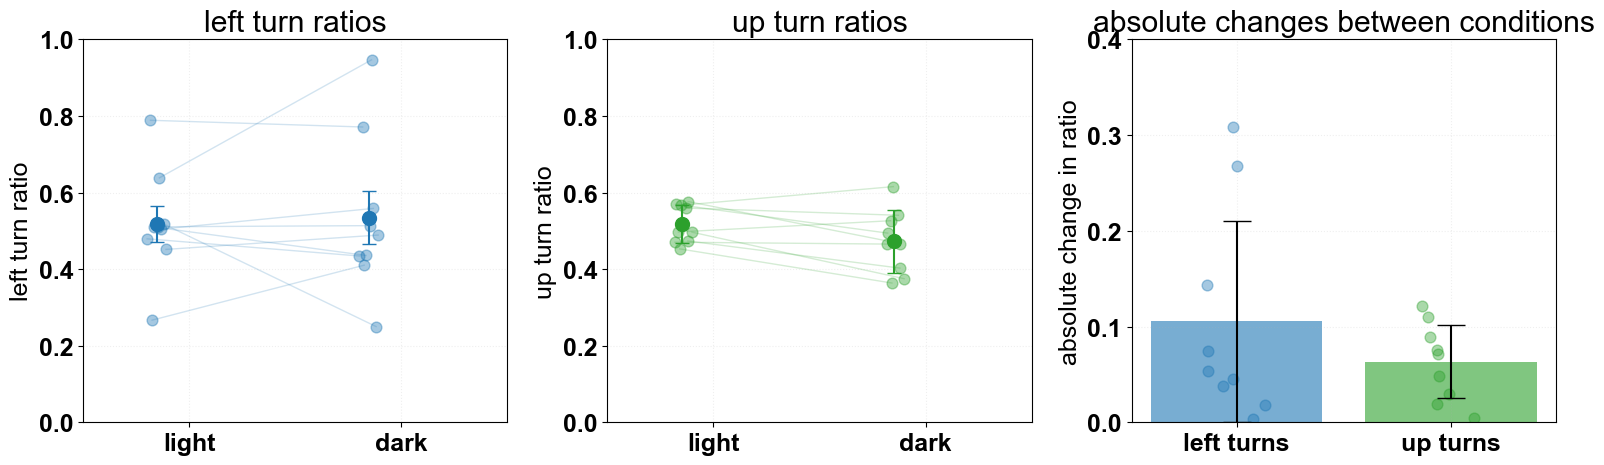

In [111]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# --- data preparation ---
light_data = long[long.task == 'oa']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
light_data = light_data[~light_data.animal.isin(animals_to_drop)]
dark_data = long[long.task == 'oadark']
dark_data = dark_data[~dark_data.animal.isin(animals_to_drop)]

# left/right ratios (only keeping left)
def calculate_lr_ratios(df):
    grouped = df.groupby(['animal', 'turn_direction_left_right']).size().unstack(fill_value=0)
    grouped['left_ratio'] = grouped['left'] / (grouped['left'] + grouped['right'])
    return grouped

# up/down ratios (only keeping up)
def calculate_ud_ratios(df):
    grouped = df.groupby(['animal', 'turn_direction']).size().unstack(fill_value=0)
    grouped['up_ratio'] = grouped['up'] / (grouped['up'] + grouped['down'])
    return grouped

light_lr = calculate_lr_ratios(light_data)
dark_lr = calculate_lr_ratios(dark_data)
light_ud = calculate_ud_ratios(light_data)
dark_ud = calculate_ud_ratios(dark_data)

common_animals = light_lr.index.intersection(dark_lr.index)

# --- plot 1: left turn ratios ---
# adjusted x positions to center better
x_positions = [0.85, 1.85]  # light and dark positions

for animal in common_animals:
    jitter = np.random.uniform(-0.05, 0.05)
    
    # connect points between conditions
    ax1.plot([x_positions[0]+jitter, x_positions[1]+jitter],
            [light_lr.loc[animal, 'left_ratio'], dark_lr.loc[animal, 'left_ratio']],
            color='tab:blue', alpha=0.2, linewidth=1)
    
    # plot individual points
    ax1.scatter(x_positions[0]+jitter, light_lr.loc[animal, 'left_ratio'],
               color='tab:blue', alpha=0.4, s=60, label='left' if animal == common_animals[0] else "")
    ax1.scatter(x_positions[1]+jitter, dark_lr.loc[animal, 'left_ratio'],
               color='tab:blue', alpha=0.4, s=60)

# plot means and error bars
ax1.errorbar(x_positions[0], light_lr['left_ratio'].mean(), yerr=light_lr['left_ratio'].sem(),
            fmt='o', color='tab:blue', markersize=10, capsize=5)
ax1.errorbar(x_positions[1], dark_lr['left_ratio'].mean(), yerr=dark_lr['left_ratio'].sem(),
            fmt='o', color='tab:blue', markersize=10, capsize=5)

ax1.set_xticks([1, 2], ['light', 'dark'])
ax1.set_xlim(0.5, 2.5)  # added padding to center the data
ax1.set_ylabel('left turn ratio')
ax1.set_ylim(0, 1)

ax1.grid(True, linestyle=':', alpha=0.2)
ax1.set_title('left turn ratios')

# --- plot 2: up turn ratios ---
for animal in common_animals:
    jitter = np.random.uniform(-0.05, 0.05)
    
    # connect points between conditions
    ax2.plot([x_positions[0]+jitter, x_positions[1]+jitter],
            [light_ud.loc[animal, 'up_ratio'], dark_ud.loc[animal, 'up_ratio']],
            color='tab:green', alpha=0.2, linewidth=1)
    
    # plot individual points
    ax2.scatter(x_positions[0]+jitter, light_ud.loc[animal, 'up_ratio'],
               color='tab:green', alpha=0.4, s=60, label='up' if animal == common_animals[0] else "")
    ax2.scatter(x_positions[1]+jitter, dark_ud.loc[animal, 'up_ratio'],
               color='tab:green', alpha=0.4, s=60)

# plot means and error bars
ax2.errorbar(x_positions[0], light_ud['up_ratio'].mean(), yerr=light_ud['up_ratio'].std(),
            fmt='o', color='tab:green', markersize=10, capsize=5)
ax2.errorbar(x_positions[1], dark_ud['up_ratio'].mean(), yerr=dark_ud['up_ratio'].std(),
            fmt='o', color='tab:green', markersize=10, capsize=5)

ax2.set_xticks([1, 2], ['light', 'dark'])
ax2.set_xlim(0.5, 2.5)  # added padding to center the data
ax2.set_ylabel('up turn ratio')
ax2.set_ylim(0, 1)

ax2.grid(True, linestyle=':', alpha=0.2)
ax2.set_title('up turn ratios')

# --- plot 3: absolute changes ---
lr_changes = [abs(dark_lr.loc[a, 'left_ratio'] - light_lr.loc[a, 'left_ratio']) 
             for a in common_animals]
ud_changes = [abs(dark_ud.loc[a, 'up_ratio'] - light_ud.loc[a, 'up_ratio']) 
             for a in common_animals]

ax3.bar([0, 1], [np.mean(lr_changes), np.mean(ud_changes)],
       color=['tab:blue', 'tab:green'], alpha=0.6,
       yerr=[np.std(lr_changes), np.std(ud_changes)], capsize=10)

# add individual points
jitter_width = 0.15
for i, changes in enumerate([lr_changes, ud_changes]):
    jitter = np.random.uniform(-jitter_width, jitter_width, size=len(changes))
    ax3.scatter(np.full(len(changes), i) + jitter, changes,
               color=['tab:blue', 'tab:green'][i], alpha=0.4, s=60)

ax3.set_xticks([0, 1], ['left turns', 'up turns'])
ax3.set_ylabel('absolute change in ratio')
ax3.set_ylim(0, 0.4)
ax3.grid(True, linestyle=':', alpha=0.2)
ax3.set_title('absolute changes between conditions')

plt.tight_layout()
plt.show()

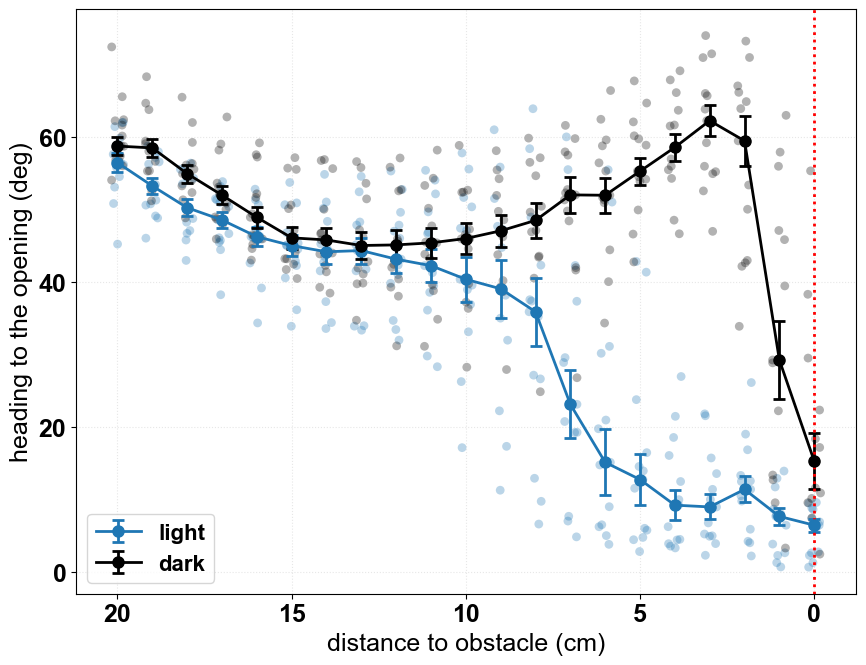

In [ ]:
# Set font parameters to match previous plots
font = {'family': 'arial',
        'size': 18}
plt.rc('font', **font)

xnew = np.arange(0, 21, 1)
xnew = np.flip(xnew)
fig, ax = plt.subplots(layout='tight', figsize=(9,7))

ax.invert_xaxis()
data = pd.concat([long])
data = drop_nans_in_columns(data, 'obstacle_ind')

# Storage for data
light_medians = []
dark_medians = []
light_scatter = []  # For individual animal points
dark_scatter = []   # For individual animal points

for task, task_df in data.groupby(['task']):
    # Process each animal
    for animal, animal_df in task_df.groupby(['animal']):
        angle_array = np.empty([animal_df.shape[0], len(xnew)])
        angle_array[:] = np.nan
        
        for i, row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            
            if sum(y) != 0:
                interpolater = interp1d(x1, y1, bounds_error=False)
                angle_array[i] = interpolater(xnew)
        
        animal_median = np.nanmedian(angle_array, axis=0)
        
        # Add jitter to x positions
        x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
        
        if task == 'oa':
            light_medians.append(animal_median)
            light_scatter.append((x_jittered, animal_median))
        else:
            dark_medians.append(animal_median)
            dark_scatter.append((x_jittered, animal_median))

# Calculate population statistics
light_medians = np.array(light_medians)
dark_medians = np.array(dark_medians)

light_angle_median = np.nanmedian(light_medians, axis=0)
dark_angle_median = np.nanmedian(dark_medians, axis=0)

# Calculate standard error instead of standard deviation
light_sem = np.nanstd(light_medians, axis=0) / np.sqrt(np.sum(~np.isnan(light_medians), axis=0))
dark_sem = np.nanstd(dark_medians, axis=0) / np.sqrt(np.sum(~np.isnan(dark_medians), axis=0))

# Plot individual points first (so they're behind)
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with SEM error bars
ax.errorbar(xnew, light_angle_median, yerr=light_sem, 
           fmt='-', color='tab:blue', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_angle_median, yerr=dark_sem, 
           fmt='-', color='black', linewidth=2, 
           marker='o', markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting to match previous plots
ax.set_xticks([20,15,10,5,0])
ax.set_yticks([0,20,40,60])
ax.set_ylabel('heading to the opening (deg)', fontsize=18)
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)
ax.axvline(0, color='r', ls=':', linewidth=2)

# Legend with matching style
ax.legend(loc='lower left', fontsize=16, framealpha=0.8)

# Grid lines for readability
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

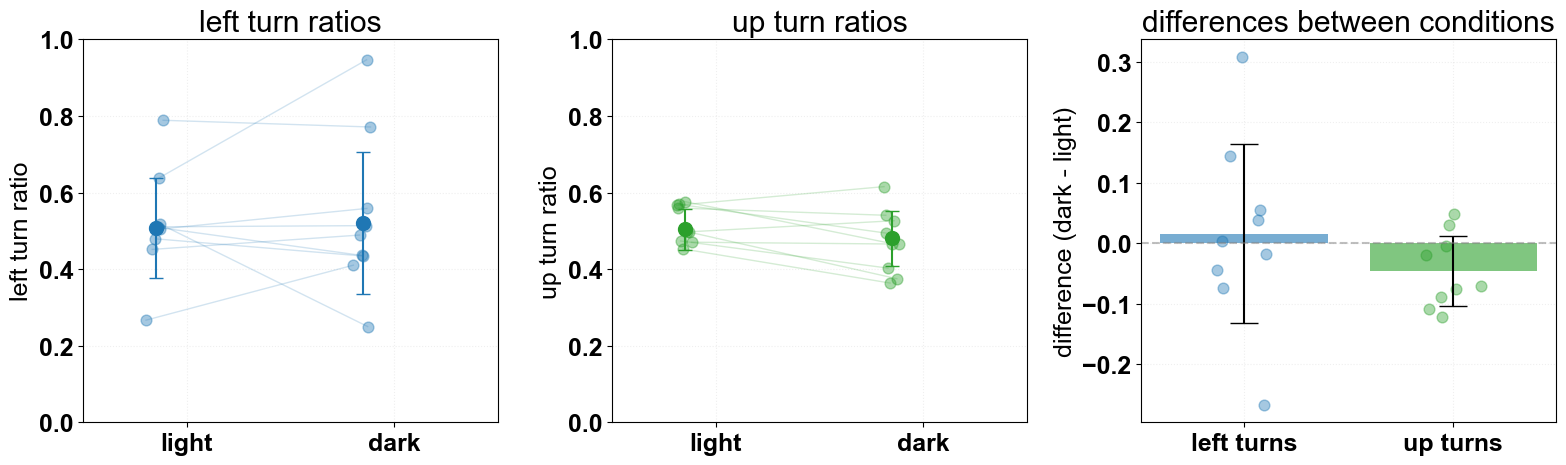

In [69]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# --- data preparation ---
light_data = long[long.task == 'oa']
dark_data = long[long.task == 'oadark']

# left/right ratios (only keeping left)
def calculate_lr_ratios(df):
    grouped = df.groupby(['animal', 'turn_direction_left_right']).size().unstack(fill_value=0)
    grouped['left_ratio'] = grouped['left'] / (grouped['left'] + grouped['right'])
    return grouped

# up/down ratios (only keeping up)
def calculate_ud_ratios(df):
    grouped = df.groupby(['animal', 'turn_direction']).size().unstack(fill_value=0)
    grouped['up_ratio'] = grouped['up'] / (grouped['up'] + grouped['down'])
    return grouped

light_lr = calculate_lr_ratios(light_data)
dark_lr = calculate_lr_ratios(dark_data)
light_ud = calculate_ud_ratios(light_data)
dark_ud = calculate_ud_ratios(dark_data)

common_animals = light_lr.index.intersection(dark_lr.index)

# --- plot 1: left turn ratios ---
x_positions = [0.85, 1.85]  # light and dark positions

for animal in common_animals:
    jitter = np.random.uniform(-0.05, 0.05)
    
    ax1.plot([x_positions[0]+jitter, x_positions[1]+jitter],
            [light_lr.loc[animal, 'left_ratio'], dark_lr.loc[animal, 'left_ratio']],
            color='tab:blue', alpha=0.2, linewidth=1)
    
    ax1.scatter(x_positions[0]+jitter, light_lr.loc[animal, 'left_ratio'],
               color='tab:blue', alpha=0.4, s=60, label='left' if animal == common_animals[0] else "")
    ax1.scatter(x_positions[1]+jitter, dark_lr.loc[animal, 'left_ratio'],
               color='tab:blue', alpha=0.4, s=60)

ax1.errorbar(x_positions[0], light_lr['left_ratio'].mean(), yerr=light_lr['left_ratio'].std(),
            fmt='o', color='tab:blue', markersize=10, capsize=5)
ax1.errorbar(x_positions[1], dark_lr['left_ratio'].mean(), yerr=dark_lr['left_ratio'].std(),
            fmt='o', color='tab:blue', markersize=10, capsize=5)

ax1.set_xticks([1, 2], ['light', 'dark'])
ax1.set_xlim(0.5, 2.5)
ax1.set_ylabel('left turn ratio')
ax1.set_ylim(0, 1)

ax1.grid(True, linestyle=':', alpha=0.2)
ax1.set_title('left turn ratios')

# --- plot 2: up turn ratios ---
for animal in common_animals:
    jitter = np.random.uniform(-0.05, 0.05)
    
    ax2.plot([x_positions[0]+jitter, x_positions[1]+jitter],
            [light_ud.loc[animal, 'up_ratio'], dark_ud.loc[animal, 'up_ratio']],
            color='tab:green', alpha=0.2, linewidth=1)
    
    ax2.scatter(x_positions[0]+jitter, light_ud.loc[animal, 'up_ratio'],
               color='tab:green', alpha=0.4, s=60, label='up' if animal == common_animals[0] else "")
    ax2.scatter(x_positions[1]+jitter, dark_ud.loc[animal, 'up_ratio'],
               color='tab:green', alpha=0.4, s=60)

ax2.errorbar(x_positions[0], light_ud['up_ratio'].mean(), yerr=light_ud['up_ratio'].std(),
            fmt='o', color='tab:green', markersize=10, capsize=5)
ax2.errorbar(x_positions[1], dark_ud['up_ratio'].mean(), yerr=dark_ud['up_ratio'].std(),
            fmt='o', color='tab:green', markersize=10, capsize=5)

ax2.set_xticks([1, 2], ['light', 'dark'])
ax2.set_xlim(0.5, 2.5)
ax2.set_ylabel('up turn ratio')
ax2.set_ylim(0, 1)

ax2.grid(True, linestyle=':', alpha=0.2)
ax2.set_title('up turn ratios')

# --- plot 3: raw differences (not absolute) ---
lr_diffs = [dark_lr.loc[a, 'left_ratio'] - light_lr.loc[a, 'left_ratio']
           for a in common_animals]
ud_diffs = [dark_ud.loc[a, 'up_ratio'] - light_ud.loc[a, 'up_ratio']
           for a in common_animals]

# Plot bars showing mean differences
ax3.bar([0, 1], [np.mean(lr_diffs), np.mean(ud_diffs)],
       color=['tab:blue', 'tab:green'], alpha=0.6,
       yerr=[np.std(lr_diffs), np.std(ud_diffs)], capsize=10)

# Add individual points with jitter
jitter_width = 0.15
for i, diffs in enumerate([lr_diffs, ud_diffs]):
    jitter = np.random.uniform(-jitter_width, jitter_width, size=len(diffs))
    ax3.scatter(np.full(len(diffs), i) + jitter, diffs,
               color=['tab:blue', 'tab:green'][i], alpha=0.4, s=60)

# Add horizontal line at zero for reference
ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)

ax3.set_xticks([0, 1], ['left turns', 'up turns'])
ax3.set_ylabel('difference (dark - light)')
ax3.grid(True, linestyle=':', alpha=0.2)
ax3.set_title('differences between conditions')

plt.tight_layout()
plt.show()

In [106]:
light_data.animal.unique()

array(['G8CK1RT', 'G8CK1LT', 'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT',
       'G8CKTT', 'G8CKRN', 'G8CKLN'], dtype=object)

In [107]:
dark_data.animal.unique()

array(['G8CK1RT', 'G8CK1LT', 'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT',
       'G8CKTT', 'G8CKRN', 'G8CKLN'], dtype=object)

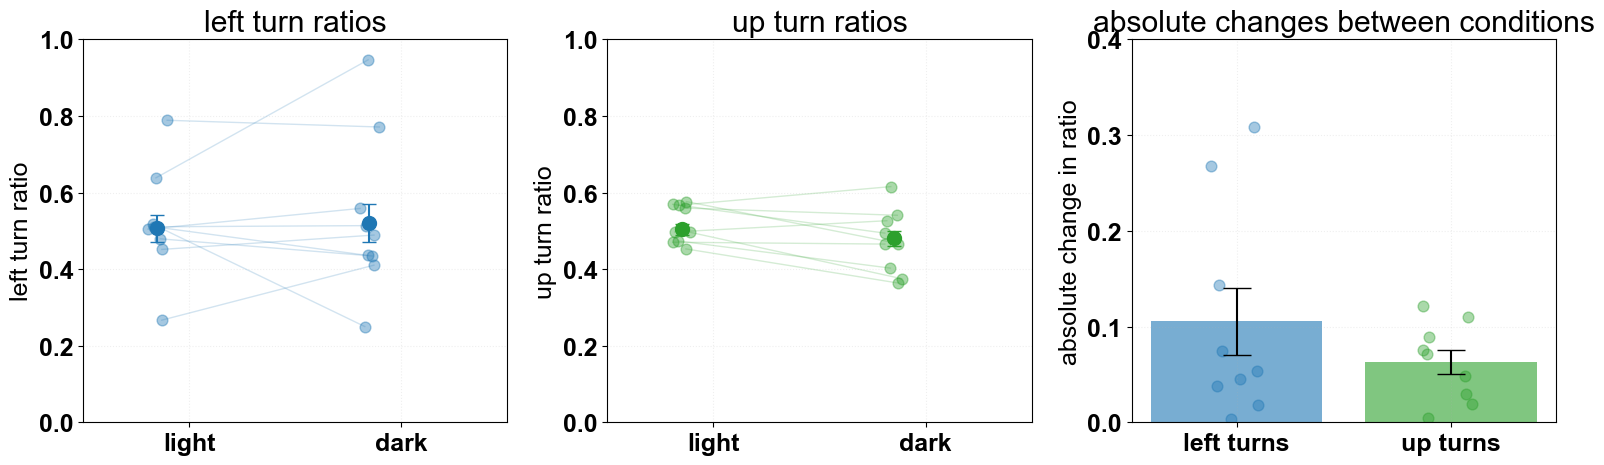

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# --- data preparation ---
light_data = long[long.task == 'oa']

dark_data = long[long.task == 'oadark']

# left/right ratios (only keeping left)
def calculate_lr_ratios(df):
    grouped = df.groupby(['animal', 'turn_direction_left_right']).size().unstack(fill_value=0)
    grouped['left_ratio'] = grouped['left'] / (grouped['left'] + grouped['right'])
    return grouped

# up/down ratios (only keeping up)
def calculate_ud_ratios(df):
    grouped = df.groupby(['animal', 'turn_direction']).size().unstack(fill_value=0)
    grouped['up_ratio'] = grouped['up'] / (grouped['up'] + grouped['down'])
    return grouped

light_lr = calculate_lr_ratios(light_data)
dark_lr = calculate_lr_ratios(dark_data)
light_ud = calculate_ud_ratios(light_data)
dark_ud = calculate_ud_ratios(dark_data)

common_animals = light_lr.index.intersection(dark_lr.index)

# Function to calculate SEM
def sem(data):
    return np.std(data) / np.sqrt(len(data))

# --- plot 1: left turn ratios ---
# adjusted x positions to center better
x_positions = [0.85, 1.85]  # light and dark positions

for animal in common_animals:
    jitter = np.random.uniform(-0.05, 0.05)
    
    # connect points between conditions
    ax1.plot([x_positions[0]+jitter, x_positions[1]+jitter],
            [light_lr.loc[animal, 'left_ratio'], dark_lr.loc[animal, 'left_ratio']],
            color='tab:blue', alpha=0.2, linewidth=1)
    
    # plot individual points
    ax1.scatter(x_positions[0]+jitter, light_lr.loc[animal, 'left_ratio'],
               color='tab:blue', alpha=0.4, s=60, label='left' if animal == common_animals[0] else "")
    ax1.scatter(x_positions[1]+jitter, dark_lr.loc[animal, 'left_ratio'],
               color='tab:blue', alpha=0.4, s=60)

# plot means and SEM error bars
ax1.errorbar(x_positions[0], light_lr['left_ratio'].mean(), yerr=sem(light_lr['left_ratio']),
            fmt='o', color='tab:blue', markersize=10, capsize=5)
ax1.errorbar(x_positions[1], dark_lr['left_ratio'].mean(), yerr=sem(dark_lr['left_ratio']),
            fmt='o', color='tab:blue', markersize=10, capsize=5)

ax1.set_xticks([1, 2], ['light', 'dark'])
ax1.set_xlim(0.5, 2.5)  # added padding to center the data
ax1.set_ylabel('left turn ratio')
ax1.set_ylim(0, 1)

ax1.grid(True, linestyle=':', alpha=0.2)
ax1.set_title('left turn ratios')

# --- plot 2: up turn ratios ---
for animal in common_animals:
    jitter = np.random.uniform(-0.05, 0.05)
    
    # connect points between conditions
    ax2.plot([x_positions[0]+jitter, x_positions[1]+jitter],
            [light_ud.loc[animal, 'up_ratio'], dark_ud.loc[animal, 'up_ratio']],
            color='tab:green', alpha=0.2, linewidth=1)
    
    # plot individual points
    ax2.scatter(x_positions[0]+jitter, light_ud.loc[animal, 'up_ratio'],
               color='tab:green', alpha=0.4, s=60, label='up' if animal == common_animals[0] else "")
    ax2.scatter(x_positions[1]+jitter, dark_ud.loc[animal, 'up_ratio'],
               color='tab:green', alpha=0.4, s=60)

# plot means and SEM error bars
ax2.errorbar(x_positions[0], light_ud['up_ratio'].mean(), yerr=sem(light_ud['up_ratio']),
            fmt='o', color='tab:green', markersize=10, capsize=5)
ax2.errorbar(x_positions[1], dark_ud['up_ratio'].mean(), yerr=sem(dark_ud['up_ratio']),
            fmt='o', color='tab:green', markersize=10, capsize=5)

ax2.set_xticks([1, 2], ['light', 'dark'])
ax2.set_xlim(0.5, 2.5)  # added padding to center the data
ax2.set_ylabel('up turn ratio')
ax2.set_ylim(0, 1)

ax2.grid(True, linestyle=':', alpha=0.2)
ax2.set_title('up turn ratios')

# --- plot 3: absolute changes ---
lr_changes = [abs(dark_lr.loc[a, 'left_ratio'] - light_lr.loc[a, 'left_ratio']) 
             for a in common_animals]
ud_changes = [abs(dark_ud.loc[a, 'up_ratio'] - light_ud.loc[a, 'up_ratio']) 
             for a in common_animals]

ax3.bar([0, 1], [np.mean(lr_changes), np.mean(ud_changes)],
       color=['tab:blue', 'tab:green'], alpha=0.6,
       yerr=[sem(lr_changes), sem(ud_changes)], capsize=10)

# add individual points
jitter_width = 0.15
for i, changes in enumerate([lr_changes, ud_changes]):
    jitter = np.random.uniform(-jitter_width, jitter_width, size=len(changes))
    ax3.scatter(np.full(len(changes), i) + jitter, changes,
               color=['tab:blue', 'tab:green'][i], alpha=0.4, s=60)

ax3.set_xticks([0, 1], ['left turns', 'up turns'])
ax3.set_ylabel('absolute change in ratio')
ax3.set_ylim(0, 0.4)
ax3.grid(True, linestyle=':', alpha=0.2)
ax3.set_title('absolute changes between conditions')

plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'long towards first occurance')

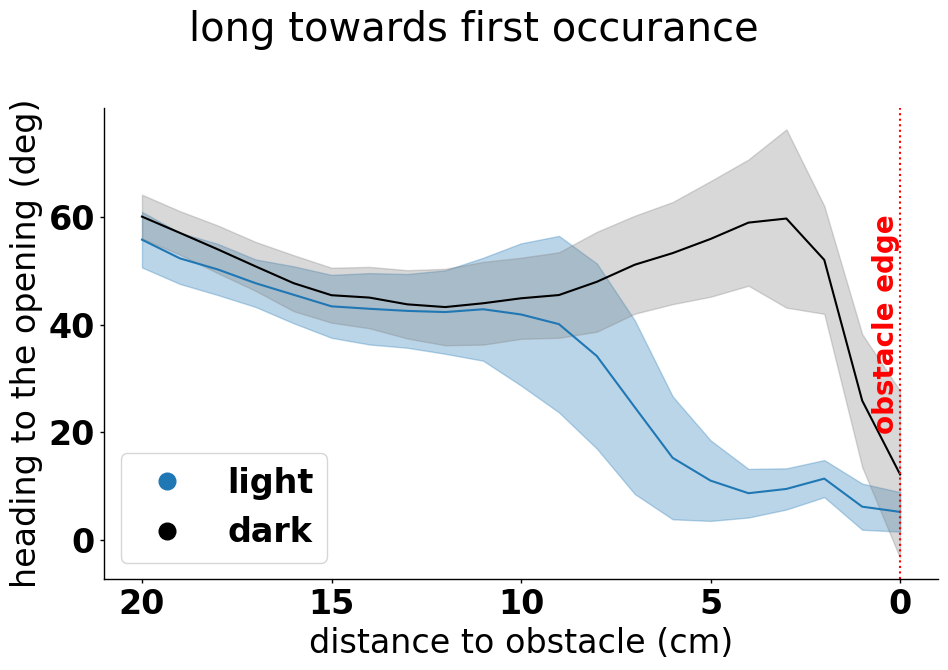

In [164]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

#for i in list(range(light_medians.shape[1])):
#    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
#    light_sd.append(sd)
#light_sd = np.asarray(light_sd)
#
#for i in list(range(dark_medians.shape[1])):
#    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
#    dark_sd.append(sd)
#dark_sd = np.asarray(dark_sd)
#
            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long towards first occurance')

Text(0.5, 0.98, 'long (last occurance)')

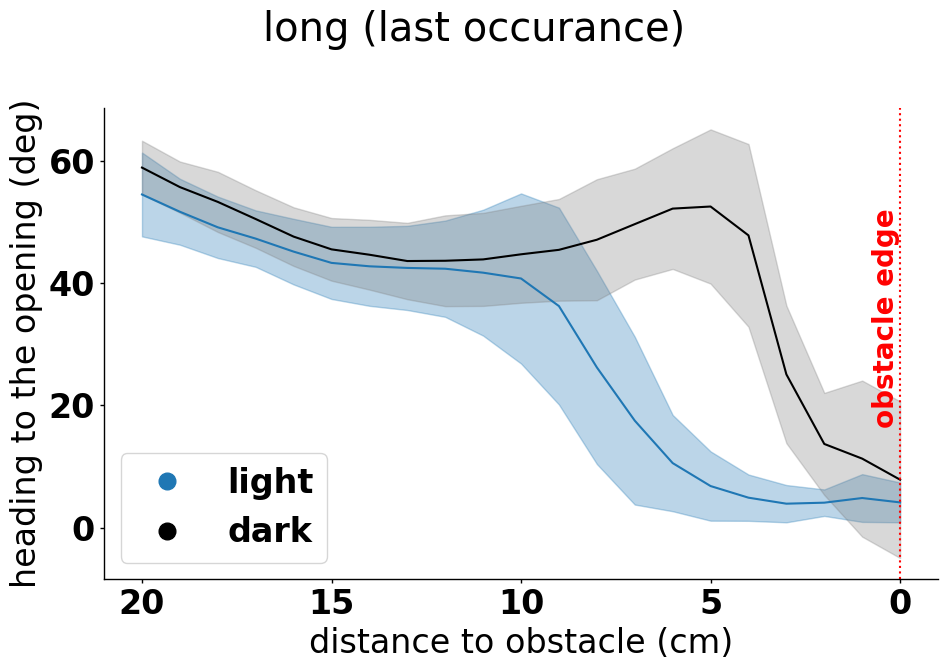

In [130]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[last_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[last_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[last_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[last_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

#for i in list(range(light_medians.shape[1])):
#    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
#    light_sd.append(sd)
#light_sd = np.asarray(light_sd)
#
#for i in list(range(dark_medians.shape[1])):
#    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
#    dark_sd.append(sd)
#dark_sd = np.asarray(dark_sd)
#
            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long (last occurance)')

In [55]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([long_nostart])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)



Text(0.5, 0.98, 'long')

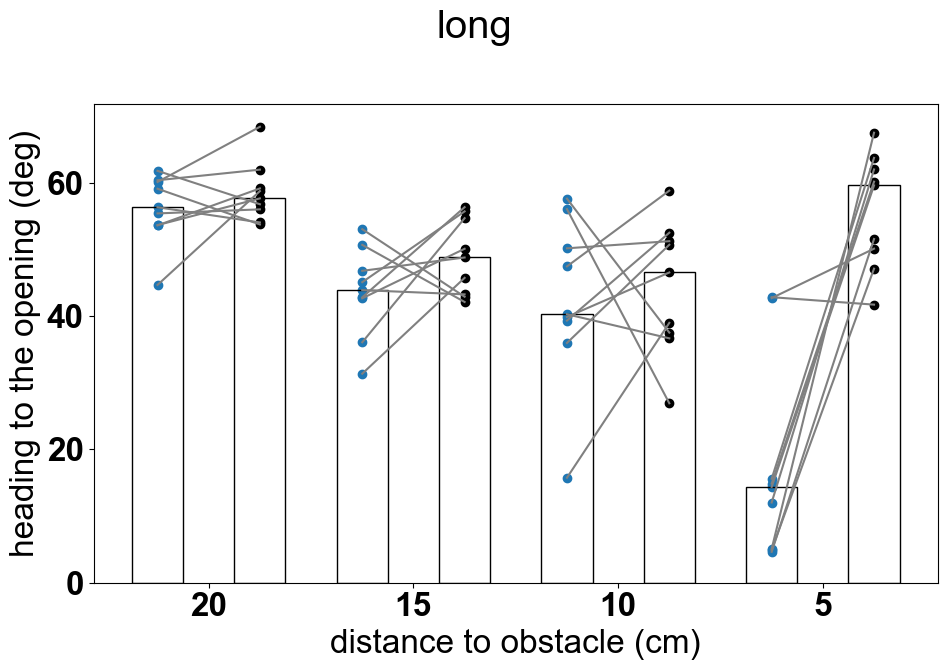

In [56]:
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('long')

Text(0.5, 0.98, 'long')

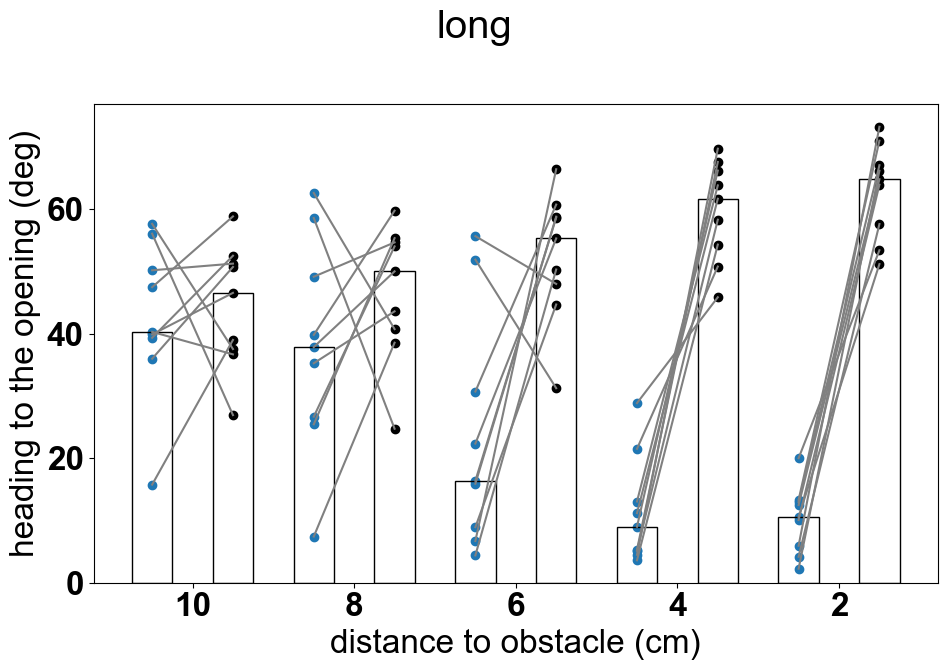

In [57]:
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,12],dark_medians[:,12]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,14],dark_medians[:,14]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,16],dark_medians[:,16]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.bar(8,np.nanmedian(light_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
ax.bar(9,np.nanmedian(dark_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],8),np.full(dark_medians.shape[0],9)),(light_medians[:,18],dark_medians[:,18]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('long')


In [58]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat[0],stat[1],i)
    #print(stat[1])


1.072664326998051 0.31574510439066894 20
3.6190043473294495 0.07527977836615271 19
2.6792402643747075 0.12117911399135439 18
4.654745359248981 0.04651664697724945 17
3.574613318442483 0.0769200785592793 16
3.1981391740967813 0.09267244516714279 15
1.7794501137801757 0.2008948863312135 14
0.7719340127233513 0.39262299620481944 13
0.4289048033205375 0.521831503795422 12
0.25127770653633347 0.6230032265942581 11
0.12960003077774027 0.7235550277690759 10
0.5337304948739334 0.47560528858619555 9
1.6401530985913304 0.21855852356489638 8
7.5593496746109565 0.014250839876937692 7
16.18387056838499 0.0009834902823785358 6
44.43245325627963 5.42435930463749e-06 5
149.88065464815588 1.5387739619126669e-09 4
363.1702692072293 2.0122825202749988e-12 3
289.8865389120163 1.1269869743174318e-11 2
14.162939437407545 0.0016991320636004425 1
8.786506430061026 0.009136333711891794 0


short trials

Text(0.5, 0.98, 'short')

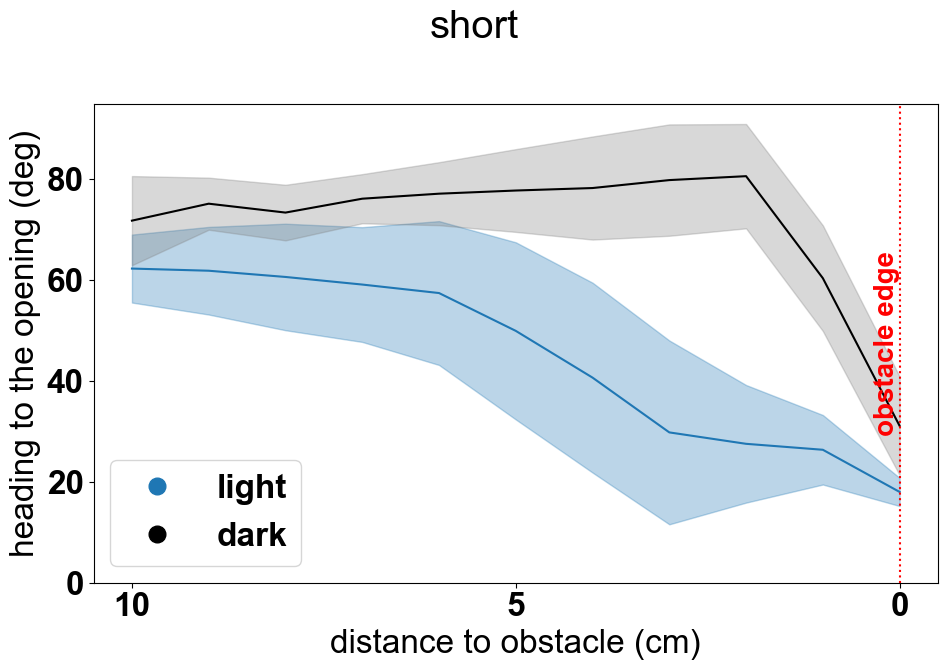

In [64]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short')

Text(0.5, 0.98, 'long towards')

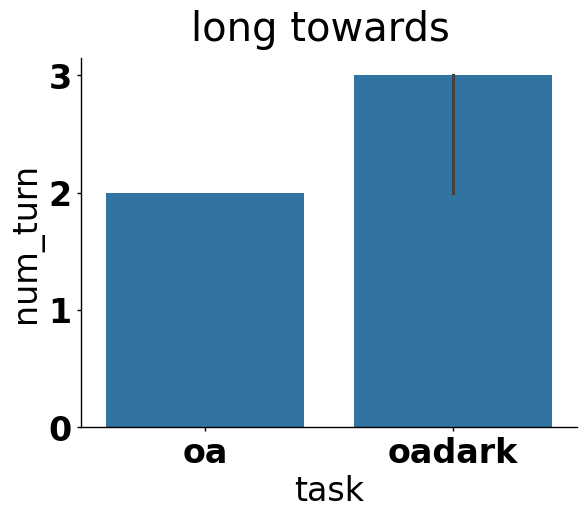

In [316]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'num_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

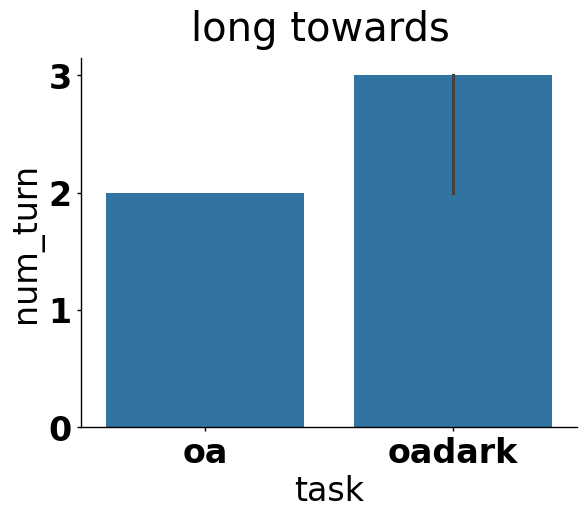

In [319]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data, x = 'task', y = 'num_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

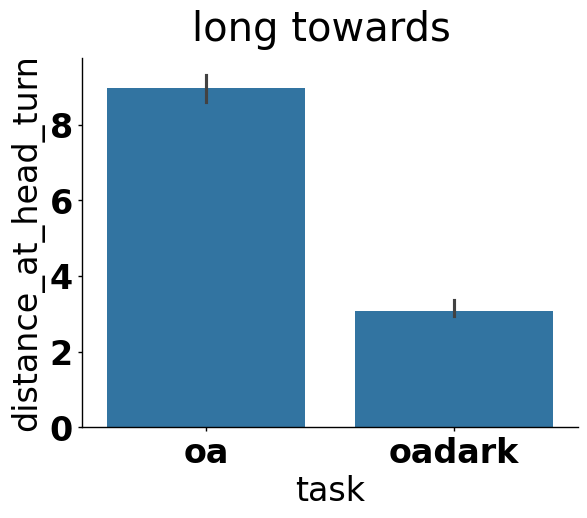

In [318]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data, x = 'task', y = 'distance_at_head_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'short towards')

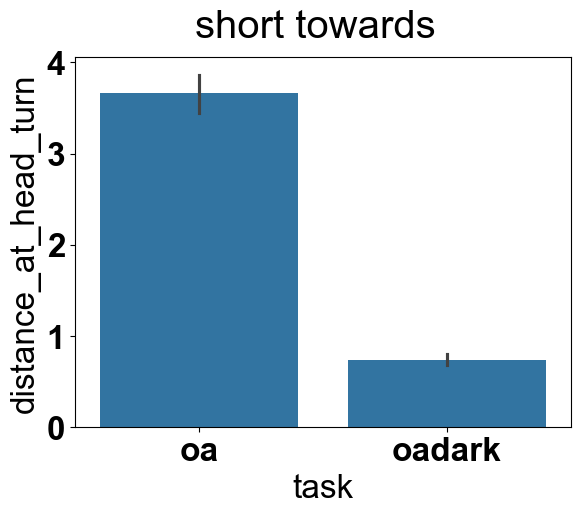

In [83]:
data = short_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data[data.distance_at_head_turn <=10], x = 'task', y = 'distance_at_head_turn',estimator='median')
plt.suptitle('short towards')

<AxesSubplot: xlabel='task', ylabel='distance_at_head_turn'>

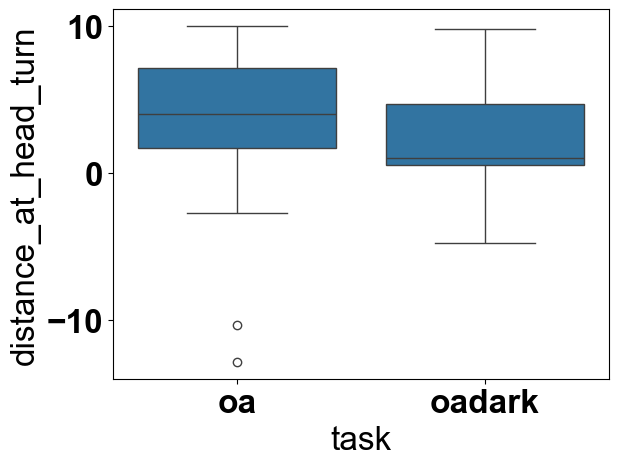

In [70]:
sns.boxplot(data = data[data.distance_at_head_turn <=10], x = 'task', y = 'distance_at_head_turn')

Text(0.5, 0.98, 'short first occurance towards')

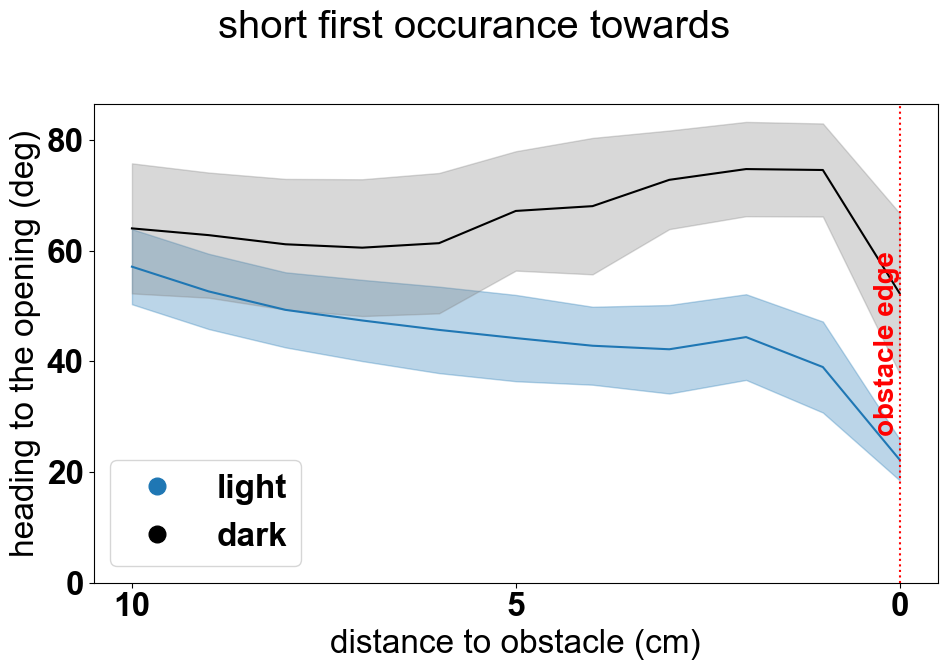

In [141]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.intial_distance > 10]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short first occurance towards')

Text(0.5, 0.98, 'short first occurance towards')

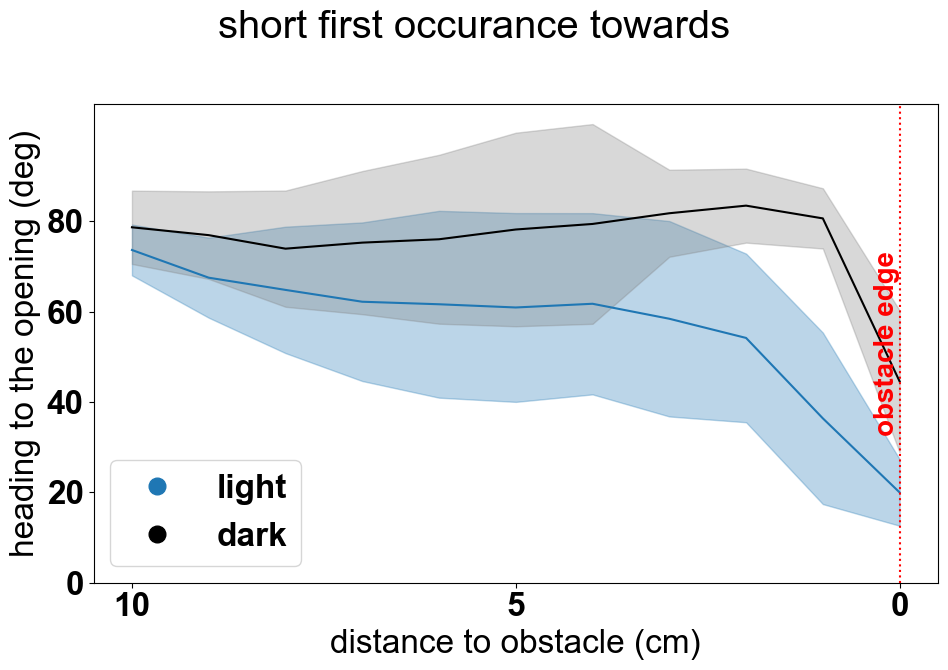

In [139]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.intial_distance == 10]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short first occurance towards')

Text(0.5, 0.98, 'short')

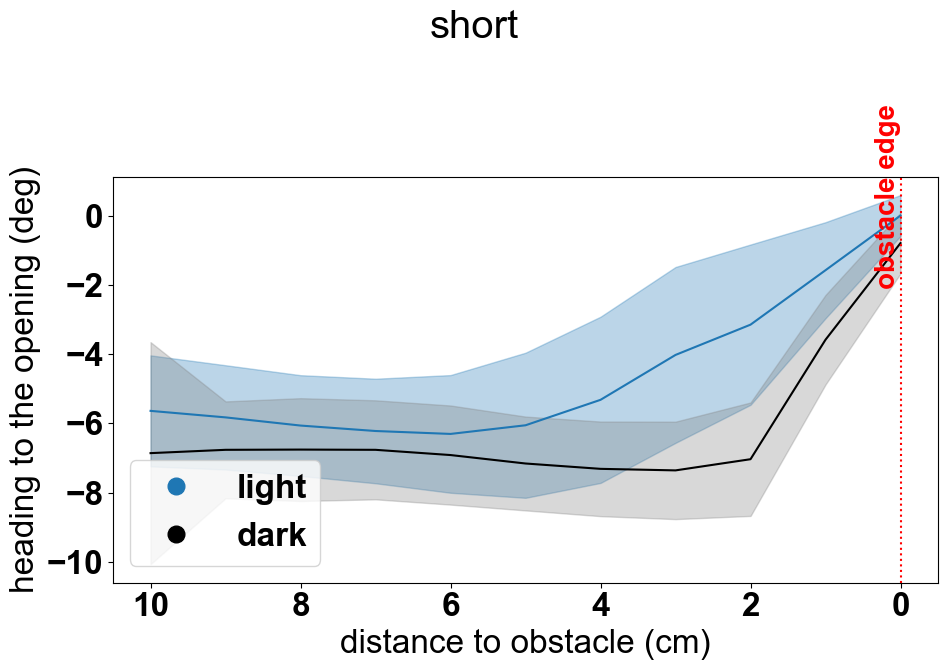

In [217]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
#ax.set_xticks([10,5,0])    
#ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short')

Text(0.5, 0.98, 'short')

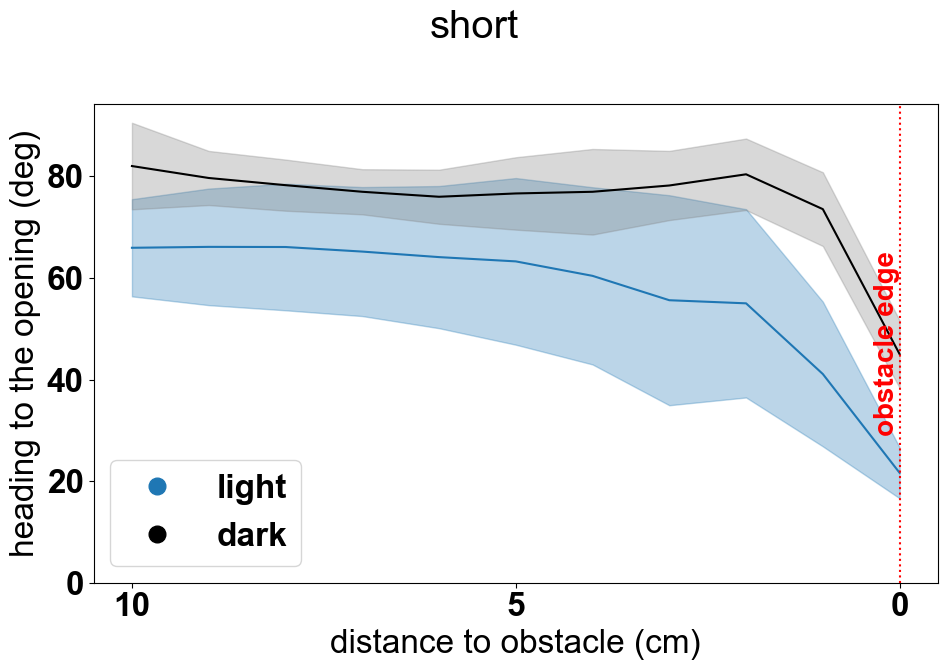

In [87]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short')

In [85]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([short_nostart])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)



In [105]:
dark_medians[:,0]

array([86.72105703, 81.40806431, 60.13367837,         nan, 75.74459051,
       79.04748755, 80.43256672, 74.06748146, 63.06008183])

In [104]:
light_medians[:,0]

array([68.91220414, 66.45881216, 77.08208194, 66.3573819 , 56.66416528,
       62.8892944 , 65.700179  , 62.73198653, 50.29917828])

In [88]:
np.full(light_medians.shape[0],0)

array([0, 0, 0, 0, 0, 0, 0, 0, 0])

In [92]:
np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0]), array([1, 1, 1, 1, 1, 1, 1, 1, 1]))

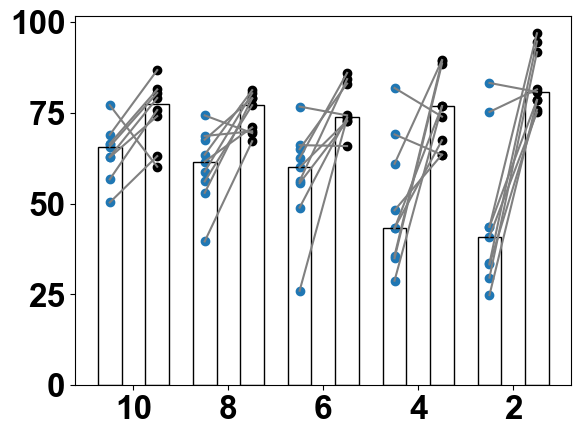

In [22]:
fig,ax = plt.subplots()
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,2],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,2]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,2],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,2]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,2],dark_medians[:,2]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,4],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,4]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,4],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,4]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,4],dark_medians[:,4]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,6],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,6]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,6],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,6]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,6],dark_medians[:,6]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,8],color = 'tab:blue')
ax.bar(8,np.nanmedian(light_medians[:,8]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,8],color = 'black')
ax.bar(9,np.nanmedian(dark_medians[:,8]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],8),np.full(dark_medians.shape[0],9)),(light_medians[:,8],dark_medians[:,8]),color = 'grey')

In [24]:
import numpy.ma as ma
f_oneway(dark_medians[:,0][~ma.masked_invalid(dark_medians[:,0]).mask],light_medians[:,0])

F_onewayResult(statistic=7.308192949781332, pvalue=0.0163480265944727)

In [23]:
import numpy.ma as ma
dist_list = np.arange(0, 11, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat[0],stat[1],i)


nan nan 10
15.954115764605206 0.0010445545285888837 9
14.277507046399062 0.0016455211131190888 8
17.75617205469746 0.0006591903096963949 7
13.002150402516767 0.0023697467200423706 6
11.989237469102838 0.003207459166313174 5
15.591492232080276 0.0011498514646530122 4
19.04766470976888 0.00048161322088835056 3
27.41556927859326 8.157024863419057e-05 2
71.80958624271587 2.607153428456126e-07 1
149.36744798325975 1.5776253858279454e-09 0


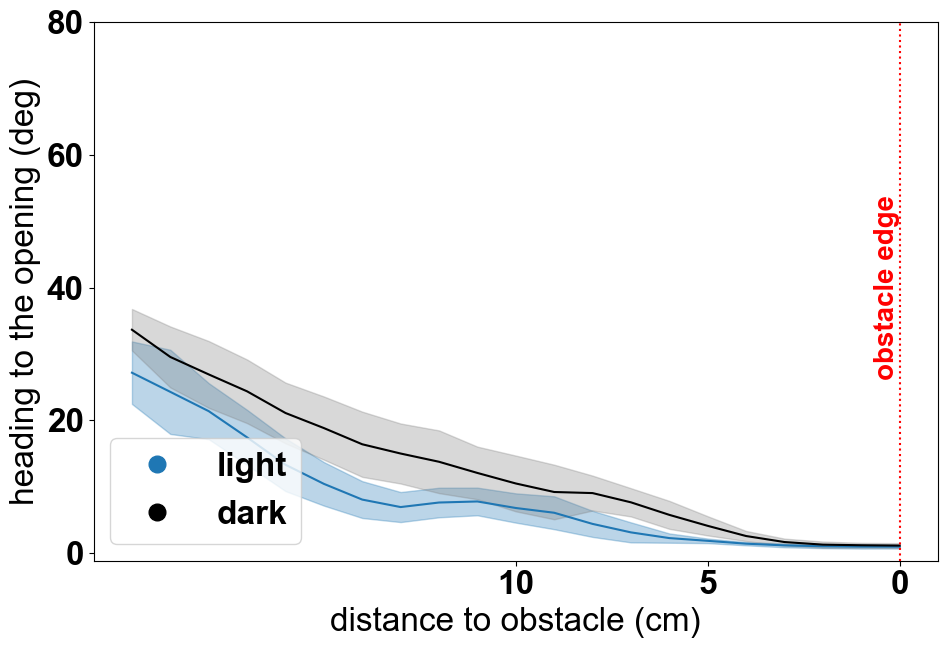

In [44]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([middle_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
#data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN','G8CKLT']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)

In [45]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([middle_nostart])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
#data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        print(animal,task)
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(light_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(dark_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

G8CK1LN oa
G8CK1LN oadark
G8CK1LT oa
G8CK1LT oadark
G8CK1RT oa
G8CK1RT oadark
G8CK1TT oa
G8CK1TT oadark
G8CKLN oa
G8CKLN oadark
G8CKLT oa
G8CKLT oadark
G8CKRN oa
G8CKRN oadark
G8CKRT oa
G8CKRT oadark
G8CKTT oa
G8CKTT oadark


In [43]:
data

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_at_head_turn_2_index,distance_at_head_turn_2_indexs,angle_at_head_turn_2,num_turn,towards_num_turn,away_num_turn,right_num_turn,right_turns_distances,left_num_turn,left_turns_distances
2725,2725,50372.705280,50376.822080,"[50372.717043, 50372.735552, 50372.75054, 5037...","[3462, 3463, 3464, 3465, 3466, 3467, 3468, 346...","[117.01360321044922, 116.47345733642578, 115.7...","[274.8700866699219, 273.04595947265625, 272.20...","[124.90813446044922, 123.60502624511719, 122.4...","[274.9167785644531, 274.6429443359375, 274.652...","[124.64678192138672, 123.75786590576172, 123.5...",...,50.0,"[2, 28, 43, 50]",122.048796,4.0,2.0,2.0,2.0,"[9.181359965756421, 1.491899425085947]",2.0,"[0.7586340860166665, 1.373382913282633]"
2726,2726,50376.822080,50379.337318,"[50376.835302, 50376.85198, 50376.868544, 5037...","[[3709, 3710, 3711, 3712, 3713, 3714, 3715, 37...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[689.8196411132812, 690.0974731445312, 690.154...","[260.5218200683594, 260.9630432128906, 261.623...","[681.4044189453125, 681.662841796875, 682.2274...",...,45.0,"[33, 45]",11.453429,2.0,3.0,2.0,1.0,[3.8642608717014326],1.0,[2.7055099955799076]
2727,2727,50379.337318,50381.815667,"[50379.353676, 50379.369472, 50379.386163, 503...","[3860, 3861, 3862, 3863, 3864, 3865, 3866, 386...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[123.86229705810547, 123.18112182617188, 122.9...","[277.52691650390625, 277.44525146484375, 277.5...","[128.97134399414062, 128.38442993164062, 128.3...",...,2.0,[2],13.616186,1.0,0.0,NaN,0.0,[],1.0,[8.974062457433714]
2736,2736,50419.178355,50421.722150,"[50419.183091, 50419.199846, 50419.216614, 504...","[[6249, 6250, 6251, 6252, 6253, 6254, 6255, 62...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[688.37744140625, 688.2561645507812, 688.29699...","[260.0295715332031, 259.51763916015625, 259.84...","[680.450927734375, 680.7147216796875, 680.7387...",...,2.0,"[2, 15]",36.117510,2.0,0.0,NaN,0.0,[],2.0,"[18.784905099176257, 11.408403947068479]"
2737,2737,50421.722150,50424.208614,"[50421.734131, 50421.750835, 50421.768294, 504...","[6402, 6403, 6404, 6405, 6406, 6407, 6408, 640...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[126.54217529296875, 125.79476928710938, 125.6...","[279.0948486328125, 279.1933898925781, 278.219...","[132.26815795898438, 131.5294647216797, 130.71...",...,2.0,[2],27.672843,1.0,0.0,NaN,0.0,[],1.0,[9.521666517390445]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14536,14536,55907.699212,55910.243033,"[55907.699276, 55907.71575, 55907.733376, 5590...","[13713, 13714, 13715, 13716, 13717, 13718, 137...","[90.92820739746094, 90.42640686035156, 89.9016...","[262.5146484375, 262.6229553222656, 261.961486...","[95.67121124267578, 95.19441986083984, 94.7905...","[261.8681335449219, 262.1152648925781, 261.792...","[98.95252227783203, 97.65525817871094, 97.1992...",...,13.0,"[2, 13]",4.918050,2.0,0.0,NaN,0.0,[],2.0,"[17.042384319912472, 9.939674629126293]"
14537,14537,55910.243033,55912.491942,"[55910.249779, 55910.267865, 55910.28334, 5591...","[[13866, 13867, 13868, 13869, 13870, 13871, 13...","[670.7637939453125, 673.1174926757812, 673.373...","[265.2012939453125, 265.2127685546875, 265.635...","[658.1209106445312, 664.5240478515625, 665.381...","[262.3766784667969, 257.009765625, 257.6093444...","[665.65283203125, 666.5121459960938, 666.28002...",...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,[],0.0,[]
14542,14542,55959.485260,55961.705395,"[55959.500416, 55959.517196, 55959.53454, 5595...","[[16820, 16821, 16822, 16823, 16824, 16825, 16...","[674.292724609375, 674.9031982421875, 675.8319...","[262.27545166

In [39]:
animal

'G8CKTT'

In [40]:
dark_array.shape

(6, 21)

In [34]:
light_medians[:,0]

array([51.38429092, 24.88953155, 41.24533467, 28.62193945, 29.14859371,
       39.90924497,         nan, 12.15323294])

In [35]:
dark_medians[:,0]

array([32.90673655, 40.87962659, 44.13525584, 32.31649345, 45.00927875,
               nan, 63.38880761, 46.65386781])

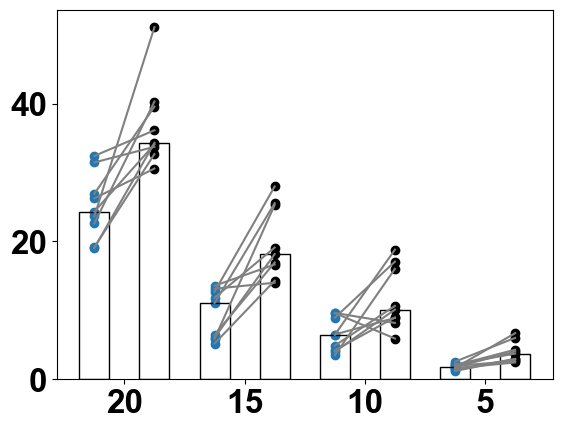

In [46]:
fig,ax = plt.subplots()
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')

In [ ]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long')

Text(0.5, 0.98, 'away')

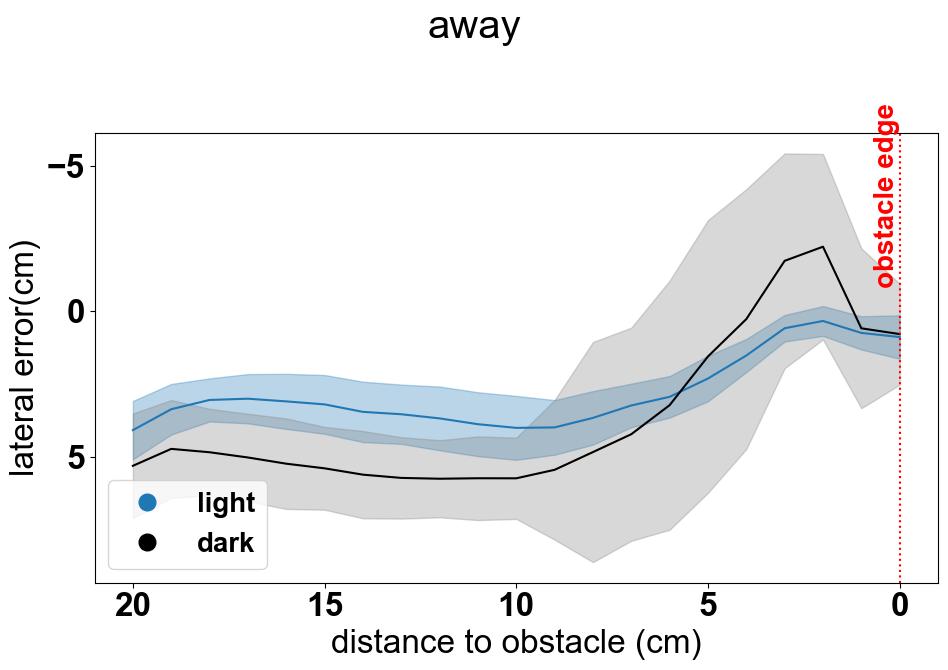

In [59]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'away']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
#ax.set_yticks([-8,-4,0,4]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
fig.suptitle('away')

Text(0.5, 0.98, 'towards')

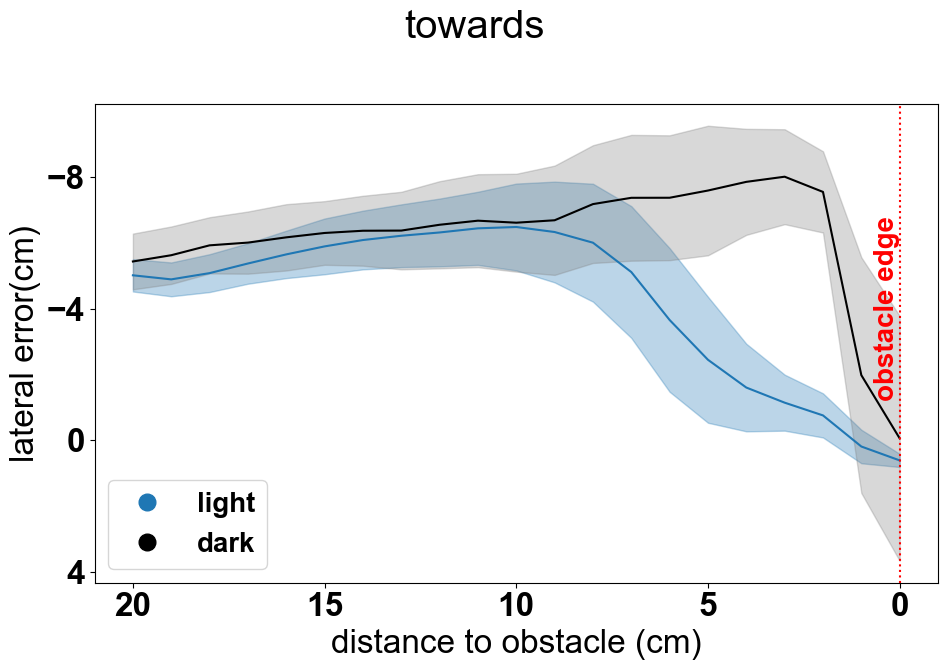

In [57]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([-8,-4,0,4]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
fig.suptitle('towards')

In [18]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([joint])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = drop_nans_in_columns(data,'lateral_error')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

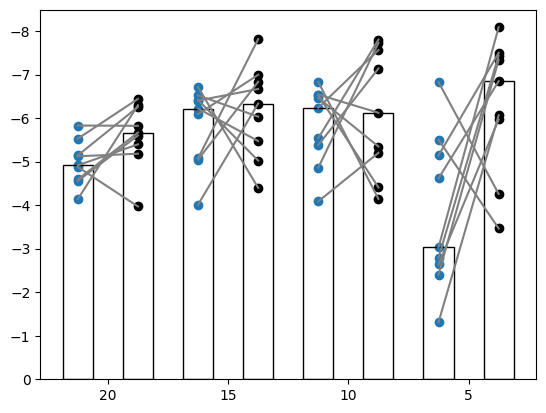

In [21]:
fig,ax = plt.subplots()
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')
ax.invert_yaxis()

Text(0.5, 0.98, 'short')

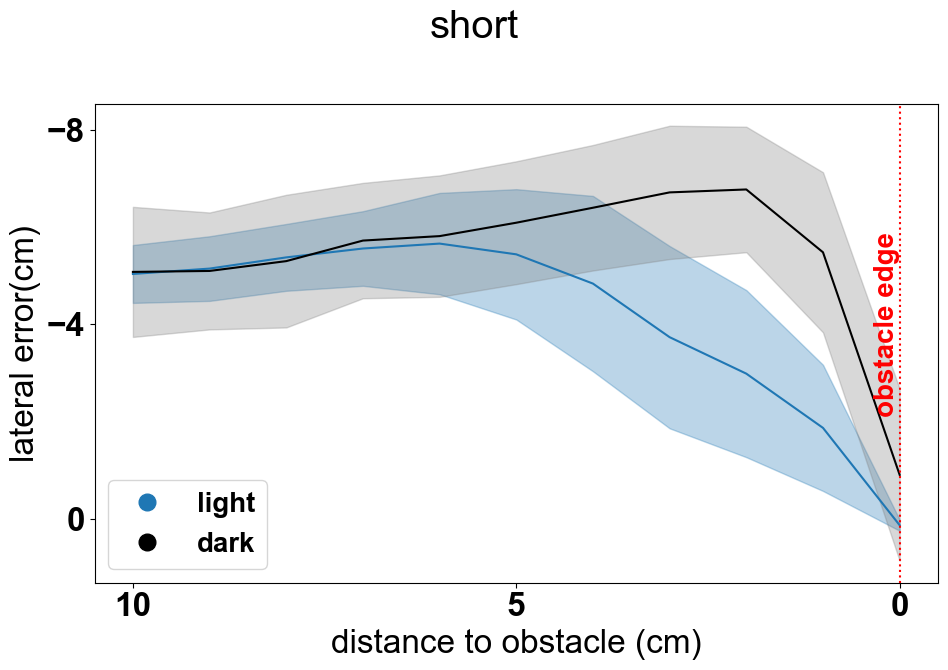

In [94]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        #x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        #y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            #x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
           # y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
fig.suptitle('short')

Text(0.5, 0.98, 'short towards fisrt occurance')

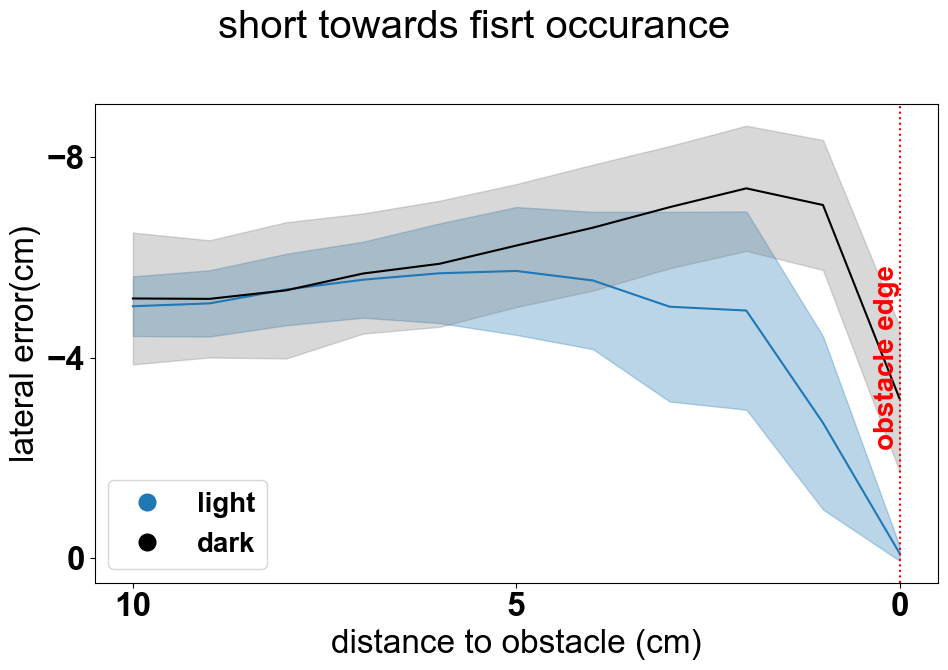

In [91]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
fig.suptitle('short towards fisrt occurance')

Text(0.5, 0.03, 'distance to obstacle (cm)')

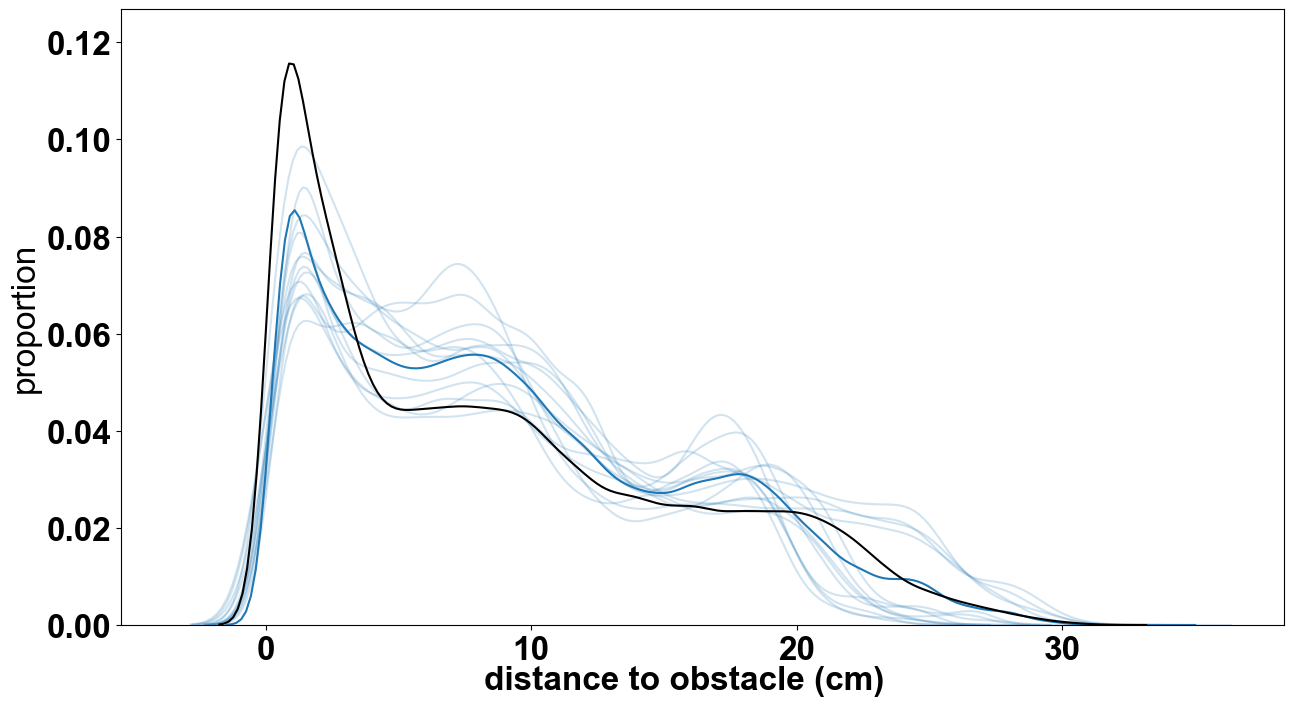

In [33]:
data = joint
fig,ax = plt.subplots(1,1,figsize=(15,8),sharey =True)
light = data[data.task =='oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_list())
light_dist = light_dist[np.where((light_dist>=0))]
 
sns.kdeplot(ax = ax,data = light_dist,color = 'tab:blue')

for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_list())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    sns.kdeplot(ax = ax,data = ani_light_dists,color = 'tab:blue', alpha = .2 )

dark = data[data.task =='oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_list())
dark_dist = dark_dist[np.where((dark_dist>=0))]

sns.kdeplot(ax = ax,data = dark_dist,color = 'black')

for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_list())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    sns.kdeplot(ax = ax,data = ani_dark_dists,color = 'black', alpha = .2,linestyle ='none' )

ax.set_xticks([0,10,20,30])

ax.set_ylabel('proportion')
fig.text(0.5, 0.03, 'distance to obstacle (cm)', ha='center')


In [22]:
f_oneway(dark_medians[:,0],light_medians[:,0])

F_onewayResult(statistic=4.692024419758573, pvalue=0.04574962649947531)

In [23]:
f_oneway(dark_medians[:,5],light_medians[:,5])

F_onewayResult(statistic=0.5360668096445641, pvalue=0.4746565831631724)

In [24]:
f_oneway(dark_medians[:,10],light_medians[:,10])

F_onewayResult(statistic=0.3356692264706663, pvalue=0.5704078998589119)

In [25]:
f_oneway(dark_medians[:,15],light_medians[:,15])

F_onewayResult(statistic=10.107399974528644, pvalue=0.005826677470858147)

In [26]:
f_oneway(dark_medians[:,20],light_medians[:,20])

F_onewayResult(statistic=5.610307320560603, pvalue=0.03078010616718436)

In [7]:
long_nostart.intial_lateral_error.group


8       -2.209042
12       4.971173
17      -6.185573
22       6.595616
24      -6.523490
           ...   
14500    8.429366
14515    8.808606
14523   -7.732743
14535    5.552014
14547    9.117446
Name: intial_lateral_error, Length: 5295, dtype: float64

In [8]:
data = long_nostart[(long_nostart.obstacle_cluster == 1 ) & (long_nostart.turn_to_obstacle == 'towards' )
                    & (long_nostart.odd=='left')]

In [12]:
split_range_into_parts(data.intial_lateral_error.to_numpy().min(),data.intial_lateral_error.to_numpy().max(),4)

[(-17.1751700988669, -8.313858647986105),
 (-8.313858647986105, 0.5474528028946892),
 (0.5474528028946892, 9.408764253775484),
 (9.408764253775484, 18.27007570465628)]

In [28]:
split_range_into_parts(-20,5,4)

[(-20, -13.75), (-13.75, -7.5), (-7.5, -1.25), (-1.25, 5.0)]

<AxesSubplot: >

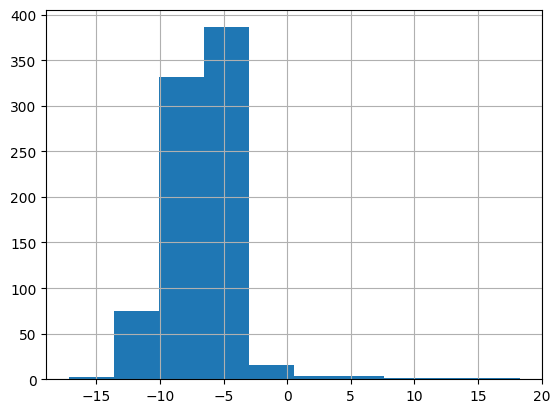

In [17]:
data.intial_lateral_error.hist()

Text(0.5, 1.0, 'towards')

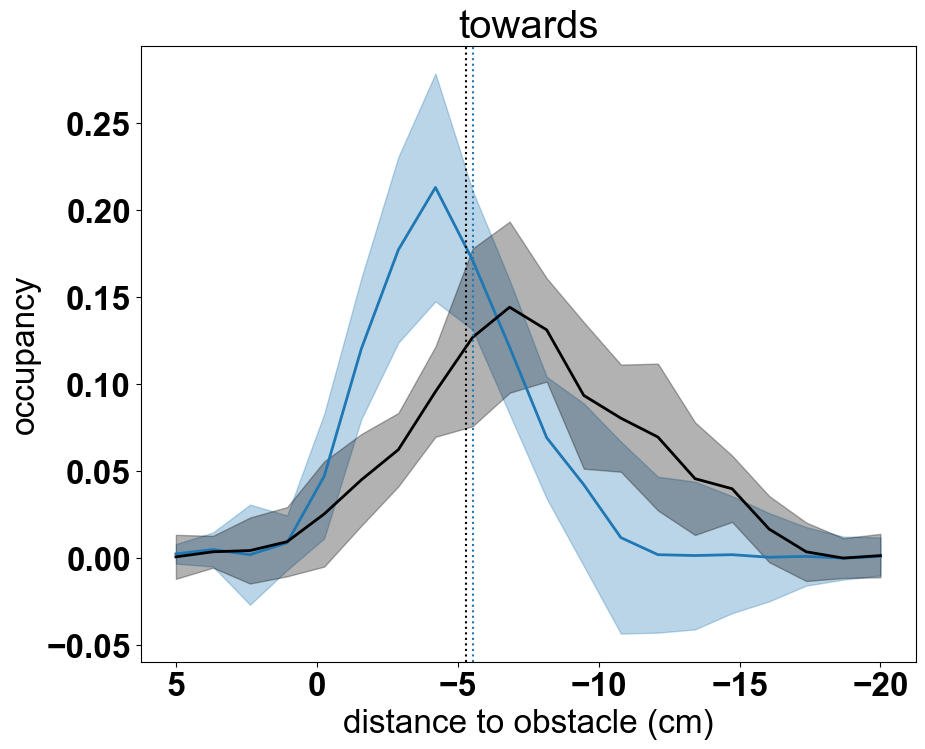

In [106]:
xnew =  np.linspace(-20, 5, 20)
data = pd.concat([short_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.intial_lateral_error.to_numpy())
#light_dist = light_dist[np.where((light_dist>=0))]
light_dist = light_dist[np.where((light_dist<=5))]
light_counts, light_bins = np.histogram(light_dist, bins=20)
light_hist = (light_counts/sum(light_counts))
ax.plot(xnew, light_hist, 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.intial_lateral_error.to_numpy())
    #ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=5))]
    counts, bins = np.histogram(ani_light_dists, bins=20)
    light_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = (dark.intial_lateral_error.to_numpy())
#dark_dist = dark_dist[np.where((dark_dist>=0))]
dark_dist = dark_dist[np.where((dark_dist<=5))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=20)
dark_hist = (dark_counts/sum(dark_counts))
ax.plot(xnew, dark_hist, 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.intial_lateral_error.to_numpy())
    #ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=5))]
    counts, bins = np.histogram(ani_dark_dists, bins=20)
    dark_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.axvline(np.nanmedian(light_dist), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_dist), color='black', ls=':')


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')   

ax.set_ylabel('occupancy')  
ax.set_xlabel('distance to obstacle (cm)')
ax.invert_xaxis()
ax.set_title('towards')

In [46]:
np.nanmean(dark_dist)/np.sqrt(len(dark_dist))

-0.14686824992531913

In [45]:
np.nanmean(light_dist)/np.sqrt(len(light_dist))

-0.12620575754258073

(array([  2.,  28., 118., 207., 310., 374., 218.,  97.,  19.,   6.]),
 array([-15.81887167, -13.73958355, -11.66029544,  -9.58100732,
         -7.50171921,  -5.42243109,  -3.34314298,  -1.26385486,
          0.81543325,   2.89472136,   4.97400948]),
 <BarContainer object of 10 artists>)

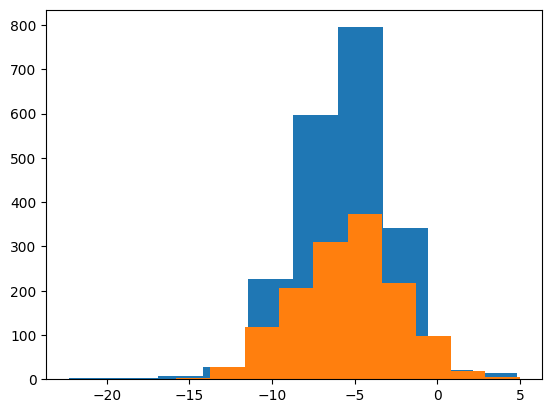

In [39]:
plt.hist(light_dist)
plt.hist(dark_dist)

(array([  6.,  19.,  97., 218., 374., 310., 207., 118.,  28.,   2.]),
 array([-0.00066135, -0.00038489, -0.00010842,  0.00016804,  0.00044451,
         0.00072097,  0.00099744,  0.0012739 ,  0.00155037,  0.00182683,
         0.0021033 ]),
 <BarContainer object of 10 artists>)

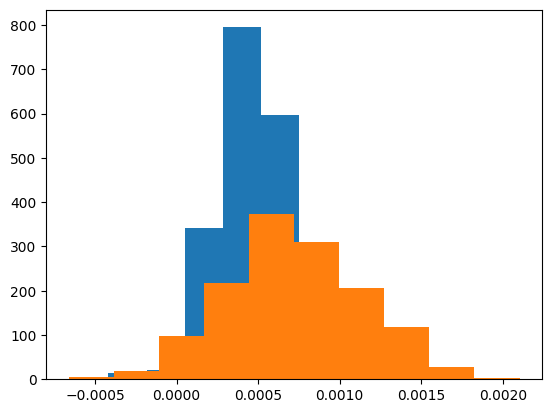

In [38]:
plt.hist(light_dist/sum(light_dist))
plt.hist(dark_dist/sum(dark_dist))

In [37]:
dark_prob

array([[0.01492537, 0.        , 0.        , 0.04477612, 0.02985075,
        0.01492537, 0.13432836, 0.07462687, 0.11940299, 0.13432836,
        0.05970149, 0.05970149, 0.08955224, 0.02985075, 0.08955224,
        0.01492537, 0.02985075, 0.04477612, 0.        , 0.01492537],
       [0.01515152, 0.        , 0.01515152, 0.03030303, 0.04545455,
        0.03030303, 0.09090909, 0.09090909, 0.04545455, 0.15151515,
        0.1969697 , 0.06060606, 0.06060606, 0.03030303, 0.03030303,
        0.03030303, 0.03030303, 0.01515152, 0.01515152, 0.01515152],
       [0.05050505, 0.01010101, 0.04040404, 0.03030303, 0.03030303,
        0.1010101 , 0.04040404, 0.08080808, 0.09090909, 0.12121212,
        0.12121212, 0.1010101 , 0.05050505, 0.04040404, 0.04040404,
        0.01010101, 0.01010101, 0.01010101, 0.        , 0.02020202],
       [0.02298851, 0.01149425, 0.03448276, 0.06896552, 0.05747126,
        0.03448276, 0.18390805, 0.09195402, 0.17241379, 0.08045977,
        0.10344828, 0.03448276, 0.06896552, 0

In [ ]:
labels = ['top','bottom']
top_bottom = split_range_into_parts(np.nanmedian(pd.unique(df.arenaTL_y_cm)),np.nanmedian(pd.unique(df.arenaBL_y_cm)),2)
top_bottom_dict = dict(zip(labels,top_bottom))

In [ ]:
create_color_dict()

In [ ]:
 rgb_values = sns.color_palette(color_pallete, len(color_labels))
        color_map = dict(zip(color_labels, rgb_values))

In [117]:
data.intial_distance

8        25.324790
12       24.951310
17       23.169331
22       24.169727
24       22.953073
           ...    
14500    20.211909
14515    20.775799
14523    18.241314
14535    19.523109
14547    22.701692
Name: intial_distance, Length: 5295, dtype: float64

<AxesSubplot: >

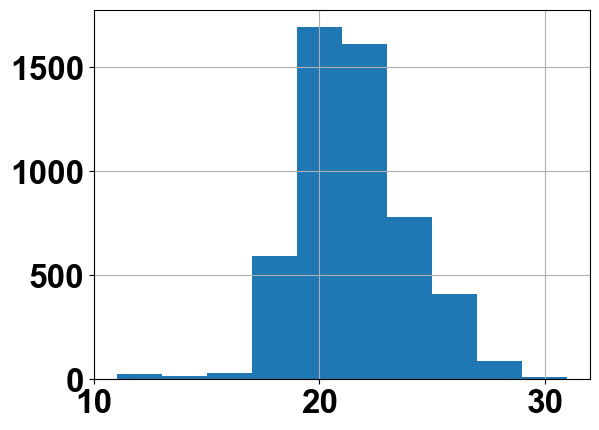

In [127]:
data = pd.concat([long_nostart])
data.intial_distance[data.intial_distance>10].hist()

<AxesSubplot: >

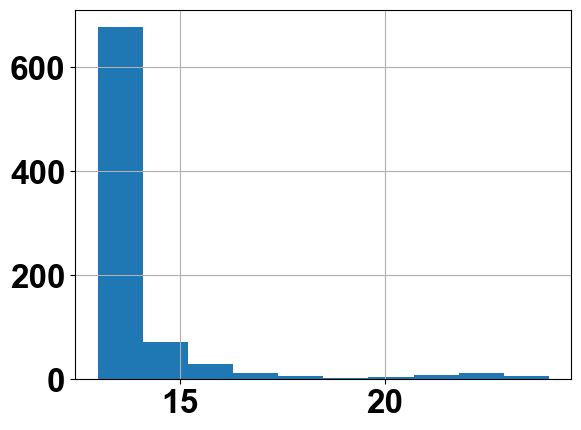

In [128]:
data = pd.concat([short_nostart])
data.intial_distance[data.intial_distance>12].hist()

<AxesSubplot: >

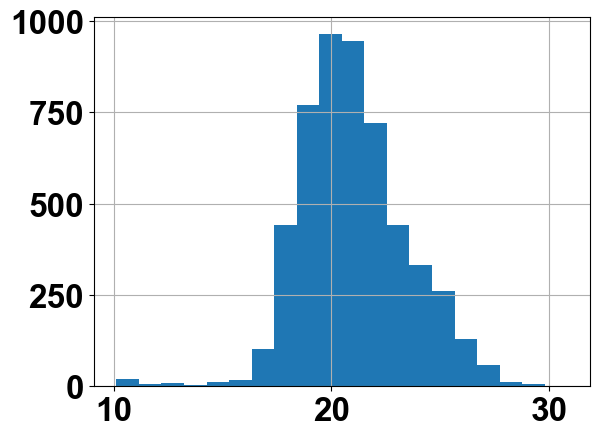

In [116]:
data = pd.concat([long_nostart])
data.intial_distance[data.intial_distance>=10].hist(bins=20)

In [139]:
test = long.sample(1)

In [115]:
test.ts_angle_to_corner

10329    [84.66471653356935, 76.92754918711047, 71.7836...
Name: ts_angle_to_corner, dtype: object

In [118]:
test.ts_angle_to_corner.to_numpy()

array([array([84.66471653356935, 76.92754918711047, 71.78364771892723,
              68.11394278734583, 67.85772789270682, 67.54606882266943,
              61.73010037852585, 68.13249890333212, 65.23842744111552,
              64.06597588813976, 59.119803173626806, 56.85369998452246,
              56.28762549254583, 56.76843550093865, 59.80191924396783,
              59.49594620486936, 63.751059813378944, 65.69993712080448,
              64.33997809167514, 65.21689657955075, 64.88568964328752,
              61.35245948894871, 65.50841878012434, 66.59008461804277,
              66.99787720807147, 69.28722477462227, 67.30240823819875,
              69.12555933115478, 68.7143663605562, 65.80274708940047,
              58.20100840720433, 56.02386113192305, 49.753344053092874,
              45.89774324622275, 42.050454161823836, 29.777142234352617,
              24.191563347895315, 11.413322500707292, 13.957892215146611,
              23.607856715893455, 21.47547974878581, 172.8031805891195

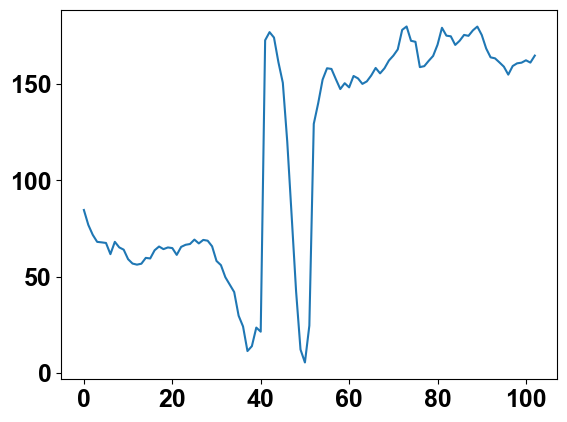

In [119]:
plt.plot(test.ts_angle_to_corner.to_numpy()[0])

In [154]:
for ind,row in test.iterrows():
    row.ts_angle_to_corner[:int(row.obstacle_ind)]

In [159]:
row.head_turn_indexs.tolist()

[11, 29, 56]

In [160]:
row.ts_angle_to_corner[:int(row.obstacle_ind)][row.head_turn_indexs.tolist()]

array([58.588897956534346, 78.64683413895078, 36.268021032408136],
      dtype=object)

In [302]:
long

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_before_head_turn,indexs_of_head_turn,head_turn_indexs,before_head_turn_indexs,after_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,angles_at_head_turns_ends
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,1.302126,"[101, 104, 111]","[104, 132]","[101, 129]","[111, 141]",21.014839,68.444419,4.699180,10.179570,None
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,22.334107,"[18, 21, 25]",[21],[18],[25],51.431379,82.440709,5.740161,67.816385,None
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14456,14456,58284.241510,58286.769433,"[58284.250803, 58284.267686, 58284.284518, 582...","[10663, 10664, 10665, 10666, 10667, 10668, 106...","[87.75959014892578, 86.99541473388672, 86.5253...","[260.9606018066406, 261.192138671875, 260.8676...","[101.29974365234375, 99.75284576416016, 98.431...","[256.0437316894531, 256.8573913574219, 257.122...","[94.1467056274414, 93.94309997558594, 93.60278...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
14459,14459,58310.359923,58312.854592,"[58310.360256, 58310.376601, 58310.39406, 5831...","[12229, 12230, 12231, 12232, 12233, 12234, 122...","[86.841064453125, 86.9388427734375, 86.4898529...","[257.9836730957031, 258.0146179199219, 257.881...","[104.91130065917969, 103.79759979248047, 102.6...","[253.5960235595703, 253.80740356445312, 254.47...","[93.63558959960938, 92.92048645019531, 92.4770...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
14479,14479,58376.306764,58379.206976,"[58376.315904, 58376.332736, 58376.351219, 583...","[16185, 16186, 16187, 16188, 16189, 16190, 161...","[85.16497802734375, 85.56788635253906, 84.9506...","[258.2767028808594, 260.45166015625, 263.06643...","[94.27912139892578, 97.41695404052734, 100.322...","[256.8212890625, 257.76318359375, 259.39791870...","[90.4214324951171

In [328]:
test = long.sample(1)
distance_at_head_turn(test)


[8.40717929]
0
53


IndexError: index 53 is out of bounds for axis 0 with size 1

In [323]:
distance_at_head_turn(long)

In [325]:
long

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_before_head_turn,indexs_of_head_turn,head_turn_indexs,before_head_turn_indexs,after_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,head_turn_velocity,angles_at_head_turns,angles_at_head_turns_ends
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,1.302126,"[101, 104, 111]","[104, 132]","[101, 129]","[111, 141]",21.014839,68.444419,4.699180,50.385093,[21.014838963246216]
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,22.334107,"[18, 21, 25]",[21],[18],[25],51.431379,82.440709,5.740161,67.816385,[51.431379266720626]
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,4.652525,"[48, 51, 54]","[9, 40, 51, 61]","[6, 37, 48, 58]","[12, 43, 54, 64]",8.090993,64.665816,9.321765,42.927215,[8.090992791682003]
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,9.925950,"[175, 179, 183]","[146, 179]","[143, 175]","[150, 183]",20.829883,65.492813,5.766666,49.631036,[20.82988257238484]
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,3.716643,"[179, 180, 182]","[23, 180, 205]","[19, 179, 204]","[29, 182, 206]",33.735538,33.807077,16.831029,10.664946,[33.735538197762764]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14456,14456,58284.241510,58286.769433,"[58284.250803, 58284.267686, 58284.284518, 582...","[10663, 10664, 10665, 10666, 10667, 10668, 106...","[87.75959014892578, 86.99541473388672, 86.5253...","[260.9606018066406, 261.192138671875, 260.8676...","[101.29974365234375, 99.75284576416016, 98.431...","[256.0437316894531, 256.8573913574219, 257.122...","[94.1467056274414, 93.94309997558594, 93.60278...",...,1.245620,"[25, 28, 32]","[28, 40]","[25, 39]","[32, 41]",27.423604,79.641270,7.004480,60.400656,[27.423603931016686]
14459,14459,58310.359923,58312.854592,"[58310.360256, 58310.376601, 58310.39406, 5831...","[12229, 12230, 12231, 12232, 12233, 12234, 122...","[86.841064453125, 86.9388427734375, 86.4898529...","[257.9836730957031, 258.0146179199219, 257.881...","[104.91130065917969, 103.79759979248047, 102.6...","[253.5960235595703, 253.80740356445312, 254.47...","[93.63558959960938, 92.92048645019531, 92.4770...",...,0.819358,"[26, 30, 34]"

In [324]:
long.head_turn_indexs

8             [104, 132]
17                  [21]
24       [9, 40, 51, 61]
27            [146, 179]
29        [23, 180, 205]
              ...       
14456           [28, 40]
14459               [30]
14479               [71]
14481            [7, 36]
14523              [nan]
Name: head_turn_indexs, Length: 3407, dtype: object

In [201]:
flatten_list_of_arrays(long.angles_at_head_turns.tolist())

array([50.38509327, 10.17956981, 67.81638505, ..., 73.07409747,
       64.89402162,         nan])

In [145]:
test = long.sample(1)

In [146]:
test.head_turn_indexs

12558    [11, 29, 56]
Name: head_turn_indexs, dtype: object

In [150]:
test.ts_angle_to_corner.to_numpy()[0][test.head_turn_indexs]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [202]:
dark = long[long.task == 'oadark']
light = long[long.task == 'oa']

(array([137., 124., 149., 268., 374., 454., 455., 364., 179.,  88.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

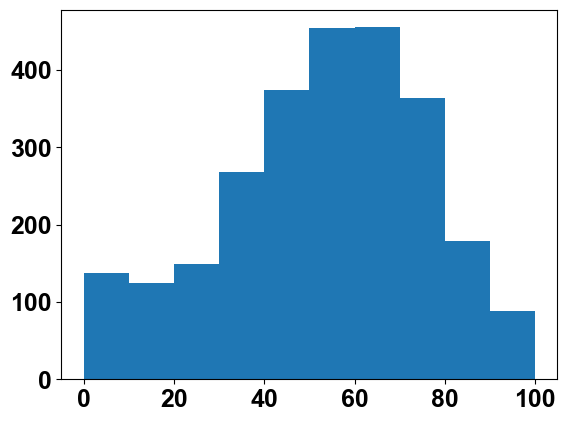

In [205]:
plt.hist(flatten_list_of_arrays(dark.angles_at_head_turns.to_list() ),range=(0,100))

In [306]:
light

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,indexs_of_head_turn,head_turn_indexs,before_head_turn_indexs,after_head_turn_indexs,angle_after_head_turn,angle_before_head_turn,head_turn_velocity,distance_at_head_turn_index,distance_at_head_turn_indexs,angles_at_head_turns
8,8,48098.019340,48102.816128,"[48098.031385, 48098.048576, 48098.06464, 4809...","[[3308, 3309, 3310, 3311, 3312, 3313, 3314, 33...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[649.9629516601562, 650.8632202148438, 650.746...","[252.6468963623047, 251.91566467285156, 251.48...","[656.01318359375, 656.386474609375, 656.445373...",...,"[101, 104, 111]","[104, 132]","[101, 129]","[111, 141]",21.014839,68.444419,4.699180,NaN,NaN,[10.179569813810865]
17,17,48338.593881,48344.042022,"[48338.598041, 48338.614617, 48338.631424, 483...","[[17737, 17738, 17739, 17740, 17741, 17742, 17...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[650.9925537109375, 652.1788330078125, 652.823...","[254.21148681640625, 254.0948028564453, 254.07...","[656.2599487304688, 657.4254150390625, 658.723...",...,"[18, 21, 25]",[21],[18],[25],51.431379,82.440709,5.740161,NaN,NaN,[67.81638505456706]
24,24,48420.115289,48424.506713,"[48420.126092, 48420.143462, 48420.159539, 484...","[[22627, 22628, 22629, 22630, 22631, 22632, 22...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6133422851562, 648.2860107421875, 648.863...","[258.9119873046875, 258.0534973144531, 257.625...","[656.2706298828125, 656.6029052734375, 656.868...",...,"[48, 51, 54]","[9, 40, 51, 61]","[6, 37, 48, 58]","[12, 43, 54, 64]",8.090993,64.665816,9.321765,NaN,NaN,[37.5903746436992]
27,27,48451.833305,48459.674124,"[48451.837196, 48451.85399, 48451.870681, 4845...","[[24529, 24530, 24531, 24532, 24533, 24534, 24...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[647.6234741210938, 647.111083984375, 647.8052...","[258.09979248046875, 256.70001220703125, 256.1...","[653.6805419921875, 654.243408203125, 654.8812...",...,"[175, 179, 183]","[146, 179]","[143, 175]","[150, 183]",20.829883,65.492813,5.766666,NaN,NaN,[64.36320042000398]
29,29,48467.768192,48473.544102,"[48467.77591, 48467.792857, 48467.810598, 4846...","[[25485, 25486, 25487, 25488, 25489, 25490, 25...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[651.9254150390625, 652.91552734375, 653.34338...","[251.62893676757812, 252.2069091796875, 252.18...","[655.7667236328125, 656.9116821289062, 658.112...",...,"[179, 180, 182]","[23, 180, 205]","[19, 179, 204]","[29, 182, 206]",33.735538,33.807077,16.831029,NaN,NaN,[10.664945778539192]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8809,8809,53682.691097,53684.452428,"[53682.695372, 53682.713523, 53682.728844, 536...","[9889, 9890, 9891, 9892, 9893, 9894, 9895, 989...","[112.17072296142578, 112.42405700683594, 112.5...","[277.1304931640625, 277.2672119140625, 277.129...","[129.66957092285156, 127.5576400756836, 125.69...","[274.0078125, 274.1982116699219, 272.819396972...","[119.23519897460938, 117.94373321533203, 119.5...",...,"[2, 4, 7]",[4],[2],[7],24.722619,48.068783,4.237962,NaN,NaN,[41.79050099824706]
8827,8827,53737.922483,53740.560204,"[53737.931635, 53737.948006, 53737.964556, 537...","[13202, 13203, 13204, 13205, 13206, 13207, 132...","[112.039794921875, 112.21412658691406, 112.549...","[276.7937316894531, 276.2401428222656, 275.822...","[129.1151885986328, 127.08348846435547, 126.63...","[274.00408935546875, 272.08660888671875, 271.3...","[118.4272689819336, 118.7538833618164, 117.768...",...,"[2, 4, 8]",[4],[2],[8],34.957795,65.501334,5.037363,NaN,NaN,[53.79044366966519]
8866,8866,54095.947059,54097.446361

In [211]:
np.nanmedian(flatten_list_of_arrays(dark.angles_at_head_turns.to_list() ))

56.862895894475045

In [268]:
np.nanmean(flatten_list_of_arrays(dark.angles_at_head_turns.to_list() ))

54.96075370881488

In [ ]:
np.nanmedian(flatten_list_of_arrays(light.angles_at_head_turns.to_list() ))


49.39121520508726

In [267]:
np.nanmean(flatten_list_of_arrays(light.angles_at_head_turns.to_list() ))


48.365255375640324

In [217]:
np.nanmedian(dark.angle_at_head_turn.to_list())

53.0804733502468

In [218]:
np.nanmedian(light.angle_at_head_turn.to_list())

47.44839030145046

In [224]:
light_dist

array([50.38509327, 10.17956981, 67.81638505, ..., 34.11627836,
       28.93456154, 32.18194634])

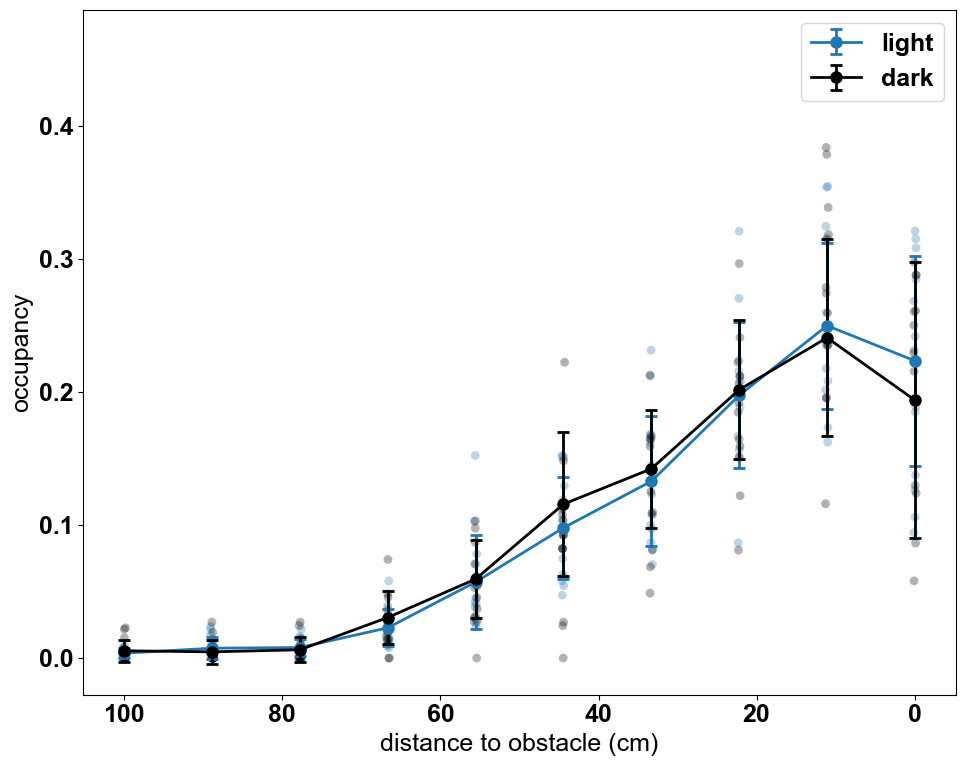

In [271]:
xnew = np.linspace(0, 100, 10)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = light.angle_after_head_turn
light_dist = light_dist[~np.isnan(light_dist)]
light_counts, light_bins = np.histogram(light_dist,range=(0,100),bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = ani_df.angle_after_head_turn
    ani_light_dists = ani_light_dists[~np.isnan(ani_light_dists)]
    counts, bins = np.histogram(ani_light_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sd = np.nanstd(light_prob, axis=0)

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = dark.angle_after_head_turn
dark_dist = dark_dist[~np.isnan(dark_dist)]
dark_counts, dark_bins = np.histogram(dark_dist,range=(0,100),bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = ani_df.angle_after_head_turn
    ani_dark_dists = ani_dark_dists[~np.isnan(ani_dark_dists)]
    
    counts, bins = np.histogram(ani_dark_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sd = np.nanstd(dark_prob, axis=0)

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars
ax.errorbar(xnew, light_hist, yerr=light_sd,
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sd,
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
#ax.set_xticks([20, 15, 10, 5, 0])
#ax.set_yticks([0, 0.1, 0.2])
ax.set_ylabel('occupancy', fontsize=18)  # lowercase
ax.set_xlabel('distance to obstacle (cm)', fontsize=18)  # lowercase
ax.invert_xaxis()

# Add grid lines


# Legend (lowercase labels)
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

In [284]:
prop['peak_heights'].argmax()

2

In [276]:
prop['peak_heights']

array([ 4.97373344,  4.96118791, 10.18231116])

In [316]:
light.angles_at_head_turns

8       10.179570
17      67.816385
24      37.590375
27      64.363200
29      10.664946
          ...    
8809    41.790501
8827    53.790444
8866    34.116278
8874    28.934562
8875    32.181946
Name: angles_at_head_turns, Length: 2059, dtype: float64

In [285]:
int(np.round(prop['right_ips'][:prop['peak_heights'].argmax()]))

TypeError: only size-1 arrays can be converted to Python scalars

In [291]:
np.round(prop['right_ips'][:prop['peak_heights'].argmax()]).astype(int)

array([14, 32])

In [272]:
peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(4,20),distance=10)

ValueError: zero-dimensional arrays cannot be concatenated

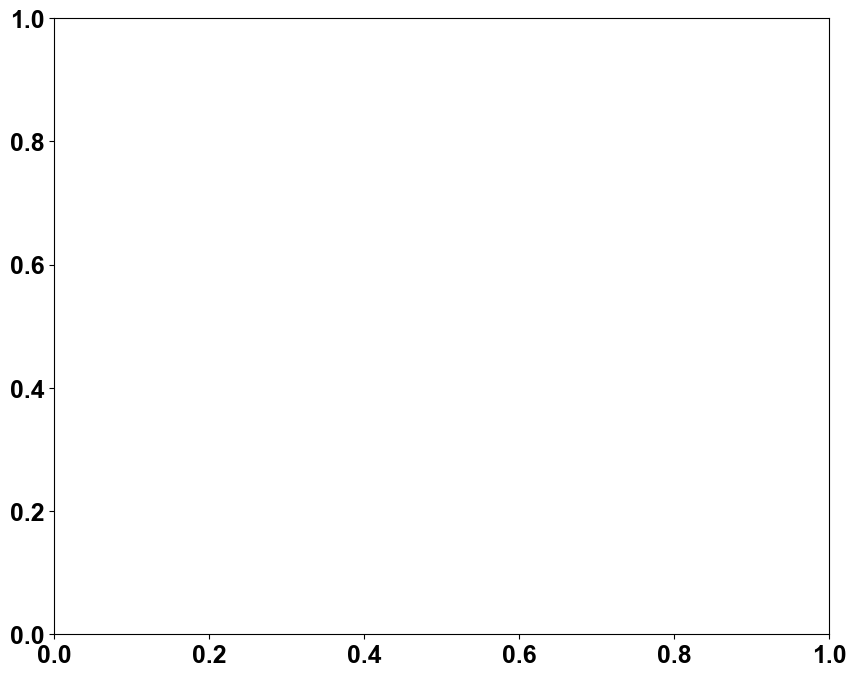

In [312]:
xnew = np.linspace(0, 100, 10)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.angles_at_head_turns.to_numpy())
light_dist = light_dist[~np.isnan(light_dist)]
light_counts, light_bins = np.histogram(light_dist,range=(0,100),bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    ani_light_dists = ani_light_dists[~np.isnan(ani_light_dists)]
    counts, bins = np.histogram(ani_light_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(len(light_prob))  # Changed to SEM

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.angles_at_head_turns.to_numpy())
dark_dist = dark_dist[~np.isnan(dark_dist)]
dark_counts, dark_bins = np.histogram(dark_dist,range=(0,100),bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    ani_dark_dists = ani_dark_dists[~np.isnan(ani_dark_dists)]
    
    counts, bins = np.histogram(ani_dark_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(len(dark_prob))  # Changed to SEM

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (now using SEM)
ax.errorbar(xnew, light_hist, yerr=light_sem,  # Changed to light_sem
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,  # Changed to dark_sem
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_ylabel('occupancy', fontsize=18)
ax.set_xlabel('angle to opening (deg)', fontsize=18)
ax.invert_xaxis()

# Legend
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

In [313]:
light_data = data[data.task == 'oa']

In [314]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Load/prepare data
data = pd.concat([long])  # Assuming 'long' is predefined
light_data = data[data.task == 'oa']
dark_data = data[data.task == 'oadark']

# Flatten angles and remove NaNs
light_angles = flatten_list_of_arrays(light_data.angles_at_head_turns.to_numpy())
light_angles = light_angles[~np.isnan(light_angles)]

dark_angles = flatten_list_of_arrays(dark_data.angles_at_head_turns.to_numpy())
dark_angles = dark_angles[~np.isnan(dark_angles)]

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# --- Plot KDEs ---
# Light condition (blue)
sns.kdeplot(light_angles, color='tab:blue', label='light', linewidth=2, ax=ax)

# Dark condition (black)
sns.kdeplot(dark_angles, color='black', label='dark', linewidth=2, ax=ax)

# --- Optional: Add individual animal KDEs (transparent lines) ---
for ani, ani_df in light_data.groupby('animal'):
    angles = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    angles = angles[~np.isnan(angles)]
    if len(angles) > 1:  # KDE requires >1 data point
        sns.kdeplot(angles, color='tab:blue', alpha=0.2, linewidth=0.5, ax=ax)

for ani, ani_df in dark_data.groupby('animal'):
    angles = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    angles = angles[~np.isnan(angles)]
    if len(angles) > 1:
        sns.kdeplot(angles, color='black', alpha=0.2, linewidth=0.5, ax=ax)

# --- Optional: Add rug plots for raw data ---
# sns.rugplot(light_angles, color='tab:blue', height=0.05, ax=ax)
# sns.rugplot(dark_angles, color='black', height=0.05, ax=ax)

# --- Formatting ---
ax.set_ylabel('Probability density', fontsize=18)
ax.set_xlabel('Angle to opening (deg)', fontsize=18)
ax.invert_xaxis()
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

ValueError: zero-dimensional arrays cannot be concatenated

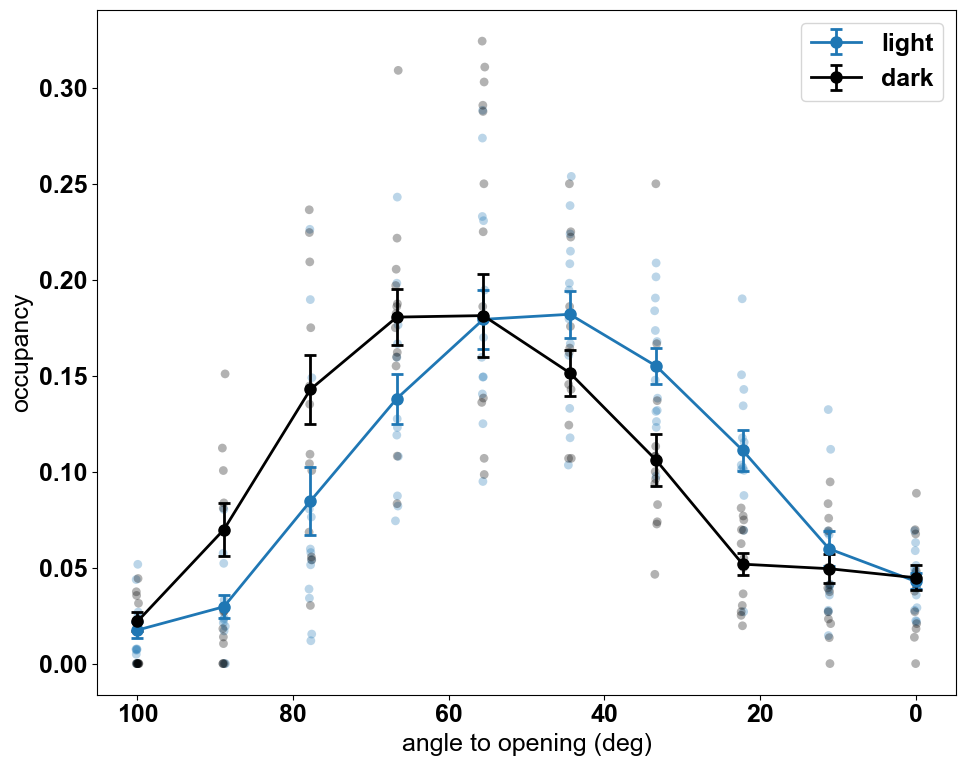

In [270]:
xnew = np.linspace(0, 100, 10)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.angles_at_head_turns.to_numpy())
light_dist = light_dist[~np.isnan(light_dist)]
light_counts, light_bins = np.histogram(light_dist,range=(0,100),bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    ani_light_dists = ani_light_dists[~np.isnan(ani_light_dists)]
    counts, bins = np.histogram(ani_light_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(len(light_prob))  # Changed to SEM

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.angles_at_head_turns.to_numpy())
dark_dist = dark_dist[~np.isnan(dark_dist)]
dark_counts, dark_bins = np.histogram(dark_dist,range=(0,100),bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    ani_dark_dists = ani_dark_dists[~np.isnan(ani_dark_dists)]
    
    counts, bins = np.histogram(ani_dark_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(len(dark_prob))  # Changed to SEM

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (now using SEM)
ax.errorbar(xnew, light_hist, yerr=light_sem,  # Changed to light_sem
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,  # Changed to dark_sem
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_ylabel('occupancy', fontsize=18)
ax.set_xlabel('angle to opening (deg)', fontsize=18)
ax.invert_xaxis()

# Legend
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

In [261]:
light.angles_at_head_turns.to_numpy()[0]

array(10.17956981)

ValueError: zero-dimensional arrays cannot be concatenated

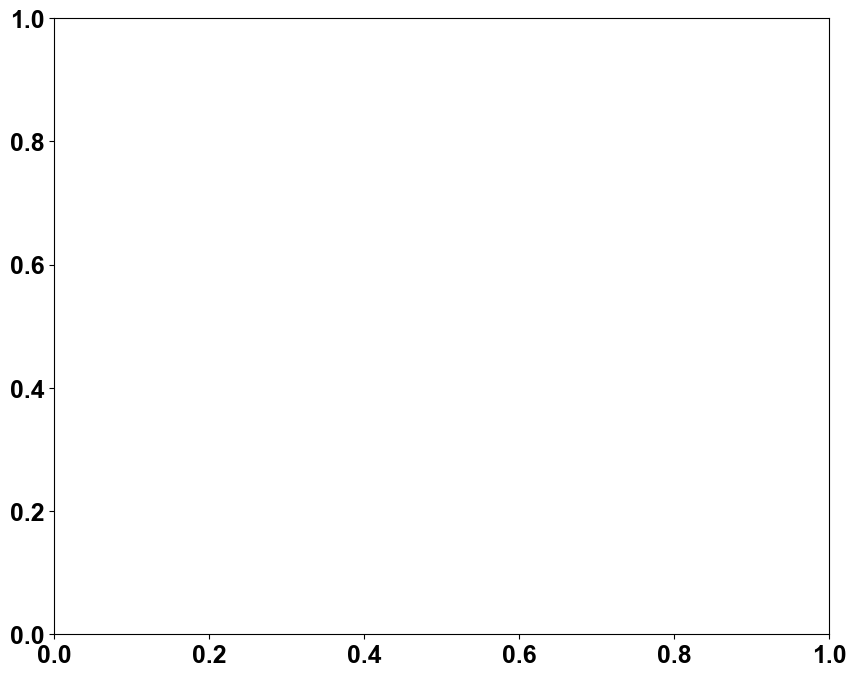

In [257]:
xnew = np.linspace(0, 100, 10)
data = pd.concat([long])
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True)

# Set font parameters (no bold)
font = {'family': 'arial', 'weight': 'bold', 'size': 18}
plt.rc('font', **font)

# Process light condition
light = data[data.task == 'oa']
light_dist = flatten_list_of_arrays(light.angles_at_head_turns.to_numpy())
light_dist = light_dist[~np.isnan(light_dist)]
light_counts, light_bins = np.histogram(light_dist,range=(0,100),bins=10)
light_hist = (light_counts / sum(light_counts))

# Process individual animals for light condition
light_prob = []
light_scatter = []

for ani, ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    ani_light_dists = ani_light_dists[~np.isnan(ani_light_dists)]
    counts, bins = np.histogram(ani_light_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    light_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    light_scatter.append((x_jittered, prob))

light_prob = np.asarray(light_prob)
light_sem = np.nanstd(light_prob, axis=0) / np.sqrt(len(light_prob))  # Changed to SEM

# Process dark condition
dark = data[data.task == 'oadark']
dark_dist = flatten_list_of_arrays(dark.angles_at_head_turns.to_numpy())
dark_dist = dark_dist[~np.isnan(dark_dist)]
dark_counts, dark_bins = np.histogram(dark_dist,range=(0,100),bins=10)
dark_hist = (dark_counts / sum(dark_counts))

# Process individual animals for dark condition
dark_prob = []
dark_scatter = []

for ani, ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.angles_at_head_turns.to_numpy())
    ani_dark_dists = ani_dark_dists[~np.isnan(ani_dark_dists)]
    
    counts, bins = np.histogram(ani_dark_dists,range=(0,100),bins=10)
    prob = counts / sum(counts)
    dark_prob.append(prob)
    
    x_jittered = xnew + np.random.uniform(-0.2, 0.2, size=len(xnew))
    dark_scatter.append((x_jittered, prob))

dark_prob = np.asarray(dark_prob)
dark_sem = np.nanstd(dark_prob, axis=0) / np.sqrt(len(dark_prob))  # Changed to SEM

# Plot individual points
for x_jittered, y in light_scatter:
    ax.scatter(x_jittered, y, color='tab:blue', alpha=0.3, s=40, edgecolors='none')
for x_jittered, y in dark_scatter:
    ax.scatter(x_jittered, y, color='black', alpha=0.3, s=40, edgecolors='none')

# Plot mean lines with error bars (now using SEM)
ax.errorbar(xnew, light_hist, yerr=light_sem,  # Changed to light_sem
           fmt='-o', color='tab:blue', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='light')

ax.errorbar(xnew, dark_hist, yerr=dark_sem,  # Changed to dark_sem
           fmt='-o', color='black', linewidth=2,
           markersize=8, capsize=4, capthick=2,
           label='dark')

# Formatting
ax.set_ylabel('occupancy', fontsize=18)
ax.set_xlabel('angle to opening (deg)', fontsize=18)
ax.invert_xaxis()

# Legend
ax.legend(loc='upper right', fontsize=18, framealpha=0.8)

plt.tight_layout()
plt.show()

(array([234., 308., 672., 815., 466., 135.,  38.,  39.,  14.,  11.]),
 array([  0.25777747,  18.02388489,  35.7899923 ,  53.55609971,
         71.32220713,  89.08831454, 106.85442195, 124.62052936,
        142.38663678, 160.15274419, 177.9188516 ]),
 <BarContainer object of 10 artists>)

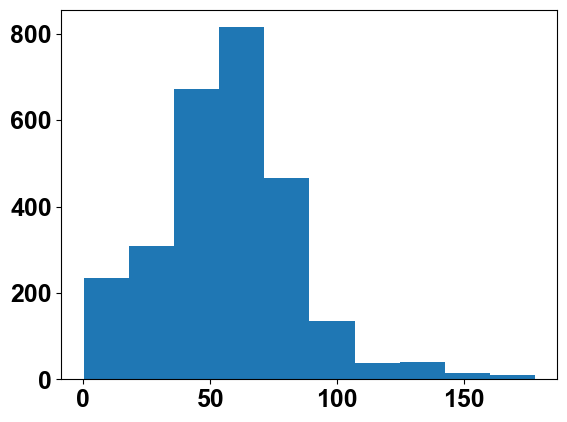

In [228]:
dark_dist = flatten_list_of_arrays(dark.angles_at_head_turns.to_numpy())
plt.hist(dark_dist)

In [230]:
light_dist = flatten_list_of_arrays(light.angles_at_head_turns.to_numpy())
np.histogram(light_dist)

ValueError: autodetected range of [nan, nan] is not finite

(array([0.0028169 , 0.00328638, 0.00547731, 0.01338028, 0.01924883,
        0.02112676, 0.01651017, 0.01150235, 0.0041471 , 0.00250391]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

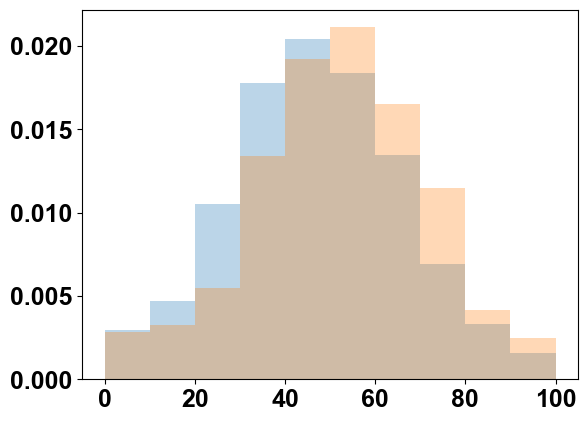

In [226]:
plt.hist(light.angle_at_head_turn.to_list() ,range=(0,100),density=True,alpha=.3)
plt.hist(dark.angle_at_head_turn.to_list() ,range=(0,100),density=True,alpha=.3)

(array([0.00528549, 0.00478395, 0.00574846, 0.01033951, 0.01442901,
        0.01751543, 0.01755401, 0.01404321, 0.00690586, 0.00339506]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

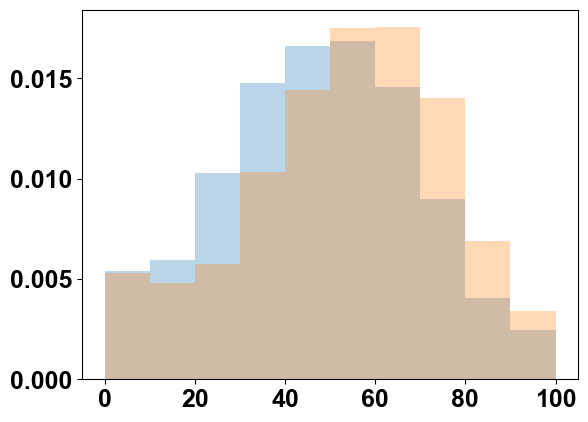

In [213]:
plt.hist(flatten_list_of_arrays(light.angles_at_head_turns.to_list() ),range=(0,100),density=True,alpha=.3)
plt.hist(flatten_list_of_arrays(dark.angles_at_head_turns.to_list() ),range=(0,100),density=True,alpha=.3)

In [199]:
np.asarray([np.nan]).shape

(1,)

In [196]:
dark.angles_at_head_turns.to_numpy()[16]

nan

In [194]:
np.concatenate(dark.angles_at_head_turns.to_numpy()[0])

ValueError: zero-dimensional arrays cannot be concatenated

In [191]:
dark.angles_at_head_turns.to_numpy().shape

(1348,)

In [190]:
dark.right_turns_distances.to_numpy().shape

(1348,)

In [192]:
plt.hist(flatten_list_of_arrays(dark.angles_at_head_turns.to_numpy() ))

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 16 has 0 dimension(s)

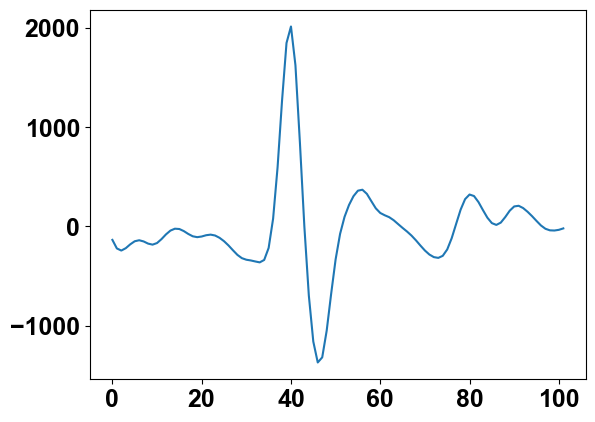

In [123]:
plt.plot(test.head_angle_velocity.to_numpy()[0]*60)

In [125]:
list_columns(test,['turn'])

array(['distance_at_head_turn', 'turn_direction', 'turn_direction_end',
       'turn_to_obstacle', 'head_corner_angle_velocity_at_head_turn',
       'angle_at_head_turn', 'distance_traveled_at_head_turn',
       'distance_at_head_turn_2', 'distance_at_head_turn_2_index',
       'distance_at_head_turn_2_indexs', 'angle_at_head_turn_2',
       'num_turn', 'towards_num_turn', 'away_num_turn', 'right_num_turn',
       'right_turns_distances', 'left_num_turn', 'left_turns_distances',
       'turn_direction_left_right'], dtype='<U39')

In [ ]:
test.right_turns_distances.to_numpy() 

array([array([21.848823958790042, 17.610935041712388, 2.253367715869235],
             dtype=object)                                               ],
      dtype=object)